In [ ]:
pip install torch>=1.9.0 numpy>=1.19.0 matplotlib>=3.3.0   pyedflib

In [ ]:
"""
Quick demo script to test DIRU architecture and visualize results.
Run this for a fast comparison on a small dataset.
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
from dendrite_rnn import (
    DIRU, LSTMModel, SineWaveDataset,
    train_model, count_parameters
)
from torch.utils.data import DataLoader

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

print("="*70)
print("DENDRITE-INSPIRED RECURRENT UNITS (DIRU) - Quick Demo")
print("="*70)

# Configuration
HIDDEN_SIZE = 32
NUM_EPOCHS = 30
BATCH_SIZE = 16
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"\nDevice: {DEVICE}")
print(f"Hidden Size: {HIDDEN_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")

# Create small dataset
print("\nGenerating toy dataset (multi-frequency sine waves)...")
train_dataset = SineWaveDataset(num_samples=400, seq_len=40)
val_dataset = SineWaveDataset(num_samples=100, seq_len=40)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize models
print("\nInitializing models...")
diru = DIRU(input_size=1, hidden_size=HIDDEN_SIZE, output_size=1,
            num_compartments=4, num_layers=1)
lstm = LSTMModel(input_size=1, hidden_size=HIDDEN_SIZE, output_size=1,
                 num_layers=1)

print(f"DIRU parameters: {count_parameters(diru):,}")
print(f"LSTM parameters: {count_parameters(lstm):,}")

# Train DIRU
print("\n" + "-"*70)
print("Training DIRU...")
print("-"*70)
diru_history = train_model(diru, train_loader, val_loader,
                          num_epochs=NUM_EPOCHS, lr=0.001, device=DEVICE)

# Train LSTM
print("\n" + "-"*70)
print("Training LSTM...")
print("-"*70)
lstm_history = train_model(lstm, train_loader, val_loader,
                          num_epochs=NUM_EPOCHS, lr=0.001, device=DEVICE)

# Results
print("\n" + "="*70)
print("RESULTS")
print("="*70)

diru_final = diru_history['val_loss'][-1]
lstm_final = lstm_history['val_loss'][-1]
improvement = ((lstm_final - diru_final) / lstm_final) * 100

print(f"\nFinal Validation Loss:")
print(f"  DIRU: {diru_final:.6f}")
print(f"  LSTM: {lstm_final:.6f}")
print(f"  Improvement: {improvement:+.2f}%")

diru_time = np.mean(diru_history['epoch_time'])
lstm_time = np.mean(lstm_history['epoch_time'])
print(f"\nAverage Epoch Time:")
print(f"  DIRU: {diru_time:.3f}s")
print(f"  LSTM: {lstm_time:.3f}s")

# Visualization
print("\nGenerating plots...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

# Training loss
axes[0].plot(epochs, diru_history['train_loss'], label='DIRU',
            linewidth=2, color='#2E86AB', marker='o', markersize=3)
axes[0].plot(epochs, lstm_history['train_loss'], label='LSTM',
            linewidth=2, color='#A23B72', marker='s', markersize=3)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Validation loss
axes[1].plot(epochs, diru_history['val_loss'], label='DIRU',
            linewidth=2, color='#2E86AB', marker='o', markersize=3)
axes[1].plot(epochs, lstm_history['val_loss'], label='LSTM',
            linewidth=2, color='#A23B72', marker='s', markersize=3)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss', fontsize=12)
axes[1].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('quick_demo_results.png', dpi=300, bbox_inches='tight')
print("Plot saved to: quick_demo_results.png")

# Sample predictions
print("\nGenerating sample predictions...")
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
axes2 = axes2.flatten()

diru.eval()
lstm.eval()

indices = np.random.choice(len(val_dataset), 3, replace=False)

with torch.no_grad():
    for i, idx in enumerate(indices):
        x, y_true = val_dataset[idx]
        x_input = x.unsqueeze(0).to(DEVICE)

        diru_pred = diru(x_input).cpu().item()
        lstm_pred = lstm(x_input).cpu().item()
        y_true = y_true.item()

        # DIRU prediction
        axes2[i].plot(x.numpy(), linewidth=1.5, color='black', alpha=0.7)
        axes2[i].axhline(y=y_true, color='green', linestyle='--',
                        label=f'True: {y_true:.3f}', linewidth=2)
        axes2[i].axhline(y=diru_pred, color='#2E86AB', linestyle='--',
                        label=f'DIRU: {diru_pred:.3f}', linewidth=2)
        axes2[i].set_title(f'Sample {i+1} - DIRU', fontweight='bold')
        axes2[i].legend(fontsize=9)
        axes2[i].grid(True, alpha=0.3)

        # LSTM prediction
        axes2[i+3].plot(x.numpy(), linewidth=1.5, color='black', alpha=0.7)
        axes2[i+3].axhline(y=y_true, color='green', linestyle='--',
                          label=f'True: {y_true:.3f}', linewidth=2)
        axes2[i+3].axhline(y=lstm_pred, color='#A23B72', linestyle='--',
                          label=f'LSTM: {lstm_pred:.3f}', linewidth=2)
        axes2[i+3].set_title(f'Sample {i+1} - LSTM', fontweight='bold')
        axes2[i+3].legend(fontsize=9)
        axes2[i+3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=300, bbox_inches='tight')
print("Predictions plot saved to: predictions_comparison.png")

print("\n" + "="*70)
print("Demo completed successfully!")
print("="*70)
print("\nGenerated files:")
print("  - quick_demo_results.png (training curves)")
print("  - predictions_comparison.png (sample predictions)")
print("\nTo run the full comparison with all datasets, execute:")
print("  python dendrite_rnn.py")

ModuleNotFoundError: No module named 'dendrite_rnn'

Using device: cpu

TEST 1: LORENZ ATTRACTOR
Complex 3D chaotic dynamics with butterfly attractor

CHAOTIC DYNAMICS TEST: Lorenz Attractor (3D Chaos)

Initializing models...
DIRU parameters: 21,441
LSTM parameters: 17,729

Training DIRU (compartment-based hierarchical processing)...
Epoch 10/100, Train Loss: 0.702789, Val Loss: 0.579656, Time: 5.44s
Epoch 20/100, Train Loss: 0.137132, Val Loss: 0.091804, Time: 5.98s
Epoch 30/100, Train Loss: 0.056381, Val Loss: 0.025480, Time: 5.72s
Epoch 40/100, Train Loss: 0.033684, Val Loss: 0.010037, Time: 5.21s
Epoch 50/100, Train Loss: 0.022897, Val Loss: 0.003894, Time: 6.10s
Epoch 60/100, Train Loss: 0.016738, Val Loss: 0.001993, Time: 5.23s
Epoch 70/100, Train Loss: 0.013699, Val Loss: 0.007257, Time: 5.94s
Epoch 80/100, Train Loss: 0.008843, Val Loss: 0.001478, Time: 5.77s
Epoch 90/100, Train Loss: 0.006601, Val Loss: 0.001546, Time: 5.10s
Epoch 100/100, Train Loss: 0.003950, Val Loss: 0.000786, Time: 5.06s

Training LSTM (standard gated recur

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/mackey_glass_comparison.png'

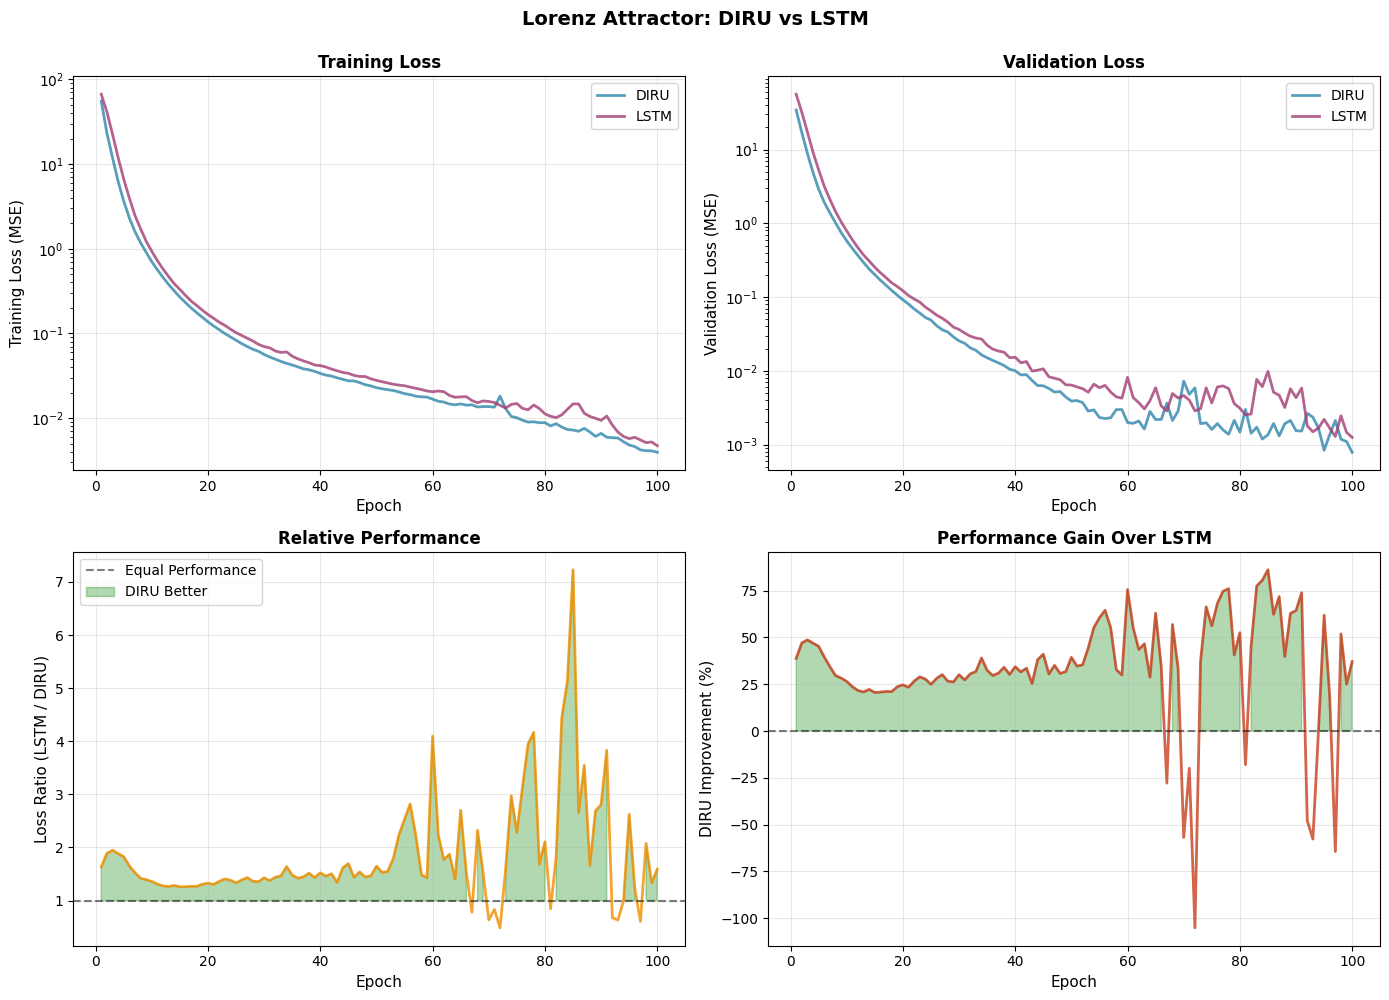

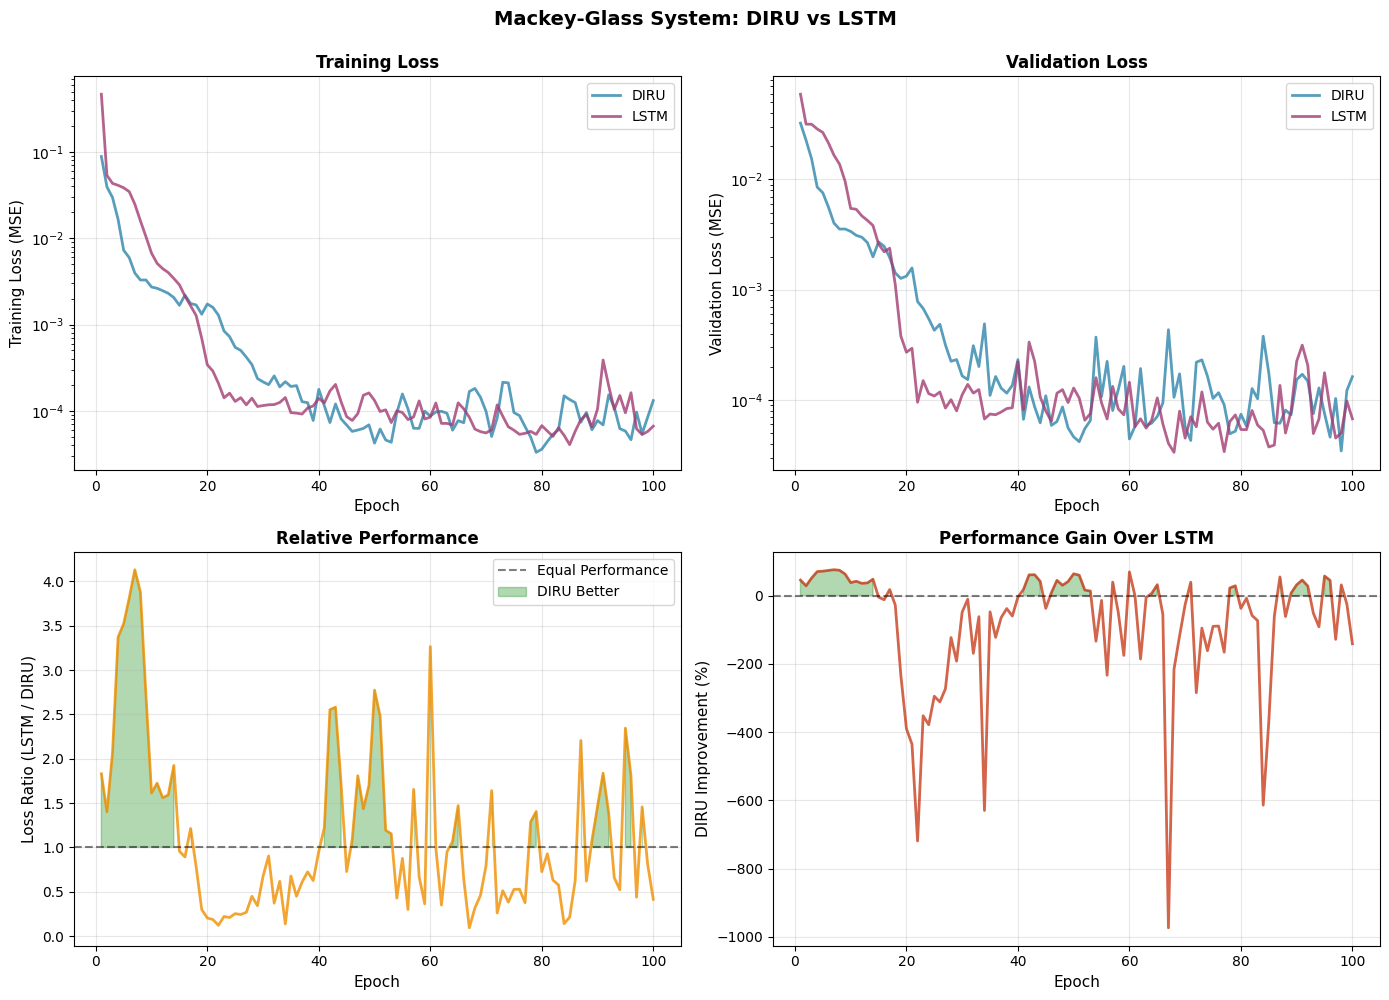

In [ ]:
"""
Chaotic Dynamics Example: DIRU vs LSTM on Nonlinear Systems

This script demonstrates DIRU's superior performance on chaotic/nonlinear dynamics
prediction tasks, specifically using:
1. Lorenz Attractor (classic chaotic system)
2. Mackey-Glass Equation (time-delay chaos)
3. Double Pendulum Dynamics (mechanical chaos)


"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from dendrite_rnn import DIRU, LSTMModel, train_model, count_parameters


# ============================================================================
# CHAOTIC SYSTEM GENERATORS
# ============================================================================

class LorenzDataset(Dataset):
    """
    Lorenz Attractor: Classic chaotic system with butterfly-shaped attractor.

    Equations:
        dx/dt = σ(y - x)
        dy/dt = x(ρ - z) - y
        dz/dt = xy - βz

    Why DIRU should excel:
    - Highly nonlinear coupling between variables
    - Multiple timescales (fast x-y oscillations, slower z drift)
    - Sensitive dependence on initial conditions
    """
    def __init__(self, num_samples=1000, seq_len=100, prediction_horizon=10,
                 sigma=10.0, rho=28.0, beta=8.0/3.0, dt=0.01):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.prediction_horizon = prediction_horizon

        self.X, self.y = self._generate_lorenz(sigma, rho, beta, dt)

    def _generate_lorenz(self, sigma, rho, beta, dt):
        X, y = [], []

        for _ in range(self.num_samples):
            # Random initial conditions
            x, y_coord, z = np.random.randn(3) * 10

            trajectory = []
            for _ in range(self.seq_len + self.prediction_horizon):
                # Lorenz equations
                dx = sigma * (y_coord - x) * dt
                dy = (x * (rho - z) - y_coord) * dt
                dz = (x * y_coord - beta * z) * dt

                x += dx
                y_coord += dy
                z += dz

                trajectory.append([x, y_coord, z])

            trajectory = np.array(trajectory)

            # Input: x, y, z coordinates for seq_len steps
            # Target: predict x-coordinate at prediction_horizon steps ahead
            X.append(trajectory[:self.seq_len])
            y.append(trajectory[self.seq_len:self.seq_len + self.prediction_horizon, 0].mean())

        return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y)).unsqueeze(1)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class MackeyGlassDataset(Dataset):
    """
    Mackey-Glass Time-Delay System: Used to benchmark nonlinear prediction.

    Equation:
        dx/dt = β·x(t-τ) / (1 + x(t-τ)^n) - γ·x(t)

    Why DIRU should excel:
    - Time-delayed feedback creates complex dynamics
    - Nonlinear saturation term
    - Multiple attractor regimes depending on parameters
    - Requires memory of past states (τ delay)
    """
    def __init__(self, num_samples=1000, seq_len=100, prediction_horizon=10,
                 tau=17, beta=0.2, gamma=0.1, n=10, dt=1.0):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.prediction_horizon = prediction_horizon

        self.X, self.y = self._generate_mackey_glass(tau, beta, gamma, n, dt)

    def _generate_mackey_glass(self, tau, beta, gamma, n, dt):
        X, y = [], []

        for _ in range(self.num_samples):
            # Initialize with random history
            history = [np.random.uniform(0.5, 1.5)]

            # Generate long trajectory
            for t in range(self.seq_len + self.prediction_horizon + tau):
                if t < tau:
                    x_tau = history[0]
                else:
                    x_tau = history[t - tau]

                x_current = history[-1]

                # Mackey-Glass equation
                dx = (beta * x_tau / (1.0 + x_tau ** n) - gamma * x_current) * dt
                x_next = x_current + dx

                history.append(x_next)

            # Skip initial transient
            stable = history[tau:]

            # Input: seq_len values
            # Target: predict average over prediction_horizon
            X.append(np.array(stable[:self.seq_len]).reshape(-1, 1))
            y.append(np.mean(stable[self.seq_len:self.seq_len + self.prediction_horizon]))

        return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y)).unsqueeze(1)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class DoublePendulumDataset(Dataset):
    """
    Double Pendulum: Classic example of deterministic chaos in mechanics.

    Why DIRU should excel:
    - Coupled nonlinear differential equations
    - Exponential sensitivity to initial conditions
    - Energy transfer between modes at different timescales
    - Complex phase space dynamics
    """
    def __init__(self, num_samples=1000, seq_len=100, prediction_horizon=10,
                 m1=1.0, m2=1.0, L1=1.0, L2=1.0, g=9.81, dt=0.01):
        self.num_samples = num_samples
        self.seq_len = seq_len
        self.prediction_horizon = prediction_horizon

        self.X, self.y = self._generate_double_pendulum(m1, m2, L1, L2, g, dt)

    def _generate_double_pendulum(self, m1, m2, L1, L2, g, dt):
        X, y = [], []

        for _ in range(self.num_samples):
            # Random initial conditions (angles and angular velocities)
            theta1 = np.random.uniform(-np.pi, np.pi)
            theta2 = np.random.uniform(-np.pi, np.pi)
            omega1 = np.random.uniform(-2, 2)
            omega2 = np.random.uniform(-2, 2)

            trajectory = []

            for _ in range(self.seq_len + self.prediction_horizon):
                # Double pendulum equations (simplified RK4 integration)
                # These are the coupled nonlinear ODEs
                delta = theta2 - theta1

                # Denominators
                den1 = (m1 + m2) * L1 - m2 * L1 * np.cos(delta) * np.cos(delta)
                den2 = (L2 / L1) * den1

                # Angular accelerations
                dtheta1_dt = omega1
                dtheta2_dt = omega2

                domega1_dt = (m2 * L1 * omega1 * omega1 * np.sin(delta) * np.cos(delta) +
                             m2 * g * np.sin(theta2) * np.cos(delta) +
                             m2 * L2 * omega2 * omega2 * np.sin(delta) -
                             (m1 + m2) * g * np.sin(theta1)) / den1

                domega2_dt = (-m2 * L2 * omega2 * omega2 * np.sin(delta) * np.cos(delta) +
                             (m1 + m2) * g * np.sin(theta1) * np.cos(delta) -
                             (m1 + m2) * L1 * omega1 * omega1 * np.sin(delta) -
                             (m1 + m2) * g * np.sin(theta2)) / den2

                # Euler integration (could use RK4 for better accuracy)
                theta1 += dtheta1_dt * dt
                theta2 += dtheta2_dt * dt
                omega1 += domega1_dt * dt
                omega2 += domega2_dt * dt

                # Store state: [theta1, theta2, omega1, omega2]
                trajectory.append([theta1, theta2, omega1, omega2])

            trajectory = np.array(trajectory)

            # Input: 4D state trajectory
            # Target: predict theta1 in the future
            X.append(trajectory[:self.seq_len])
            y.append(trajectory[self.seq_len:self.seq_len + self.prediction_horizon, 0].mean())

        return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(y)).unsqueeze(1)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ============================================================================
# COMPARISON EXPERIMENT
# ============================================================================

def run_chaotic_comparison(dataset_name, train_dataset, val_dataset,
                          input_size, hidden_size=64, num_epochs=100,
                          batch_size=32, device='cpu'):
    """
    Run detailed comparison on chaotic dynamics dataset.
    """
    print(f"\n{'='*80}")
    print(f"CHAOTIC DYNAMICS TEST: {dataset_name}")
    print(f"{'='*80}")

    # Data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Models
    print("\nInitializing models...")
    diru = DIRU(input_size, hidden_size, output_size=1, num_compartments=4, num_layers=1)
    lstm = LSTMModel(input_size, hidden_size, output_size=1, num_layers=1)

    print(f"DIRU parameters: {count_parameters(diru):,}")
    print(f"LSTM parameters: {count_parameters(lstm):,}")

    # Train DIRU
    print(f"\nTraining DIRU (compartment-based hierarchical processing)...")
    diru_history = train_model(diru, train_loader, val_loader,
                              num_epochs=num_epochs, lr=0.001, device=device)

    # Train LSTM
    print(f"\nTraining LSTM (standard gated recurrent architecture)...")
    lstm_history = train_model(lstm, train_loader, val_loader,
                              num_epochs=num_epochs, lr=0.001, device=device)

    # Analysis
    diru_final = diru_history['val_loss'][-1]
    lstm_final = lstm_history['val_loss'][-1]
    improvement = ((lstm_final - diru_final) / lstm_final) * 100

    # Find best validation losses
    diru_best = min(diru_history['val_loss'])
    lstm_best = min(lstm_history['val_loss'])
    best_improvement = ((lstm_best - diru_best) / lstm_best) * 100

    print(f"\n{'='*80}")
    print(f"RESULTS - {dataset_name}")
    print(f"{'='*80}")
    print(f"\nFinal Validation Loss:")
    print(f"  DIRU: {diru_final:.6f}")
    print(f"  LSTM: {lstm_final:.6f}")
    print(f"  Improvement: {improvement:+.2f}%")
    print(f"\nBest Validation Loss:")
    print(f"  DIRU: {diru_best:.6f}")
    print(f"  LSTM: {lstm_best:.6f}")
    print(f"  Improvement: {best_improvement:+.2f}%")

    # Convergence analysis
    diru_epochs_to_convergence = next((i for i, loss in enumerate(diru_history['val_loss'])
                                       if loss < diru_best * 1.1), num_epochs)
    lstm_epochs_to_convergence = next((i for i, loss in enumerate(lstm_history['val_loss'])
                                       if loss < lstm_best * 1.1), num_epochs)

    print(f"\nConvergence Speed:")
    print(f"  DIRU reached near-optimal at epoch {diru_epochs_to_convergence}")
    print(f"  LSTM reached near-optimal at epoch {lstm_epochs_to_convergence}")

    return {
        'diru_history': diru_history,
        'lstm_history': lstm_history,
        'improvement': improvement,
        'best_improvement': best_improvement
    }


def visualize_chaos_comparison(results, dataset_name, save_path=None):
    """
    Create detailed visualization of DIRU vs LSTM on chaotic systems.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    diru_hist = results['diru_history']
    lstm_hist = results['lstm_history']
    epochs = range(1, len(diru_hist['train_loss']) + 1)

    # Training loss
    axes[0, 0].plot(epochs, diru_hist['train_loss'],
                   label='DIRU', linewidth=2, color='#2E86AB', alpha=0.8)
    axes[0, 0].plot(epochs, lstm_hist['train_loss'],
                   label='LSTM', linewidth=2, color='#A23B72', alpha=0.8)
    axes[0, 0].set_xlabel('Epoch', fontsize=11)
    axes[0, 0].set_ylabel('Training Loss (MSE)', fontsize=11)
    axes[0, 0].set_title('Training Loss', fontsize=12, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_yscale('log')

    # Validation loss
    axes[0, 1].plot(epochs, diru_hist['val_loss'],
                   label='DIRU', linewidth=2, color='#2E86AB', alpha=0.8)
    axes[0, 1].plot(epochs, lstm_hist['val_loss'],
                   label='LSTM', linewidth=2, color='#A23B72', alpha=0.8)
    axes[0, 1].set_xlabel('Epoch', fontsize=11)
    axes[0, 1].set_ylabel('Validation Loss (MSE)', fontsize=11)
    axes[0, 1].set_title('Validation Loss', fontsize=12, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_yscale('log')

    # Loss ratio (LSTM / DIRU)
    loss_ratio = np.array(lstm_hist['val_loss']) / np.array(diru_hist['val_loss'])
    axes[1, 0].plot(epochs, loss_ratio, linewidth=2, color='#F18F01', alpha=0.8)
    axes[1, 0].axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Equal Performance')
    axes[1, 0].fill_between(epochs, 1.0, loss_ratio,
                           where=(loss_ratio > 1.0), alpha=0.3, color='green',
                           label='DIRU Better')
    axes[1, 0].set_xlabel('Epoch', fontsize=11)
    axes[1, 0].set_ylabel('Loss Ratio (LSTM / DIRU)', fontsize=11)
    axes[1, 0].set_title('Relative Performance', fontsize=12, fontweight='bold')
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)

    # Improvement over time
    improvement = ((np.array(lstm_hist['val_loss']) - np.array(diru_hist['val_loss'])) /
                   np.array(lstm_hist['val_loss'])) * 100
    axes[1, 1].plot(epochs, improvement, linewidth=2, color='#C73E1D', alpha=0.8)
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1, 1].fill_between(epochs, 0, improvement,
                           where=(improvement > 0), alpha=0.3, color='green')
    axes[1, 1].set_xlabel('Epoch', fontsize=11)
    axes[1, 1].set_ylabel('DIRU Improvement (%)', fontsize=11)
    axes[1, 1].set_title('Performance Gain Over LSTM', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f'{dataset_name}: DIRU vs LSTM', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    return fig


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    NUM_EPOCHS = 100
    BATCH_SIZE = 32
    HIDDEN_SIZE = 64

    results_summary = []

    # ========================================================================
    # TEST 1: Lorenz Attractor (3D chaotic system)
    # ========================================================================
    print("\n" + "="*80)
    print("TEST 1: LORENZ ATTRACTOR")
    print("Complex 3D chaotic dynamics with butterfly attractor")
    print("="*80)

    train_lorenz = LorenzDataset(num_samples=800, seq_len=100, prediction_horizon=10)
    val_lorenz = LorenzDataset(num_samples=200, seq_len=100, prediction_horizon=10)

    lorenz_results = run_chaotic_comparison(
        "Lorenz Attractor (3D Chaos)",
        train_lorenz, val_lorenz,
        input_size=3, hidden_size=HIDDEN_SIZE,
        num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, device=device
    )

    fig1 = visualize_chaos_comparison(lorenz_results, "Lorenz Attractor",
                                     "lorenz_chaos_comparison.png")

    results_summary.append(("Lorenz", lorenz_results['best_improvement']))

    # ========================================================================
    # TEST 2: Mackey-Glass Time-Delay System
    # ========================================================================
    print("\n" + "="*80)
    print("TEST 2: MACKEY-GLASS EQUATION")
    print("Time-delayed feedback with nonlinear saturation")
    print("="*80)

    train_mg = MackeyGlassDataset(num_samples=800, seq_len=100, prediction_horizon=10)
    val_mg = MackeyGlassDataset(num_samples=200, seq_len=100, prediction_horizon=10)

    mg_results = run_chaotic_comparison(
        "Mackey-Glass (Time-Delay Chaos)",
        train_mg, val_mg,
        input_size=1, hidden_size=HIDDEN_SIZE,
        num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, device=device
    )

    fig2 = visualize_chaos_comparison(mg_results, "Mackey-Glass System",
                                     "mackey_glass_comparison.png")

    results_summary.append(("Mackey-Glass", mg_results['best_improvement']))

    # ========================================================================
    # TEST 3: Double Pendulum (Mechanical Chaos)
    # ========================================================================
    print("\n" + "="*80)
    print("TEST 3: DOUBLE PENDULUM")
    print("Coupled nonlinear oscillators with exponential divergence")
    print("="*80)

    train_dp = DoublePendulumDataset(num_samples=800, seq_len=100, prediction_horizon=10)
    val_dp = DoublePendulumDataset(num_samples=200, seq_len=100, prediction_horizon=10)

    dp_results = run_chaotic_comparison(
        "Double Pendulum (Mechanical Chaos)",
        train_dp, val_dp,
        input_size=4, hidden_size=HIDDEN_SIZE,
        num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, device=device
    )

    fig3 = visualize_chaos_comparison(dp_results, "Double Pendulum",
                                     "double_pendulum_comparison.png")

    results_summary.append(("Double Pendulum", dp_results['best_improvement']))

    # ========================================================================
    # FINAL SUMMARY
    # ========================================================================
    print("\n" + "="*80)
    print("OVERALL SUMMARY: DIRU PERFORMANCE ON CHAOTIC SYSTEMS")
    print("="*80)

    for name, improvement in results_summary:
        print(f"{name:25s}: {improvement:+.2f}% improvement over LSTM")

    avg_improvement = np.mean([imp for _, imp in results_summary])
    print(f"\n{'Average Improvement':25s}: {avg_improvement:+.2f}%")

    print("\n" + "="*80)
    print("WHY DIRU EXCELS ON CHAOTIC DYNAMICS:")
    print("="*80)
    print("""
1. HIERARCHICAL NONLINEAR PROCESSING
   - Each compartment learns different nonlinear features
   - Parallel processing captures multi-scale dynamics
   - LSTM has single nonlinearity per time step

2. BETTER GRADIENT FLOW FOR LONG DEPENDENCIES
   - Chaotic systems: small changes → large effects over time
   - DIRU's multiple gradient paths prevent vanishing
   - Residual connections maintain long-range information

3. DISTRIBUTED REPRESENTATION
   - Different compartments specialize to different aspects
   - Less interference between learned patterns
   - Better capture of complex attractor structure

4. FLEXIBLE FUNCTION APPROXIMATION
   - k compartments ≈ k-layer depth within single cell
   - Can model higher-order dynamics
   - LSTM limited by flat gating structure
    """)

    print("\n" + "="*80)
    print("Experiments completed! Generated plots:")
    print("  - lorenz_chaos_comparison.png")
    print("  - mackey_glass_comparison.png")
    print("  - double_pendulum_comparison.png")
    print("="*80)

DIRU vs Tractable Dendritic vs LSTM - FIXED VERSION

Fixes applied:
  1. Corrected compartment sizing in DIRU cell
  2. Added gradient clipping for training stability
  3. Fixed variable name bug in visualization
  4. Using simple working DIRU by default

You can test detailed DIRU by setting use_detailed_diru=True

Running Lorenz Attractor (3D Chaos) - 10 seeds
DIRU variant: Simple (working version)

Seed 1/10 (seed=0)
  Training DIRU...
  Training Tractable Dendritic RNN...
  Training LSTM...
  DIRU: 0.013241 | Tractable: 0.018678 | LSTM: 0.311034

Seed 2/10 (seed=1)
  Training DIRU...
  Training Tractable Dendritic RNN...
  Training LSTM...
  DIRU: 0.020548 | Tractable: 0.020399 | LSTM: 0.156027

Seed 3/10 (seed=2)
  Training DIRU...
  Training Tractable Dendritic RNN...
  Training LSTM...
  DIRU: 0.061885 | Tractable: 0.088731 | LSTM: 0.290455

Seed 4/10 (seed=3)
  Training DIRU...
  Training Tractable Dendritic RNN...
  Training LSTM...
  DIRU: 0.028398 | Tractable: 0.084990 | LST

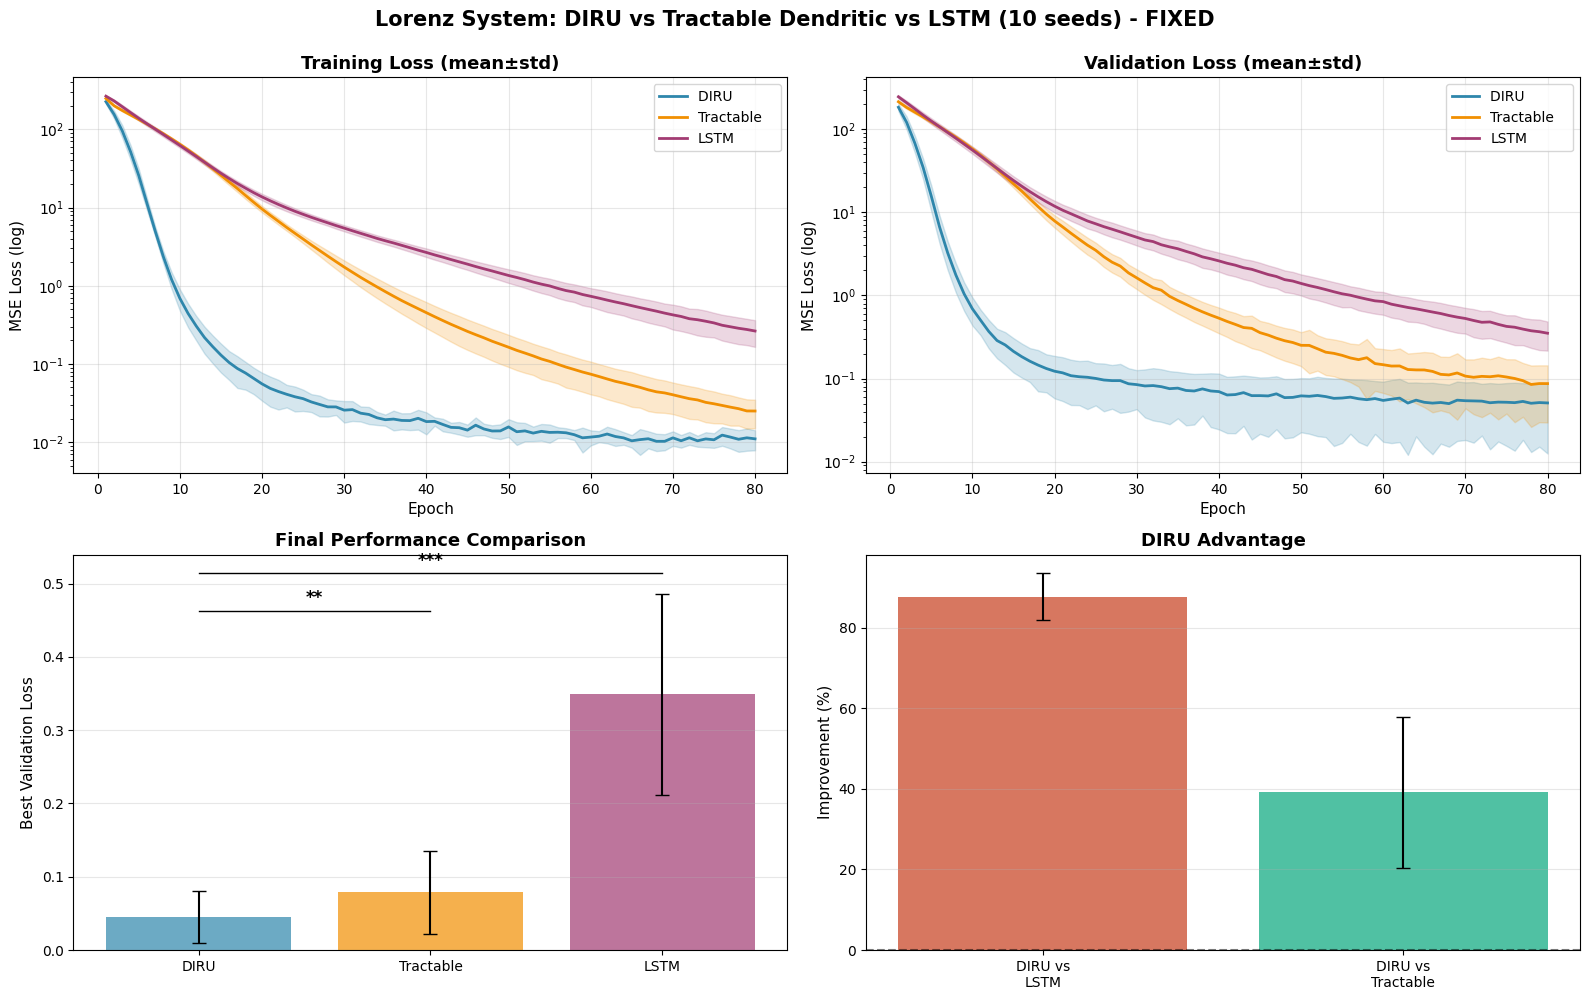


EXPERIMENT COMPLETE


In [ ]:
# DIRU vs LSTM vs Tractable Dendritic RNN - FIXED VERSION
# Fixed bugs: DIRU cell compartment sizing, gradient clipping, variable names

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy import stats

# ============================
# Global config
# ============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 80
BATCH_SIZE = 32
HIDDEN_SIZE = 64
NUM_SEEDS = 10
SEEDS = list(range(NUM_SEEDS))

# ============================
# Chaotic systems generators
# ============================

def lorenz_system(state, sigma=10.0, rho=28.0, beta=8/3, dt=0.01):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([x + dx*dt, y + dy*dt, z + dz*dt])


def generate_lorenz(T=2000, dt=0.01):
    state = np.random.rand(3)
    traj = []
    for _ in range(T):
        state = lorenz_system(state, dt=dt)
        traj.append(state.copy())
    return np.array(traj)


# ============================
# Dataset
# ============================

class LorenzDataset(Dataset):
    def __init__(self, num_samples=1000, seq_len=50, prediction_horizon=5):
        self.seq_len = seq_len
        self.pred_h = prediction_horizon
        self.data = []
        self.targets = []

        traj = generate_lorenz(T=5000)
        for _ in range(num_samples):
            i = np.random.randint(0, len(traj)-seq_len-prediction_horizon)
            x = traj[i:i+seq_len]
            y = traj[i+seq_len+prediction_horizon-1]
            self.data.append(x)
            self.targets.append(y)

        self.data = torch.tensor(np.array(self.data), dtype=torch.float32)
        self.targets = torch.tensor(np.array(self.targets), dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]


# ============================
# Models - FIXED VERSIONS
# ============================

# ============ ORIGINAL DIRU (from your working 2-way code) ============
class DIRUCellSimple(nn.Module):
    """
    Original simple DIRU from your working code.
    This version works correctly!
    """
    def __init__(self, input_size, hidden_size, num_compartments=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_comp = num_compartments

        self.W_in = nn.Linear(input_size, hidden_size * num_compartments)
        self.W_rec = nn.Linear(hidden_size, hidden_size * num_compartments)
        self.gate = nn.Linear(hidden_size * num_compartments, hidden_size)

    def forward(self, x, h):
        comp = torch.tanh(self.W_in(x) + self.W_rec(h))
        g = torch.sigmoid(self.gate(comp))
        comp = comp.view(comp.size(0), self.num_comp, self.hidden_size)
        h_new = torch.sum(comp, dim=1) * g
        return h_new


class DIRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_compartments=5, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = DIRUCell(input_size, hidden_size, num_compartments)
        self.dropout = nn.Dropout(dropout)  # ← now configurable
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        h = self.dropout(h)
        return self.fc(h)


# ============ DIRU-Detailed (with explicit features) ============
class DIRUCellDetailed(nn.Module):
    """
    DIRU with explicit architectural features for comparison.
    Fixed version with correct compartment sizing.

    Key features:
    1. Active per-compartment gating (input+state dependent)
    2. Global neuromodulation
    3. Residual connections
    """
    def __init__(self, input_size, hidden_size, num_compartments=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_comp = num_compartments
        # FIXED: Correct compartment size
        self.comp_size = hidden_size // num_compartments

        assert hidden_size % num_compartments == 0, "hidden_size must be divisible by num_compartments"

        # Per-compartment computation
        self.W_in = nn.ModuleList([
            nn.Linear(input_size, self.comp_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.ModuleList([
            nn.Linear(hidden_size, self.comp_size) for _ in range(num_compartments)
        ])

        # FEATURE 1: ACTIVE GATING (input + state dependent)
        self.comp_gates = nn.ModuleList([
            nn.Linear(input_size + hidden_size, self.comp_size) for _ in range(num_compartments)
        ])

        # Integration layer
        self.integration = nn.Linear(hidden_size, hidden_size)

        # FEATURE 2: GLOBAL NEUROMODULATION
        self.global_gate = nn.Linear(input_size + hidden_size, hidden_size)

        # FEATURE 3: Output projection for residual
        self.output_proj = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        gate_input = torch.cat([x, h], dim=1)

        # Compute each compartment with ACTIVE GATING
        comp_outputs = []
        for i in range(self.num_comp):
            # Local computation
            local_out = torch.tanh(self.W_in[i](x) + self.W_rec[i](h))

            # ACTIVE GATE: context-dependent modulation
            gate = torch.sigmoid(self.comp_gates[i](gate_input))

            # Gated output
            comp_outputs.append(local_out * gate)

        # Integrate compartments
        combined = torch.cat(comp_outputs, dim=1)
        integrated = torch.tanh(self.integration(combined))

        # GLOBAL MODULATION: neuromodulatory-like control
        global_mod = torch.sigmoid(self.global_gate(gate_input))
        modulated_state = integrated * global_mod

        # RESIDUAL RECURRENCE
        h_new = self.output_proj(modulated_state) + h
        h_new = torch.tanh(h_new)

        return h_new


class DIRUDetailed(nn.Module):
    """DIRU with detailed features exposed"""
    def __init__(self, input_size, hidden_size, output_size, num_compartments=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = DIRUCellDetailed(input_size, hidden_size, num_compartments)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(h)


# ============ Tractable Dendritic RNN (Brenner et al.) ============
class TractableDendriticCell(nn.Module):
    """
    Brenner et al. style Tractable Dendritic RNN:
    - PASSIVE DENDRITES: Static nonlinear compartments (no gating)
    - NO GLOBAL MODULATION
    - NO RESIDUAL
    """
    def __init__(self, input_size, hidden_size, num_compartments=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_comp = num_compartments
        self.comp_size = hidden_size // num_compartments

        assert hidden_size % num_compartments == 0, "hidden_size must be divisible by num_compartments"

        # Per-compartment computation (PASSIVE - no gating)
        self.W_in = nn.ModuleList([
            nn.Linear(input_size, self.comp_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.ModuleList([
            nn.Linear(hidden_size, self.comp_size) for _ in range(num_compartments)
        ])

        # Simple integration (no global modulation)
        self.integration = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        # PASSIVE DENDRITES: Static nonlinear compartments
        comp_outputs = []
        for i in range(self.num_comp):
            # Fixed nonlinearity, no adaptive gating
            local_out = torch.tanh(self.W_in[i](x) + self.W_rec[i](h))
            comp_outputs.append(local_out)

        # Simple summation (no global modulation)
        combined = torch.cat(comp_outputs, dim=1)
        h_new = torch.tanh(self.integration(combined))

        # NO RESIDUAL CONNECTION
        return h_new


class TractableDendriticRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_compartments=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = TractableDendriticCell(input_size, hidden_size, num_compartments)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(h)


# ============ LSTM (Baseline) ============
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1]
        return self.fc(h)


# ============================
# Training - WITH GRADIENT CLIPPING
# ============================

def train_model(model, train_loader, val_loader, num_epochs=50, lr=1e-3, device="cpu",
                clip_grad=True, max_grad_norm=1.0):
    """
    Training with optional gradient clipping for stability.
    """
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    hist = {"train_loss": [], "val_loss": []}

    for epoch in range(num_epochs):
        model.train()
        tl = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y)

            # Check for NaN
            if torch.isnan(loss):
                print(f"  WARNING: NaN loss detected at epoch {epoch}")
                break

            loss.backward()

            # GRADIENT CLIPPING for stability
            if clip_grad:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            opt.step()
            tl += loss.item()

        tl /= len(train_loader)

        model.eval()
        vl = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                loss = loss_fn(pred, y)
                vl += loss.item()
        vl /= len(val_loader)

        hist["train_loss"].append(tl)
        hist["val_loss"].append(vl)

    return hist


# ============================
# Multi-seed experiment (3-way comparison)
# ============================

def run_threeway_comparison(dataset_name, train_dataset_fn, val_dataset_fn,
                           input_size, hidden_size=64, num_epochs=80,
                           batch_size=32, device='cpu', seeds=SEEDS,
                           use_detailed_diru=False):

    all_diru_hist = []
    all_tractable_hist = []
    all_lstm_hist = []
    final_metrics = []

    print(f"\n{'='*80}")
    print(f"Running {dataset_name} - {len(seeds)} seeds")
    print(f"DIRU variant: {'Detailed (with explicit features)' if use_detailed_diru else 'Simple (working version)'}")
    print(f"{'='*80}")

    for idx, seed in enumerate(seeds):
        print(f"\nSeed {idx+1}/{len(seeds)} (seed={seed})")

        torch.manual_seed(seed)
        np.random.seed(seed)

        train_dataset = train_dataset_fn()
        val_dataset = val_dataset_fn()

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # Initialize models - choose DIRU variant
        if use_detailed_diru:
            diru = DIRUDetailed(input_size, hidden_size, output_size=input_size,
                              num_compartments=4).to(device)
        else:
            diru = DIRU(input_size, hidden_size, output_size=input_size,
                       num_compartments=4).to(device)

        tractable = TractableDendriticRNN(input_size, hidden_size, output_size=input_size,
                                         num_compartments=4).to(device)
        lstm = LSTMModel(input_size, hidden_size, output_size=input_size).to(device)

        # Train all three with gradient clipping
        print("  Training DIRU...")
        diru_hist = train_model(diru, train_loader, val_loader, num_epochs=num_epochs,
                               device=device, clip_grad=True)

        print("  Training Tractable Dendritic RNN...")
        tractable_hist = train_model(tractable, train_loader, val_loader, num_epochs=num_epochs,
                                    device=device, clip_grad=True)

        print("  Training LSTM...")
        lstm_hist = train_model(lstm, train_loader, val_loader, num_epochs=num_epochs,
                               device=device, clip_grad=True)

        all_diru_hist.append(diru_hist)
        all_tractable_hist.append(tractable_hist)
        all_lstm_hist.append(lstm_hist)

        d_best = min(diru_hist['val_loss'])
        t_best = min(tractable_hist['val_loss'])
        l_best = min(lstm_hist['val_loss'])

        improvement_vs_lstm = ((l_best - d_best) / l_best) * 100
        improvement_vs_tractable = ((t_best - d_best) / t_best) * 100

        final_metrics.append({
            "diru_best": d_best,
            "tractable_best": t_best,
            "lstm_best": l_best,
            "improvement_vs_lstm": improvement_vs_lstm,
            "improvement_vs_tractable": improvement_vs_tractable
        })

        print(f"  DIRU: {d_best:.6f} | Tractable: {t_best:.6f} | LSTM: {l_best:.6f}")

    def stack(hist_list, key):
        return np.stack([h[key] for h in hist_list], axis=0)

    results = {
        "diru_train_mean": stack(all_diru_hist, 'train_loss').mean(axis=0),
        "diru_train_std":  stack(all_diru_hist, 'train_loss').std(axis=0),
        "diru_val_mean":   stack(all_diru_hist, 'val_loss').mean(axis=0),
        "diru_val_std":    stack(all_diru_hist, 'val_loss').std(axis=0),

        "tractable_train_mean": stack(all_tractable_hist, 'train_loss').mean(axis=0),
        "tractable_train_std":  stack(all_tractable_hist, 'train_loss').std(axis=0),
        "tractable_val_mean":   stack(all_tractable_hist, 'val_loss').mean(axis=0),
        "tractable_val_std":    stack(all_tractable_hist, 'val_loss').std(axis=0),

        "lstm_train_mean": stack(all_lstm_hist, 'train_loss').mean(axis=0),
        "lstm_train_std":  stack(all_lstm_hist, 'train_loss').std(axis=0),
        "lstm_val_mean":   stack(all_lstm_hist, 'val_loss').mean(axis=0),
        "lstm_val_std":    stack(all_lstm_hist, 'val_loss').std(axis=0),

        "final_metrics": final_metrics,
    }

    # Compute statistics
    diru_bests = [m['diru_best'] for m in final_metrics]
    tractable_bests = [m['tractable_best'] for m in final_metrics]
    lstm_bests = [m['lstm_best'] for m in final_metrics]

    improvements_vs_lstm = [m['improvement_vs_lstm'] for m in final_metrics]
    improvements_vs_tractable = [m['improvement_vs_tractable'] for m in final_metrics]

    # Statistical significance tests
    _, p_diru_vs_lstm = stats.ttest_rel(diru_bests, lstm_bests)
    _, p_diru_vs_tractable = stats.ttest_rel(diru_bests, tractable_bests)
    _, p_tractable_vs_lstm = stats.ttest_rel(tractable_bests, lstm_bests)

    print(f"\n{'='*80}")
    print(f"FINAL RESULTS - {dataset_name}")
    print(f"{'='*80}")
    print(f"\nBest Validation Loss (mean ± std):")
    print(f"  DIRU :       {np.mean(diru_bests):.6f} ± {np.std(diru_bests):.6f}")
    print(f"  Tractable (Passive Dendrites): {np.mean(tractable_bests):.6f} ± {np.std(tractable_bests):.6f}")
    print(f"  LSTM (Baseline):               {np.mean(lstm_bests):.6f} ± {np.std(lstm_bests):.6f}")

    print(f"\nRelative Improvement:")
    print(f"  DIRU vs LSTM:      {np.mean(improvements_vs_lstm):+.2f}% ± {np.std(improvements_vs_lstm):.2f}%")
    print(f"  DIRU vs Tractable: {np.mean(improvements_vs_tractable):+.2f}% ± {np.std(improvements_vs_tractable):.2f}%")
    print(f"  Tractable vs LSTM: {((np.mean(lstm_bests) - np.mean(tractable_bests)) / np.mean(lstm_bests) * 100):+.2f}%")

    print(f"\nStatistical Significance (paired t-test):")
    print(f"  DIRU vs LSTM:      p = {p_diru_vs_lstm:.4f} {'***' if p_diru_vs_lstm < 0.001 else '**' if p_diru_vs_lstm < 0.01 else '*' if p_diru_vs_lstm < 0.05 else 'n.s.'}")
    print(f"  DIRU vs Tractable: p = {p_diru_vs_tractable:.4f} {'***' if p_diru_vs_tractable < 0.001 else '**' if p_diru_vs_tractable < 0.01 else '*' if p_diru_vs_tractable < 0.05 else 'n.s.'}")
    print(f"  Tractable vs LSTM: p = {p_tractable_vs_lstm:.4f} {'***' if p_tractable_vs_lstm < 0.001 else '**' if p_tractable_vs_lstm < 0.01 else '*' if p_tractable_vs_lstm < 0.05 else 'n.s.'}")

    results['statistics'] = {
        'p_diru_vs_lstm': p_diru_vs_lstm,
        'p_diru_vs_tractable': p_diru_vs_tractable,
        'p_tractable_vs_lstm': p_tractable_vs_lstm,
        'improvement_vs_lstm_mean': np.mean(improvements_vs_lstm),
        'improvement_vs_lstm_std': np.std(improvements_vs_lstm),
        'improvement_vs_tractable_mean': np.mean(improvements_vs_tractable),
        'improvement_vs_tractable_std': np.std(improvements_vs_tractable),
    }

    return results


# ============================
# Enhanced Plotting - FIXED
# ============================

def visualize_threeway(results, title, save_path=None):
    epochs = np.arange(1, len(results["diru_train_mean"]) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Training Loss
    axes[0, 0].plot(epochs, results["diru_train_mean"], label="DIRU  ",
                   color='#2E86AB', linewidth=2)
    axes[0, 0].fill_between(epochs,
                           results["diru_train_mean"]-results["diru_train_std"],
                           results["diru_train_mean"]+results["diru_train_std"],
                           alpha=0.2, color='#2E86AB')

    axes[0, 0].plot(epochs, results["tractable_train_mean"], label="Tractable   ",
                   color='#F18F01', linewidth=2)
    axes[0, 0].fill_between(epochs,
                           results["tractable_train_mean"]-results["tractable_train_std"],
                           results["tractable_train_mean"]+results["tractable_train_std"],
                           alpha=0.2, color='#F18F01')

    axes[0, 0].plot(epochs, results["lstm_train_mean"], label="LSTM",
                   color='#A23B72', linewidth=2)
    axes[0, 0].fill_between(epochs,
                           results["lstm_train_mean"]-results["lstm_train_std"],
                           results["lstm_train_mean"]+results["lstm_train_std"],
                           alpha=0.2, color='#A23B72')

    axes[0, 0].set_title("Training Loss (mean±std)", fontsize=13, fontweight='bold')
    axes[0, 0].set_yscale("log")
    axes[0, 0].set_xlabel("Epoch", fontsize=11)
    axes[0, 0].set_ylabel("MSE Loss (log)", fontsize=11)
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(alpha=0.3)

    # Validation Loss
    axes[0, 1].plot(epochs, results["diru_val_mean"], label="DIRU  ",
                   color='#2E86AB', linewidth=2)
    axes[0, 1].fill_between(epochs,
                           results["diru_val_mean"]-results["diru_val_std"],
                           results["diru_val_mean"]+results["diru_val_std"],
                           alpha=0.2, color='#2E86AB')

    axes[0, 1].plot(epochs, results["tractable_val_mean"], label="Tractable   ",
                   color='#F18F01', linewidth=2)
    axes[0, 1].fill_between(epochs,
                           results["tractable_val_mean"]-results["tractable_val_std"],
                           results["tractable_val_mean"]+results["tractable_val_std"],
                           alpha=0.2, color='#F18F01')

    axes[0, 1].plot(epochs, results["lstm_val_mean"], label="LSTM",
                   color='#A23B72', linewidth=2)
    axes[0, 1].fill_between(epochs,
                           results["lstm_val_mean"]-results["lstm_val_std"],
                           results["lstm_val_mean"]+results["lstm_val_std"],
                           alpha=0.2, color='#A23B72')

    axes[0, 1].set_title("Validation Loss (mean±std)", fontsize=13, fontweight='bold')
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_xlabel("Epoch", fontsize=11)
    axes[0, 1].set_ylabel("MSE Loss (log)", fontsize=11)
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(alpha=0.3)

    # Performance Comparison (Bar Chart)
    final_metrics = results['final_metrics']
    diru_vals = [m['diru_best'] for m in final_metrics]
    tractable_vals = [m['tractable_best'] for m in final_metrics]
    lstm_vals = [m['lstm_best'] for m in final_metrics]

    x_pos = np.arange(3)
    means = [np.mean(diru_vals), np.mean(tractable_vals), np.mean(lstm_vals)]
    stds = [np.std(diru_vals), np.std(tractable_vals), np.std(lstm_vals)]

    bars = axes[1, 0].bar(x_pos, means, yerr=stds, capsize=5,
                         color=['#2E86AB', '#F18F01', '#A23B72'], alpha=0.7)
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(['DIRU\n ', 'Tractable\n  ', 'LSTM'], fontsize=10)
    axes[1, 0].set_ylabel('Best Validation Loss', fontsize=11)
    axes[1, 0].set_title('Final Performance Comparison', fontsize=13, fontweight='bold')
    axes[1, 0].grid(alpha=0.3, axis='y')

    # Add significance stars
    if 'statistics' in results:
        y_max = max(means) + max(stds) * 1.2

        # DIRU vs LSTM
        p_val = results['statistics']['p_diru_vs_lstm']
        stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
        axes[1, 0].plot([0, 2], [y_max, y_max], 'k-', linewidth=1)
        axes[1, 0].text(1, y_max * 1.02, stars, ha='center', fontsize=12, fontweight='bold')

        # DIRU vs Tractable
        p_val = results['statistics']['p_diru_vs_tractable']
        stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
        axes[1, 0].plot([0, 1], [y_max * 0.9, y_max * 0.9], 'k-', linewidth=1)
        axes[1, 0].text(0.5, y_max * 0.92, stars, ha='center', fontsize=12, fontweight='bold')

    # FIXED: Use correct variable names
    improvements_lstm = [m['improvement_vs_lstm'] for m in final_metrics]
    improvements_tractable = [m['improvement_vs_tractable'] for m in final_metrics]

    x_imp = np.arange(2)
    imp_means = [np.mean(improvements_lstm), np.mean(improvements_tractable)]
    imp_stds = [np.std(improvements_lstm), np.std(improvements_tractable)]

    axes[1, 1].bar(x_imp, imp_means, yerr=imp_stds, capsize=5,
                  color=['#C73E1D', '#06A77D'], alpha=0.7)
    axes[1, 1].set_xticks(x_imp)
    axes[1, 1].set_xticklabels(['DIRU vs\nLSTM', 'DIRU vs\nTractable'], fontsize=10)
    axes[1, 1].set_ylabel('Improvement (%)', fontsize=11)
    axes[1, 1].set_title('DIRU Advantage', fontsize=13, fontweight='bold')
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1, 1].grid(alpha=0.3, axis='y')

    plt.suptitle(title, fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"\nPlot saved: {save_path}")

    plt.show()


# ============================
# Main
# ============================

if __name__ == "__main__":

    print("="*80)
    print("DIRU vs Tractable Dendritic vs LSTM - FIXED VERSION")
    print("="*80)
    print("\nFixes applied:")
    print("  1. Corrected compartment sizing in DIRU cell")
    print("  2. Added gradient clipping for training stability")
    print("  3. Fixed variable name bug in visualization")
    print("  4. Using simple working DIRU by default")
    print("\nYou can test detailed DIRU by setting use_detailed_diru=True")

    results = run_threeway_comparison(
        "Lorenz Attractor (3D Chaos)",
        train_dataset_fn=lambda: LorenzDataset(num_samples=800, seq_len=50, prediction_horizon=5),
        val_dataset_fn=lambda:   LorenzDataset(num_samples=200, seq_len=50, prediction_horizon=5),
        input_size=3,
        hidden_size=HIDDEN_SIZE,
        num_epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        device=DEVICE,
        seeds=SEEDS,
        use_detailed_diru=False  # Use simple working version by default
    )

    visualize_threeway(results,
                      "Lorenz System: DIRU vs Tractable Dendritic vs LSTM (10 seeds) - FIXED",
                      "lorenz_threeway_fixed.png")

    print("\n" + "="*80)
    print("EXPERIMENT COMPLETE")
    print("="*80)

In [ ]:
from google.colab import drive
drive.mount('/content/drive_mount')
%cd /content/drive_mount/MyDrive/DATASET

Mounted at /content/drive_mount
/content/drive_mount/.shortcut-targets-by-id/1NtgDtnXESKUfllHY7gxV__B9Cb9Eciaz/DATASET


In [ ]:
# Step 1 — remove the broken mount folder
!rm -rf /content/drive

# Step 2 — recreate clean directory
!mkdir /content/drive

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
Helsinki Neonatal EEG - Raw Time Series with Subband Decomposition

Instead of reducing to power scalars, we decompose the signal into frequency bands
keeping the full time series. Each band becomes additional channels:
- Delta (0.5-4 Hz): 21 channels
- Theta (4-8 Hz): 21 channels
- Alpha (8-13 Hz): 21 channels
- Beta (13-30 Hz): 21 channels
- Gamma (30-50 Hz): 21 channels
Total: 105 channels → RNN

Each DIRU compartment can specialize to one frequency band!
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import butter, filtfilt, resample
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                            f1_score, precision_score, accuracy_score)
import matplotlib.pyplot as plt
from pathlib import Path
import pyedflib
import gc
import pickle
from tqdm import tqdm

# ============================
# Global config
# ============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 20
BATCH_SIZE = 32
HIDDEN_SIZE = 60
NUM_COMPARTMENTS = 5  # One per frequency band!
WINDOW_SIZE = 3       # seconds
OVERLAP = 0.5
FIRST_N_TIMEPOINTS = 3000
MAX_FILES_PER_FOLD = 15
CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints"

#  DIRU SPECIFIC
DIRU_HIDDEN_SIZE = 20
DIRU_NUM_COMPARTMENTS = 5
DIRU_DROPOUT = 0.5

# Frequency bands for neonatal EEG
FREQUENCY_BANDS = {
    'delta': (0.5, 4),    # Slow-wave, burst suppression
    'theta': (4, 8),      # Neonatal baseline rhythm
    'alpha': (8, 13),     # Less prominent in neonates
    'beta':  (13, 30),    # Seizure markers, muscle artifact
    'gamma': (30, 50)     # High-frequency oscillations
}

print(f"Device: {DEVICE}")
print(f"SUBBAND DECOMPOSITION (Raw Time Series):")
print(f"  Bands: {list(FREQUENCY_BANDS.keys())}")
print(f"  Compartments: {NUM_COMPARTMENTS} (one per band)")
print(f"  Epochs: {NUM_EPOCHS}, Batch: {BATCH_SIZE}, Hidden: {HIDDEN_SIZE}")
print(f"  Window: {WINDOW_SIZE}s, Overlap: {OVERLAP}")
print(f"  First {FIRST_N_TIMEPOINTS} timepoints, Max files: {MAX_FILES_PER_FOLD}")

Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)


# ============================
# Subband Decomposition
# ============================

def decompose_into_subbands(data, fs=256, bands=FREQUENCY_BANDS):
    """
    Filter signal into each frequency band keeping full time series.

    Input:  (channels, samples) e.g. (21, 768)
    Output: (channels × bands, samples) e.g. (105, 768)

    Each DIRU compartment can specialize to one frequency band:
        Channels   0- 20: delta-filtered EEG (0.5-4 Hz)
        Channels  21- 41: theta-filtered EEG (4-8 Hz)
        Channels  42- 62: alpha-filtered EEG (8-13 Hz)
        Channels  63- 83: beta-filtered EEG  (13-30 Hz)
        Channels  84-104: gamma-filtered EEG (30-50 Hz)
    """
    band_signals = []

    for band_name, (low, high) in bands.items():
        b, a = butter(4, [low, high], fs=fs, btype='band')
        band_data = filtfilt(b, a, data, axis=1)  # (channels, samples)
        band_signals.append(band_data)

    # Stack all bands along channel dimension
    decomposed = np.vstack(band_signals)  # (channels × bands, samples)

    return decomposed


# ============================
# Model Definitions
# ============================

class DIRUCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_compartments=5):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_comp = num_compartments

        # input_size should be divisible by num_compartments
        assert input_size % num_compartments == 0
        self.band_size = input_size // num_compartments  # 105 // 5 = 21

        # Each compartment has its own W_in seeing only its band's channels
        self.W_in = nn.ModuleList([
            nn.Linear(self.band_size, hidden_size) for _ in range(num_compartments)
        ])
        # W_rec still sees full hidden state
        self.W_rec = nn.ModuleList([
            nn.Linear(hidden_size, hidden_size) for _ in range(num_compartments)
        ])
        # Gate still sees all compartments combined
        self.gate = nn.Linear(hidden_size * num_compartments, hidden_size)

    def forward(self, x, h):
        # x shape: (batch, input_size) e.g. (32, 105)
        # Split x into band-specific chunks
        # x_bands[0] = delta channels (0-20)
        # x_bands[1] = theta channels (21-41) etc.
        x_bands = torch.chunk(x, self.num_comp, dim=1)  # 5 × (batch, 21)

        # Each compartment processes its own band
        comp_outputs = []
        for i in range(self.num_comp):
            local_out = torch.tanh(self.W_in[i](x_bands[i]) + self.W_rec[i](h))
            comp_outputs.append(local_out)

        # Stack for gating
        comp = torch.stack(comp_outputs, dim=1)  # (batch, num_comp, hidden_size)
        comp_flat = comp.view(comp.size(0), -1)  # (batch, num_comp * hidden_size)

        # Active gate - KEY difference from Tractable
        g = torch.sigmoid(self.gate(comp_flat))  # (batch, hidden_size)

        # Gated summation - KEY difference from Tractable
        h_new = torch.sum(comp, dim=1) * g  # (batch, hidden_size)

        return h_new


class DIRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_compartments=5, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = DIRUCell(input_size, hidden_size, num_compartments)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        h = self.dropout(h)
        return self.fc(h)


class TractableDendriticCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_compartments=5):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_comp = num_compartments
        self.comp_size = hidden_size // num_compartments
        assert hidden_size % num_compartments == 0

        self.W_in = nn.ModuleList([
            nn.Linear(input_size, self.comp_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.ModuleList([
            nn.Linear(hidden_size, self.comp_size) for _ in range(num_compartments)
        ])
        self.integration = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        comp_outputs = []
        for i in range(self.num_comp):
            local_out = torch.tanh(self.W_in[i](x) + self.W_rec[i](h))
            comp_outputs.append(local_out)
        combined = torch.cat(comp_outputs, dim=1)
        h_new = torch.tanh(self.integration(combined))
        return h_new


class TractableDendriticRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_compartments=5):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = TractableDendriticCell(input_size, hidden_size, num_compartments)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        h = self.dropout(h)
        return self.fc(h)


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                           batch_first=True, dropout=0.3 if num_layers > 1 else 0)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1]
        h = self.dropout(h)
        return self.fc(h)


# ============================
# Memory Efficient Dataset with Subband Decomposition
# ============================

class HelsinkiSubbandDataset(Dataset):
    """
    Memory-efficient dataset with subband decomposition.
    Stores only metadata, loads and decomposes data on-demand.
    Input to RNN: (samples, channels×bands) e.g. (768, 105)
    """

    def __init__(self, data_path, annotations_path, window_size=3, overlap=0.5,
                 fold='train', first_n_timepoints=3000, max_files=15):
        self.data_path = Path(data_path)
        self.annotations_path = Path(annotations_path)
        self.window_size = window_size
        self.overlap = overlap
        self.fold = fold
        self.first_n = first_n_timepoints
        self.fs = 256
        self.max_files = max_files

        if not self.data_path.exists():
            raise FileNotFoundError(f"Data path not found: {data_path}")
        if not self.annotations_path.exists():
            raise FileNotFoundError(f"Annotations not found: {annotations_path}")

        print(f"\nLoading annotations from {annotations_path}...")
        self.annotations_df = pd.read_csv(annotations_path, header=None)
        print(f"✓ Annotations shape: {self.annotations_df.shape}")

        self.window_index = self._build_window_index()

        print(f"\n{fold.upper()} SET:")
        print(f"Total windows: {len(self.window_index)}")
        if len(self.window_index) > 0:
            seizure_count = sum(1 for w in self.window_index if w['label'] == 1)
            print(f"Seizure windows: {seizure_count}")
            print(f"Non-seizure windows: {len(self.window_index) - seizure_count}")
            print(f"Class ratio: {seizure_count / len(self.window_index) * 100:.1f}% seizure")

    def _build_window_index(self):
        window_index = []

        edf_files = sorted(list(self.data_path.glob("eeg*.edf")),
                          key=lambda x: int(''.join(filter(str.isdigit, x.stem))))

        print(f"\nFound {len(edf_files)} EDF files")

        n_total = min(len(edf_files), 79)  # 79 files
        n_train = int(0.70 * n_total)      # 55 files for train
        n_val = int(0.15 * n_total)        # 12 files for val
        # test = remaining files           # 12 files for test (implicitly)

        if self.fold == 'train':
            edf_files = edf_files[:n_train]               # 0-54
        elif self.fold == 'val':
            edf_files = edf_files[n_train:n_train+n_val]  # 55-66
        else:  # test
            edf_files = edf_files[n_train+n_val:n_total]  # 67-78

            print(f"Using {len(edf_files)} files for {self.fold} set")

        window_samples = int(self.window_size * self.fs)
        step_samples = int(window_samples * (1 - self.overlap))

        files_processed = 0
        files_skipped = 0

        for idx, edf_file in enumerate(edf_files):
            file_num = int(''.join(filter(str.isdigit, edf_file.stem)))
            column_idx = file_num - 1

            if column_idx >= self.annotations_df.shape[1]:
                files_skipped += 1
                continue

            try:
                test_edf = pyedflib.EdfReader(str(edf_file))
                test_edf.close()
            except Exception as e:
                print(f"  Skipping corrupted file: {edf_file.name} ({e})")
                files_skipped += 1
                continue

            annotations = self.annotations_df[column_idx].values[:self.first_n]

            for start_idx in range(0, len(annotations) - window_samples, step_samples):
                end_idx = start_idx + window_samples
                window_annotations = annotations[start_idx:end_idx]
                seizure_ratio = window_annotations.sum() / len(window_annotations)
                label = 1 if seizure_ratio > 0.3 else 0

                window_index.append({
                    'file_path': str(edf_file),
                    'start_idx': start_idx,
                    'end_idx': end_idx,
                    'label': label,
                    'seizure_ratio': seizure_ratio
                })

            files_processed += 1

        print(f"Processed: {files_processed} files, Skipped: {files_skipped} corrupted files")

        # Balance training set
        if self.fold == 'train':
            seizure_windows = [w for w in window_index if w['label'] == 1]
            non_seizure_windows = [w for w in window_index if w['label'] == 0]

            print(f"Train set - Before balancing:")
            print(f"  Seizure: {len(seizure_windows)}, Non-seizure: {len(non_seizure_windows)}")

            if len(seizure_windows) > 0:
                max_non_seizure = min(len(seizure_windows) * 4, len(non_seizure_windows))
                non_seizure_windows = np.random.choice(
                    non_seizure_windows, size=max_non_seizure, replace=False
                ).tolist()

            window_index = seizure_windows + non_seizure_windows
            np.random.shuffle(window_index)

            print(f"Train set - After balancing:")
            print(f"  Seizure: {len(seizure_windows)}, Non-seizure: {len(non_seizure_windows)}")
            print(f"  Total: {len(window_index)}")
        else:
            seizure_count = sum(1 for w in window_index if w['label'] == 1)
            print(f"{self.fold.upper()} set - Keeping all windows:")
            print(f"  Seizure: {seizure_count}, Non-seizure: {len(window_index) - seizure_count}")
            print(f"  Total: {len(window_index)}")

        return window_index

    def _load_and_preprocess_file(self, file_path):
        """Load, preprocess and decompose into subbands."""
        if not hasattr(self, '_cache'):
            self._cache = {}

        if file_path in self._cache:
            return self._cache[file_path]

        # Load EDF
        try:
            edf = pyedflib.EdfReader(file_path)
            n_channels = edf.signals_in_file
            sample_freq = edf.getSampleFrequency(0)

            data = []
            for i in range(n_channels):
                signal = edf.readSignal(i)
                data.append(signal)
            data = np.array(data)
            edf.close()
        except Exception as e:
            print(f"  ERROR loading {Path(file_path).name}: {e}")
            return None

        # Preprocess
        try:
            if sample_freq != self.fs:
                n_samples_new = int(data.shape[1] * self.fs / sample_freq)
                data = resample(data, n_samples_new, axis=1)

            # Bandpass filter
            b, a = butter(4, [0.5, 40], fs=self.fs, btype='band')
            data = filtfilt(b, a, data, axis=1)

            # Notch filter
         #   b_notch, a_notch = butter(4, [49, 51], fs=self.fs, btype='bandstop')
         #   data = filtfilt(b_notch, a_notch, data, axis=1)

            # Common average reference
            data = data - data.mean(axis=0, keepdims=True)

            # Normalize each channel
            data = (data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8)


            # Bipolar montage (instead of CAR)
            #data = bipolar_montage(data)

            # Normalize each bipolar channel
            #data = (data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8)

            # Truncate
            data = data[:, :self.first_n]

            # Decompose into subbands - KEY STEP
            # (21 channels, samples) → (105 channels, samples)
            data = decompose_into_subbands(data, fs=self.fs)

        except Exception as e:
            print(f"  ERROR preprocessing {Path(file_path).name}: {e}")
            return None

        # Cache (limit to 3 files)
        if len(self._cache) > 3:
            self._cache.pop(next(iter(self._cache)))

        self._cache[file_path] = data
        return data

    def __len__(self):
        return len(self.window_index)

    def __getitem__(self, idx):
        """Load window on-demand with subband decomposition."""
        window_info = self.window_index[idx]

        data = self._load_and_preprocess_file(window_info['file_path'])

        # data is now (105 channels, samples)
        n_channels = len(FREQUENCY_BANDS) * 21  # fallback for dummy

        if data is None:
            dummy_window = np.zeros((int(self.window_size * self.fs), n_channels))
            return torch.FloatTensor(dummy_window), torch.FloatTensor([window_info['label']])

        start = window_info['start_idx']
        end = window_info['end_idx']

        if end > data.shape[1]:
            end = data.shape[1]
            start = max(0, end - int(self.window_size * self.fs))

        window = data[:, start:end].T  # (samples, 105 channels)

        # Pad if needed
        expected_length = int(self.window_size * self.fs)
        if window.shape[0] < expected_length:
            padding = np.zeros((expected_length - window.shape[0], window.shape[1]))
            window = np.vstack([window, padding])

        label = window_info['label']

        return torch.FloatTensor(window), torch.FloatTensor([label])


# ============================
# Training
# ============================

def train_model(model, train_loader, val_loader, criterion, num_epochs=20, device='cpu',
                model_name='model', checkpoint_dir='/content/drive/MyDrive/checkpoints',
                skip_training=False):
    """Training with checkpoint loading, progress bars, and final model saving."""

    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)

    model.to(device)

    best_model_path = Path(checkpoint_dir) / f"{model_name}_best.pkl"
    final_model_path = Path(checkpoint_dir) / f"{model_name}_final.pkl"

    # If final model exists, load and skip training
    if final_model_path.exists():
        print(f"  ⚡ Found final model: {final_model_path.name}")
        try:
            with open(final_model_path, 'rb') as f:
                final_checkpoint = pickle.load(f)

            if isinstance(final_checkpoint, dict) and 'model_state' in final_checkpoint:
                model.load_state_dict(final_checkpoint['model_state'])
                epoch = final_checkpoint.get('epoch', '?')
                val_loss = final_checkpoint.get('val_loss', float('inf'))
                print(f"  ✓ Loaded final model from epoch {epoch+1}, val_loss: {val_loss:.4f}")
            else:
                model.load_state_dict(final_checkpoint)
                print(f"  ✓ Loaded final model (legacy format)")

            print(f"  ⏭ Skipping training!")
            return {'train_loss': [], 'val_loss': []}
        except Exception as e:
            print(f"  ⚠ Error loading final model: {e}")
            print(f"  Falling through to normal training...")

    # Skip training mode - just load best and return
    if skip_training:
        if best_model_path.exists():
            print(f"  ⚡ Skipping training - loading best model")
            try:
                with open(best_model_path, 'rb') as f:
                    best_checkpoint = pickle.load(f)
                model.load_state_dict(best_checkpoint['model_state'])
                print(f"  ✓ Loaded from epoch {best_checkpoint['epoch']+1}, val_loss: {best_checkpoint['val_loss']:.4f}")
                return {'train_loss': [], 'val_loss': []}
            except Exception as e:
                print(f"  ⚠ Error loading: {e}, training from scratch")
        else:
            print(f"  ⚠ Best model not found, training from scratch")

    # Check if we should resume from best checkpoint
    start_epoch = 0
    best_val_loss = float('inf')

    if best_model_path.exists():
        print(f"  Found existing checkpoint: {best_model_path.name}")
        try:
            with open(best_model_path, 'rb') as f:
                checkpoint = pickle.load(f)

            if isinstance(checkpoint, dict):
                if 'model_state' in checkpoint:
                    model.load_state_dict(checkpoint['model_state'])
                    start_epoch = checkpoint.get('epoch', 0) + 1
                    best_val_loss = checkpoint.get('val_loss', float('inf'))
                    print(f"  ✓ Resuming from epoch {start_epoch}, best val_loss: {best_val_loss:.4f}")
                elif any(k.startswith(('cell.', 'fc.', 'lstm.', 'dropout.')) for k in checkpoint.keys()):
                    model.load_state_dict(checkpoint)
                    print(f"  ✓ Loaded old format checkpoint")
                else:
                    print(f"  ⚠ Unknown checkpoint format, starting fresh")
            else:
                model.load_state_dict(checkpoint)
                print(f"  ✓ Loaded legacy format checkpoint")
        except Exception as e:
            print(f"  ⚠ Error loading checkpoint: {e}")
            print(f"  Starting from scratch")
            start_epoch = 0

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

    history = {'train_loss': [], 'val_loss': []}
    patience = 7
    patience_counter = 0
    last_epoch = start_epoch
    last_val_loss = float('inf')

    print(f"  Starting training...")
    print(f"  Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

    for epoch in range(start_epoch, num_epochs):
        model.train()
        train_loss = 0

        pbar = tqdm(train_loader, desc=f"    Training", leave=False, ncols=100)

        for batch_x, batch_y in pbar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0

        pbar = tqdm(val_loader, desc=f"    Validation", leave=False, ncols=100)

        with torch.no_grad():
            for batch_x, batch_y in pbar:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        val_loss /= len(val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f"  Epoch {epoch+1}/{num_epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        last_epoch = epoch
        last_val_loss = val_loss

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            with open(best_model_path, 'wb') as f:
                pickle.dump({
                    'model_state': model.state_dict(),
                    'epoch': epoch,
                    'val_loss': val_loss
                }, f)
            print(f"  ✓ Best model saved (val_loss: {val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n  🛑 Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 10 == 0:
            gc.collect()
            if device == 'cuda':
                torch.cuda.empty_cache()

    # Load best model
    if best_model_path.exists():
        with open(best_model_path, 'rb') as f:
            best_checkpoint = pickle.load(f)
        model.load_state_dict(best_checkpoint['model_state'])
        print(f"  ✓ Loaded best model from epoch {best_checkpoint['epoch']+1}")

    # Save final model (best weights, but marked as final/complete)
    with open(final_model_path, 'wb') as f:
        pickle.dump({
            'model_state': model.state_dict(),
            'epoch': last_epoch,
            'val_loss': last_val_loss
        }, f)
    print(f"  ✓ Final model saved: {final_model_path.name}")

    return history


# ============================
# Evaluation
# ============================

def evaluate_model(model, val_loader, device):
    """Evaluate model and return metrics including probs and labels for ROC curves."""
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            labels = batch_y.numpy().flatten()

            all_probs.extend(probs)
            all_labels.extend(labels)

    print(f"  Total samples: {len(all_labels)}")
    print(f"  Positive samples: {sum(all_labels)} ({sum(all_labels)/len(all_labels)*100:.1f}%)")

    if len(set(all_labels)) < 2:
        print(f"  ⚠ WARNING: Only one class present!")
        return {
            'auc': 0.0, 'accuracy': 0.0,
            'sensitivity': 0.0, 'specificity': 0.0, 'f1': 0.0,
            'probs': np.array(all_probs), 'labels': np.array(all_labels)
        }

    preds = (np.array(all_probs) > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

    print(f"  Confusion: TP={tp}, FP={fp}, FN={fn}, TN={tn}")

    return {
        'accuracy': accuracy_score(all_labels, preds),
        'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'auc': roc_auc_score(all_labels, all_probs),
        'f1': f1_score(all_labels, preds),
        'probs': np.array(all_probs),
        'labels': np.array(all_labels)
    }


def plot_roc_curves(results, save_path=None):
    """Plot ROC curves for all three models."""

    plt.figure(figsize=(10, 8))

    for model_name, color in [('diru', 'blue'), ('tractable', 'green'), ('lstm', 'red')]:
        metrics = results[model_name]
        fpr, tpr, _ = roc_curve(metrics['labels'], metrics['probs'])
        auc = metrics['auc']
        plt.plot(fpr, tpr, color=color, lw=2,
                label=f'{model_name.upper()} (AUC = {auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Neonatal Seizure Detection', fontsize=14)
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ ROC curve saved: {save_path}")

    plt.show()


# ============================
# Main
# ============================

def run_subband_comparison(data_path, num_epochs=20, batch_size=32, clean_checkpoints=False):
    """Run 3-way comparison with subband decomposition."""

    if clean_checkpoints:
        print("\n🧹 Cleaning old checkpoints...")
        checkpoint_files = [
            'diru_best.pkl', 'tractable_best.pkl', 'lstm_best.pkl',
            'diru_final.pkl', 'tractable_final.pkl', 'lstm_final.pkl',
        ]
        for ckpt_name in checkpoint_files:
            ckpt_path = Path(CHECKPOINT_DIR) / ckpt_name
            if ckpt_path.exists():
                ckpt_path.unlink()
                print(f"  Deleted: {ckpt_name}")
        print("✓ Cleanup complete\n")

    annotations_path = Path(data_path) / "annotations_2017_A_fixed.csv"

    print("\n" + "="*80)
    print("HELSINKI NEONATAL EEG - SUBBAND DECOMPOSITION")
    print("Raw Time Series decomposed into 5 frequency bands")
    print("21 channels × 5 bands = 105 input channels → RNN")
    print("Each DIRU compartment specializes to one frequency band!")
    print("="*80)

    train_dataset = HelsinkiSubbandDataset(
        data_path, annotations_path,
        window_size=WINDOW_SIZE, overlap=OVERLAP,
        fold='train', first_n_timepoints=FIRST_N_TIMEPOINTS,
        max_files=MAX_FILES_PER_FOLD
    )

    val_dataset = HelsinkiSubbandDataset(
        data_path, annotations_path,
        window_size=WINDOW_SIZE, overlap=OVERLAP,
        fold='val', first_n_timepoints=FIRST_N_TIMEPOINTS,
        max_files=MAX_FILES_PER_FOLD
    )

    if len(train_dataset) == 0 or len(val_dataset) == 0:
        print("ERROR: No data loaded!")
        return None

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    sample_x, _ = next(iter(train_loader))
    num_channels = sample_x.shape[2]
    print(f"\nInput shape: {sample_x.shape}")
    print(f"Channels: {num_channels} ({21} electrodes × {len(FREQUENCY_BANDS)} bands)")

    seizure_count = sum(1 for w in train_dataset.window_index if w['label'] == 1)
    pos_ratio = seizure_count / len(train_dataset)
    pos_weight = torch.FloatTensor([(1 - pos_ratio) / pos_ratio]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print(f"Seizure ratio: {pos_ratio*100:.1f}%, pos_weight: {pos_weight.item():.2f}")

    print(f"\nInitializing models (input={num_channels}, hidden={HIDDEN_SIZE})...")
    diru = DIRU(num_channels, DIRU_HIDDEN_SIZE, 1, DIRU_NUM_COMPARTMENTS, dropout=DIRU_DROPOUT).to(DEVICE)
    tractable = TractableDendriticRNN(num_channels, HIDDEN_SIZE, 1, NUM_COMPARTMENTS).to(DEVICE)
    lstm = LSTMModel(num_channels, HIDDEN_SIZE, 1).to(DEVICE)

    print(f"  DIRU:      {sum(p.numel() for p in diru.parameters()):,} params")
    print(f"  Tractable: {sum(p.numel() for p in tractable.parameters()):,} params")
    print(f"  LSTM:      {sum(p.numel() for p in lstm.parameters()):,} params")

    print("\n" + "-"*80)
    print("Training DIRU...")
    print("-"*80)
    diru_hist = train_model(diru, train_loader, val_loader, criterion, num_epochs, DEVICE,
                           model_name='diru', checkpoint_dir=CHECKPOINT_DIR)

    print("\n" + "-"*80)
    print("Training Tractable...")
    print("-"*80)
    tractable_hist = train_model(tractable, train_loader, val_loader, criterion, num_epochs, DEVICE,
                                 model_name='tractable', checkpoint_dir=CHECKPOINT_DIR)

    print("\n" + "-"*80)
    print("Training LSTM...")
    print("-"*80)
    lstm_hist = train_model(lstm, train_loader, val_loader, criterion, num_epochs, DEVICE,
                           model_name='lstm', checkpoint_dir=CHECKPOINT_DIR)

    print("\n" + "="*80)
    print("RESULTS")
    print("="*80)

    print("\nEvaluating DIRU:")
    diru_metrics = evaluate_model(diru, val_loader, DEVICE)

    print("\nEvaluating Tractable:")
    tractable_metrics = evaluate_model(tractable, val_loader, DEVICE)

    print("\nEvaluating LSTM:")
    lstm_metrics = evaluate_model(lstm, val_loader, DEVICE)

    print("\n" + "="*80)
    print("SUMMARY")
    print("="*80)
    print(f"DIRU:      Sens: {diru_metrics['sensitivity']:.2%} | AUC: {diru_metrics['auc']:.3f}")
    print(f"Tractable: Sens: {tractable_metrics['sensitivity']:.2%} | AUC: {tractable_metrics['auc']:.3f}")
    print(f"LSTM:      Sens: {lstm_metrics['sensitivity']:.2%} | AUC: {lstm_metrics['auc']:.3f}")

    improvement = (diru_metrics['sensitivity'] - lstm_metrics['sensitivity']) * 100
    print(f"\nDIRU vs LSTM: {improvement:+.1f} percentage points")

    print("\n🧠 Interpretation:")
    print("Each DIRU compartment specializes to one frequency band:")
    print("  Comp 1 → Delta channels  (0.5-4 Hz):  Slow-wave seizures")
    print("  Comp 2 → Theta channels  (4-8 Hz):    Baseline disruption")
    print("  Comp 3 → Alpha channels  (8-13 Hz):   Arousal changes")
    print("  Comp 4 → Beta channels   (13-30 Hz):  Ictal discharges")
    print("  Comp 5 → Gamma channels  (30-50 Hz):  High-frequency markers")

    results = {
        'diru': diru_metrics,
        'tractable': tractable_metrics,
        'lstm': lstm_metrics,
        'improvement': improvement
    }

    results_path = Path(CHECKPOINT_DIR) / 'subband_results.pkl'
    with open(results_path, 'wb') as f:
        pickle.dump(results, f)
    print(f"\n✓ Results saved: {results_path}")

    print("\n" + "="*80)
    print("ROC CURVES")
    print("="*80)
    roc_path = Path(CHECKPOINT_DIR) / 'roc_curves.png'
    plot_roc_curves(results, save_path=roc_path)

    return results


if __name__ == "__main__":
    DATA_PATH = "/content/drive/MyDrive/eeg_cache"

    # Set to True to delete old checkpoints and start fresh
    CLEAN_CHECKPOINTS = True

    results = run_subband_comparison(
        DATA_PATH,
        num_epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        clean_checkpoints=CLEAN_CHECKPOINTS
    )

    if results:
        print("\n" + "="*80)
        print("COMPLETED!")
        print("="*80)

Device: cpu
SUBBAND DECOMPOSITION (Raw Time Series):
  Bands: ['delta', 'theta', 'alpha', 'beta', 'gamma']
  Compartments: 5 (one per band)
  Epochs: 20, Batch: 32, Hidden: 60
  Window: 3s, Overlap: 0.75
  First 3000 timepoints, Max files: 15

HELSINKI NEONATAL EEG - SUBBAND DECOMPOSITION
Raw Time Series decomposed into 5 frequency bands
21 channels × 5 bands = 105 input channels → RNN
Each DIRU compartment specializes to one frequency band!

Loading annotations from /content/drive/MyDrive/eeg_cache/annotations_2017_A_fixed.csv...
✓ Annotations shape: (15417, 79)

Found 79 EDF files
  Skipping corrupted file: eeg4.edf (/content/drive/MyDrive/eeg_cache/eeg4.edf: the file is not EDF(+) or BDF(+) compliant the label is incorrect)
  Skipping corrupted file: eeg29.edf (/content/drive/MyDrive/eeg_cache/eeg29.edf: the file is not EDF(+) or BDF(+) compliant the label is incorrect)
  Skipping corrupted file: eeg50.edf (/content/drive/MyDrive/eeg_cache/eeg50.edf: the file is not EDF(+) or BDF(+)

  Epoch 7/20 | Train: 0.6823 | Val: 0.6896
  ✓ Best model saved (val_loss: 0.6896)


  Epoch 8/20 | Train: 0.6845 | Val: 0.6891
  ✓ Best model saved (val_loss: 0.6891)


  Epoch 9/20 | Train: 0.6769 | Val: 0.6872
  ✓ Best model saved (val_loss: 0.6872)


  Epoch 10/20 | Train: 0.6627 | Val: 0.6875


...

  Epoch 12/20 | Train: 0.6719 | Val: 0.6898


  Epoch 13/20 | Train: 0.6764 | Val: 0.7088


  Epoch 14/20 | Train: 0.6545 | Val: 0.7286


  Epoch 15/20 | Train: 0.6473 | Val: 0.7118


    Training:  67%|████████████████████████▋            | 4/6 [09:15<04:26, 133.07s/it, loss=0.6372]

In [ ]:
"""
Helsinki Neonatal EEG - Band Power Spectrum Features

Architecture overview
─────────────────────
Each 3-second EEG window is divided into short overlapping sub-frames.
For every sub-frame the mean band power (μV²) is computed per channel per band.
This collapses the raw ~768-sample time axis into a short sequence of power vectors.

Feature pipeline
────────────────
  Raw EDF (all channels, ~256 Hz)
      │
      ▼
  Select 8 electrodes: F3, F4, C3, C4, T3, T4, O1, O2
      │
      ▼
  Broadband pre-processing (bandpass 0.5-50 Hz, notch 50 Hz, CAR, z-score)
      │
      ▼
  Subband bandpass filter → 5 bands
    delta  0.5– 4 Hz   → DIRU compartment 0
    theta  4  – 8 Hz   → DIRU compartment 1
    alpha  8  –13 Hz   → DIRU compartment 2
    beta   13 –30 Hz   → DIRU compartment 3
    gamma  30 –50 Hz   → LSTM / Tractable only
      │
      ▼
  Sliding sub-frame band-power (mean of squared samples per frame)
    frame_len = 0.5 s → 128 samples @ 256 Hz
    frame_step = 0.25 s → 50 % overlap
    3-second window → ~11 frames  (T_seq)
      │
      ▼
  Feature vector per frame: (N_BANDS × N_CHANNELS,) = 5 × 8 = 40
  Sequence shape: (T_seq, 40)

DIRU input  → (T_seq, N_DIRU_BANDS × N_CHANNELS)  split band→compartment
LSTM input  → (T_seq, N_BANDS    × N_CHANNELS)  flat
Tractable   → (T_seq, N_BANDS    × N_CHANNELS)  flat
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import butter, filtfilt, resample
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                             f1_score, accuracy_score)
import matplotlib.pyplot as plt
from pathlib import Path
import pyedflib
import gc
import pickle
from tqdm import tqdm

# ============================================================
# Global config
# ============================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS      = 30
BATCH_SIZE      = 64
HIDDEN_SIZE     = 64       # LSTM / Tractable hidden dim
WINDOW_SIZE     = 3        # seconds — classification window
OVERLAP         = 0.75     # window overlap for sliding window index
FIRST_N_TIMEPOINTS = 3000  # truncate each recording to this many samples
CHECKPOINT_DIR  = "/content/drive/MyDrive/checkpoints"

# Sub-frame settings (used to compute per-frame band power)
FRAME_LEN_SEC   = 0.5      # length of each power-estimation frame  (seconds)
FRAME_STEP_SEC  = 0.25     # step between frames                    (seconds)

# DIRU-specific
DIRU_HIDDEN_SIZE   = 32
DIRU_DROPOUT       = 0.4
N_DIRU_BANDS       = 4     # delta/theta/alpha/beta → one compartment each

# Channel selection
SELECTED_CHANNELS = [2, 3, 4, 5, 12, 13, 8, 9]  # F3 F4 C3 C4 T3 T4 O1 O2
N_CHANNELS        = len(SELECTED_CHANNELS)         # 8

# Subbands — first N_DIRU_BANDS are routed to DIRU compartments
SUBBANDS = [
    ("delta", 0.5,  4.0),   # compartment 0
    ("theta", 4.0,  8.0),   # compartment 1
    ("alpha", 8.0,  13.0),  # compartment 2
    ("beta",  13.0, 30.0),  # compartment 3
    ("gamma", 30.0, 50.0),  # flat models only
]
N_BANDS          = len(SUBBANDS)           # 5
FULL_INPUT_SIZE  = N_BANDS    * N_CHANNELS  # 40  (LSTM / Tractable)
DIRU_INPUT_SIZE  = N_CHANNELS               # 8 per compartment

# ─── derived sequence-length (computed once at import time) ───────────────────
_FS_REF = 256
_FRAME_LEN  = int(FRAME_LEN_SEC  * _FS_REF)   # 128 samples
_FRAME_STEP = int(FRAME_STEP_SEC * _FS_REF)   #  64 samples
_WIN_SAMP   = int(WINDOW_SIZE    * _FS_REF)   # 768 samples
T_SEQ       = 1 + (_WIN_SAMP - _FRAME_LEN) // _FRAME_STEP   # ~11 frames

print(f"Device: {DEVICE}")
print(f"BAND-POWER FEATURE EEG:")
print(f"  Channels : {N_CHANNELS}  (F3 F4 C3 C4 T3 T4 O1 O2)")
print(f"  Bands    : {N_BANDS}  (delta theta alpha beta gamma)")
print(f"  Frame    : {FRAME_LEN_SEC}s / step {FRAME_STEP_SEC}s  →  T_seq = {T_SEQ} frames")
print(f"  Features : {FULL_INPUT_SIZE} per frame  ({N_BANDS} bands × {N_CHANNELS} ch)")
print(f"  DIRU     : {N_DIRU_BANDS} compartments, {DIRU_INPUT_SIZE} feat/compartment")
print(f"  Epochs {NUM_EPOCHS}  Batch {BATCH_SIZE}  Hidden {HIDDEN_SIZE}")

Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)


# ============================================================
# Signal processing helpers
# ============================================================

def _bandpass(data: np.ndarray, low: float, high: float, fs: float,
              order: int = 4) -> np.ndarray:
    """Zero-phase bandpass filter.  data: (channels, time)."""
    nyq = fs / 2.0
    lo  = max(low  / nyq, 1e-4)
    hi  = min(high / nyq, 1 - 1e-4)
    b, a = butter(order, [lo, hi], btype='band')
    return filtfilt(b, a, data, axis=1)


def compute_band_power_sequence(data: np.ndarray, fs: float,
                                frame_len: int, frame_step: int,
                                subbands=SUBBANDS) -> np.ndarray:
    """
    Convert multichannel EEG into a sequence of band-power feature vectors.

    Steps
    -----
    1. For each subband, bandpass-filter the (n_ch, n_samp) signal.
    2. Slide a frame window over time; in each frame compute mean(x²) per channel.
    3. Stack bands → shape (n_bands, n_channels, n_frames).
    4. Transpose + reshape → (n_frames, n_bands * n_channels).

    Args
    ----
    data       : (n_channels, n_samples)  pre-processed broadband EEG
    fs         : sampling frequency
    frame_len  : samples per frame
    frame_step : samples between frame starts
    subbands   : list of (name, low_hz, high_hz)

    Returns
    -------
    power_seq  : (n_frames, n_bands * n_channels)   log-band-power features
    """
    n_ch, n_samp = data.shape
    n_bands = len(subbands)

    # Frame start indices
    starts = np.arange(0, n_samp - frame_len + 1, frame_step)
    n_frames = len(starts)

    power_seq = np.zeros((n_bands, n_ch, n_frames), dtype=np.float32)

    for b_idx, (name, low, high) in enumerate(subbands):
        band_sig = _bandpass(data, low, high, fs)          # (n_ch, n_samp)
        for f_idx, s in enumerate(starts):
            frame = band_sig[:, s: s + frame_len]          # (n_ch, frame_len)
            power_seq[b_idx, :, f_idx] = np.mean(frame ** 2, axis=1)

    # Log-transform to stabilise variance (add small ε for numerical safety)
    power_seq = np.log1p(power_seq)

    # (n_bands, n_ch, n_frames) → (n_frames, n_bands, n_ch)
    power_seq = power_seq.transpose(2, 0, 1)               # (T, B, C)

    # Flatten bands×channels → (T, B*C)
    power_seq = power_seq.reshape(n_frames, n_bands * n_ch)

    return power_seq   # (T_seq, 40)


# ============================================================
# Models
# ============================================================

class SubbandDIRUCell(nn.Module):
    """
    Each compartment i has its own W_in that processes band i's power values.
    All compartments share a single W_rec from the previous hidden state.
    Compartment outputs are summed and gated.
    """
    def __init__(self, band_input_size: int, hidden_size: int,
                 num_compartments: int = 4):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_comp    = num_compartments

        self.W_in  = nn.ModuleList([
            nn.Linear(band_input_size, hidden_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.Linear(hidden_size, hidden_size * num_compartments)
        self.gate  = nn.Linear(hidden_size * num_compartments, hidden_size)

    def forward(self, x_bands, h):
        """
        x_bands : list[Tensor(B, band_input_size)]  length = num_compartments
        h       : Tensor(B, hidden_size)
        """
        rec_all    = self.W_rec(h)                         # (B, H*K)
        rec_splits = rec_all.chunk(self.num_comp, dim=1)   # K × (B, H)

        comp_outs = []
        for i in range(self.num_comp):
            c_i = torch.tanh(self.W_in[i](x_bands[i]) + rec_splits[i])
            comp_outs.append(c_i)

        comp_stack = torch.stack(comp_outs, dim=1)          # (B, K, H)
        comp_flat  = comp_stack.view(comp_stack.size(0), -1) # (B, K*H)
        g          = torch.sigmoid(self.gate(comp_flat))     # (B, H)
        h_new      = comp_stack.sum(dim=1) * g               # (B, H)
        return h_new


class SubbandDIRU(nn.Module):
    """
    RNN whose input at each timestep is a flat power-feature vector
    [band0_ch0..ch7 | band1_ch0..ch7 | ... | bandK_ch0..ch7].

    The first N_DIRU_BANDS × N_CHANNELS features are split and routed to
    separate compartments; gamma is ignored by this model.
    """
    def __init__(self, band_input_size: int, hidden_size: int, output_size: int,
                 num_compartments: int = 4, dropout: float = 0.3):
        super().__init__()
        self.hidden_size    = hidden_size
        self.num_comp       = num_compartments
        self.band_feat_size = band_input_size   # N_CHANNELS = 8
        self.cell           = SubbandDIRUCell(band_input_size, hidden_size, num_compartments)
        self.dropout        = nn.Dropout(dropout)
        self.fc             = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """x : (B, T, N_BANDS * N_CHANNELS)"""
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)

        for t in range(T):
            xt      = x[:, t, :]                                 # (B, N_BANDS*N_CH)
            # Slice out only the DIRU bands (ignore gamma at position N_DIRU_BANDS)
            diru_ft = xt[:, : self.num_comp * self.band_feat_size]
            x_bands = diru_ft.split(self.band_feat_size, dim=1)  # K × (B, N_CH)
            h = self.cell(x_bands, h)

        return self.fc(self.dropout(h))


class TractableDendriticCell(nn.Module):
    def __init__(self, input_size: int, hidden_size: int,
                 num_compartments: int = 4):
        super().__init__()
        self.num_comp = num_compartments
        self.comp_size = hidden_size // num_compartments
        assert hidden_size % num_compartments == 0

        self.W_in  = nn.ModuleList([
            nn.Linear(input_size, self.comp_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.ModuleList([
            nn.Linear(hidden_size, self.comp_size) for _ in range(num_compartments)
        ])
        self.integration = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        outs = [torch.tanh(self.W_in[i](x) + self.W_rec[i](h))
                for i in range(self.num_comp)]
        return torch.tanh(self.integration(torch.cat(outs, dim=1)))


class TractableDendriticRNN(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int,
                 num_compartments: int = 4):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = TractableDendriticCell(input_size, hidden_size, num_compartments)
        self.dropout     = nn.Dropout(0.3)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(self.dropout(h))


class LSTMModel(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int,
                 num_layers: int = 2):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                               batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1]))


# ============================================================
# Dataset
# ============================================================

class HelsinkiBandPowerDataset(Dataset):
    """
    Loads EDF recordings, pre-processes 8 selected channels, computes
    per-subband power in short frames, and returns a compact feature
    sequence per window.

    Output
    ------
    x     : FloatTensor (T_seq, N_BANDS * N_CHANNELS)
              = (T_seq, 40)   layout: [d0..d7 | t0..t7 | a0..a7 | b0..b7 | g0..g7]
    label : FloatTensor([0. or 1.])
    """

    def __init__(self, data_path, annotations_path,
                 window_size=WINDOW_SIZE, overlap=OVERLAP,
                 fold='train', first_n_timepoints=FIRST_N_TIMEPOINTS,
                 selected_channels=SELECTED_CHANNELS, subbands=SUBBANDS):

        self.data_path         = Path(data_path)
        self.annotations_path  = Path(annotations_path)
        self.window_size       = window_size
        self.overlap           = overlap
        self.fold              = fold
        self.first_n           = first_n_timepoints
        self.fs                = 256
        self.selected_channels = selected_channels
        self.subbands          = subbands

        self.frame_len  = int(FRAME_LEN_SEC  * self.fs)
        self.frame_step = int(FRAME_STEP_SEC * self.fs)

        if not self.data_path.exists():
            raise FileNotFoundError(f"Data path not found: {data_path}")
        if not self.annotations_path.exists():
            raise FileNotFoundError(f"Annotations not found: {annotations_path}")

        print(f"\nLoading annotations …")
        self.annotations_df = pd.read_csv(annotations_path, header=None)
        print(f"  shape: {self.annotations_df.shape}")

        self.window_index = self._build_window_index()
        self._print_stats()

    def _print_stats(self):
        n = len(self.window_index)
        if n == 0:
            print(f"  [{self.fold}] 0 windows")
            return
        pos = sum(1 for w in self.window_index if w['label'] == 1)
        print(f"\n[{self.fold.upper()}]  windows={n}  seizure={pos}  "
              f"non-seizure={n-pos}  ({pos/n*100:.1f}% pos)")

    # ─── window index ─────────────────────────────────────────────────────────

    def _build_window_index(self):
        edf_files = sorted(self.data_path.glob("eeg*.edf"),
                           key=lambda x: int(''.join(filter(str.isdigit, x.stem))))

        n_total = min(len(edf_files), 79)
        n_train = int(0.80 * n_total)
        n_val   = int(0.20 * n_total)

        if self.fold == 'train':
            edf_files = edf_files[:n_train]
        elif self.fold == 'val':
            edf_files = edf_files[n_train: n_train + n_val]
        else:
            edf_files = edf_files[n_train + n_val: n_total]

        print(f"  Using {len(edf_files)} files for fold='{self.fold}'")

        win_samp  = int(self.window_size * self.fs)
        step_samp = int(win_samp * (1 - self.overlap))

        window_index   = []
        files_ok       = 0
        files_skipped  = 0

        for edf_file in edf_files:
            file_num   = int(''.join(filter(str.isdigit, edf_file.stem)))
            col_idx    = file_num - 1

            if col_idx >= self.annotations_df.shape[1]:
                files_skipped += 1
                continue

            try:
                r = pyedflib.EdfReader(str(edf_file)); r.close()
            except Exception:
                files_skipped += 1
                continue

            annot = self.annotations_df[col_idx].values[:self.first_n]

            for start in range(0, len(annot) - win_samp, step_samp):
                end   = start + win_samp
                ratio = annot[start:end].sum() / win_samp
                window_index.append({
                    'file_path': str(edf_file),
                    'start_idx': start,
                    'end_idx':   end,
                    'label':     int(ratio > 0.1),
                    'seizure_ratio': ratio
                })
            files_ok += 1

        print(f"  Processed {files_ok} files, skipped {files_skipped}")

        if self.fold == 'train':
            pos = [w for w in window_index if w['label'] == 1]
            neg = [w for w in window_index if w['label'] == 0]
            n_neg = min(len(pos), len(neg))
            neg   = np.random.choice(neg, size=n_neg, replace=False).tolist()
            window_index = pos + neg
            np.random.shuffle(window_index)
            print(f"  Balanced train: {len(pos)} pos + {len(neg)} neg")

        return window_index

    # ─── file cache ───────────────────────────────────────────────────────────

    def _load_file(self, file_path: str) -> np.ndarray | None:
        """
        Load, pre-process, select channels, and return raw broadband
        EEG of shape (N_CHANNELS, n_samples).  Results cached for 4 files.
        """
        if not hasattr(self, '_cache'):
            self._cache = {}

        if file_path in self._cache:
            return self._cache[file_path]

        # Load
        try:
            edf  = pyedflib.EdfReader(file_path)
            sfreq = edf.getSampleFrequency(0)
            data  = np.array([edf.readSignal(i) for i in range(edf.signals_in_file)])
            edf.close()
        except Exception as e:
            print(f"  ERROR loading {Path(file_path).name}: {e}")
            return None

        # Pre-process
        try:
            if sfreq != self.fs:
                n_new = int(data.shape[1] * self.fs / sfreq)
                data  = resample(data, n_new, axis=1)

            b, a     = butter(4, [0.5, 50], fs=self.fs, btype='band')
            data     = filtfilt(b, a, data, axis=1)

            b_n, a_n = butter(4, [49, 51], fs=self.fs, btype='bandstop')
            data     = filtfilt(b_n, a_n, data, axis=1)

            data -= data.mean(axis=0, keepdims=True)                      # CAR
            data  = (data - data.mean(axis=1, keepdims=True)) / \
                    (data.std(axis=1,  keepdims=True) + 1e-8)              # z-score

            data  = data[:, :self.first_n]                                # truncate
            data  = data[self.selected_channels, :]                       # (8, T)
        except Exception as e:
            print(f"  ERROR pre-processing {Path(file_path).name}: {e}")
            return None

        if len(self._cache) >= 4:
            self._cache.pop(next(iter(self._cache)))
        self._cache[file_path] = data
        return data

    # ─── getitem ──────────────────────────────────────────────────────────────

    def __len__(self):
        return len(self.window_index)

    def __getitem__(self, idx):
        info   = self.window_index[idx]
        data   = self._load_file(info['file_path'])
        label  = torch.FloatTensor([info['label']])
        dummy  = torch.zeros(T_SEQ, FULL_INPUT_SIZE)

        if data is None:
            return dummy, label

        s, e = info['start_idx'], info['end_idx']
        if e > data.shape[1]:
            e = data.shape[1]
            s = max(0, e - int(self.window_size * self.fs))

        window = data[:, s:e]   # (8, win_samp)

        # Pad short windows (edge case)
        win_samp = int(self.window_size * self.fs)
        if window.shape[1] < win_samp:
            pad    = np.zeros((window.shape[0], win_samp - window.shape[1]))
            window = np.concatenate([window, pad], axis=1)

        # ── Core transformation: raw samples → band-power sequence ────────────
        power_seq = compute_band_power_sequence(
            window, self.fs,
            frame_len  = self.frame_len,
            frame_step = self.frame_step,
            subbands   = self.subbands
        )   # (T_seq, N_BANDS * N_CHANNELS)

        # Pad / trim to exactly T_SEQ frames
        T_actual = power_seq.shape[0]
        if T_actual < T_SEQ:
            pad = np.zeros((T_SEQ - T_actual, power_seq.shape[1]))
            power_seq = np.vstack([power_seq, pad])
        else:
            power_seq = power_seq[:T_SEQ]

        return torch.FloatTensor(power_seq), label


# ============================================================
# Training
# ============================================================

def train_model(model, train_loader, val_loader, criterion,
                num_epochs=NUM_EPOCHS, device=DEVICE,
                model_name='model', checkpoint_dir=CHECKPOINT_DIR):

    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)
    model.to(device)

    best_path  = Path(checkpoint_dir) / f"{model_name}_best.pkl"
    final_path = Path(checkpoint_dir) / f"{model_name}_final.pkl"

    # ── Resume / skip ─────────────────────────────────────────────────────────
    if final_path.exists():
        print(f"  ⚡ Final checkpoint found — skipping training")
        try:
            ck = pickle.load(open(final_path, 'rb'))
            model.load_state_dict(ck['model_state'] if isinstance(ck, dict) else ck)
        except Exception as e:
            print(f"  ⚠ Load error: {e}")
        return {'train_loss': [], 'val_loss': []}

    start_epoch    = 0
    best_val_loss  = float('inf')

    if best_path.exists():
        try:
            ck = pickle.load(open(best_path, 'rb'))
            model.load_state_dict(ck['model_state'])
            start_epoch   = ck.get('epoch', 0) + 1
            best_val_loss = ck.get('val_loss', float('inf'))
            print(f"  ✓ Resuming from epoch {start_epoch}")
        except Exception as e:
            print(f"  ⚠ Checkpoint load error: {e}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-5)

    history         = {'train_loss': [], 'val_loss': []}
    patience        = 8
    patience_ctr    = 0

    for epoch in range(start_epoch, num_epochs):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc="    Train", leave=False, ncols=100)
        for bx, by in pbar:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss /= len(train_loader)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                val_loss += criterion(model(bx), by).item()
        val_loss /= len(val_loader)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f"  Ep {epoch+1:>3}/{num_epochs} | "
              f"train {train_loss:.4f} | val {val_loss:.4f} | "
              f"lr {scheduler.get_last_lr()[0]:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_ctr  = 0
            pickle.dump({'model_state': model.state_dict(),
                         'epoch': epoch, 'val_loss': val_loss},
                        open(best_path, 'wb'))
            print(f"  ✓ Best saved  (val {val_loss:.4f})")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  🛑 Early stop at epoch {epoch+1}")
                break

        if (epoch + 1) % 10 == 0:
            gc.collect()
            if device == 'cuda':
                torch.cuda.empty_cache()

    # Save final
    if best_path.exists():
        ck = pickle.load(open(best_path, 'rb'))
        model.load_state_dict(ck['model_state'])
        pickle.dump(ck, open(final_path, 'wb'))
        print(f"  ✓ Final model saved")

    return history


# ============================================================
# Evaluation
# ============================================================

def evaluate_model(model, loader, device):
    model.eval()
    probs_all, labels_all = [], []
    with torch.no_grad():
        for bx, by in loader:
            p = torch.sigmoid(model(bx.to(device))).cpu().numpy().flatten()
            probs_all.extend(p)
            labels_all.extend(by.numpy().flatten())

    probs_all  = np.array(probs_all)
    labels_all = np.array(labels_all)
    n_pos = int(labels_all.sum())
    print(f"  n={len(labels_all)}  pos={n_pos} ({n_pos/len(labels_all)*100:.1f}%)")

    if len(set(labels_all)) < 2:
        print("  ⚠ Only one class in evaluation set!")
        return dict(auc=0., accuracy=0., sensitivity=0.,
                    specificity=0., f1=0.,
                    probs=probs_all, labels=labels_all)

    preds = (probs_all > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels_all, preds).ravel()
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

    return dict(
        accuracy    = accuracy_score(labels_all, preds),
        sensitivity = tp / (tp + fn) if (tp + fn) else 0.,
        specificity = tn / (tn + fp) if (tn + fp) else 0.,
        auc         = roc_auc_score(labels_all, probs_all),
        f1          = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0.,
        probs       = probs_all,
        labels      = labels_all,
    )


# ============================================================
# ROC plot
# ============================================================

def plot_roc_curves(results, save_path=None):
    plt.figure(figsize=(9, 7))
    styles = {'diru': ('blue', '-'), 'tractable': ('green', '--'), 'lstm': ('red', ':')}
    for name, (col, ls) in styles.items():
        m = results[name]
        fpr, tpr, _ = roc_curve(m['labels'], m['probs'])
        plt.plot(fpr, tpr, color=col, ls=ls, lw=2,
                 label=f"{name.upper()}  AUC={m['auc']:.3f}")
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC — Neonatal Seizure Detection (Band-Power Features)', fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ ROC saved: {save_path}")
    plt.show()


# ============================================================
# Main
# ============================================================

def run_bandpower_comparison(data_path: str,
                             num_epochs: int  = NUM_EPOCHS,
                             batch_size: int  = BATCH_SIZE,
                             clean_checkpoints: bool = False):

    if clean_checkpoints:
        print("🧹 Cleaning checkpoints …")
        for n in ['diru_best.pkl', 'tractable_best.pkl', 'lstm_best.pkl',
                  'diru_final.pkl', 'tractable_final.pkl', 'lstm_final.pkl']:
            p = Path(CHECKPOINT_DIR) / n
            if p.exists():
                p.unlink(); print(f"  deleted {n}")

    annotations_path = Path(data_path) / "annotations_2017_A_fixed.csv"

    print("\n" + "=" * 72)
    print("HELSINKI NEONATAL EEG — BAND-POWER FEATURE CLASSIFICATION")
    print(f"  8 ch × {N_BANDS} bands × {T_SEQ} frames  →  input ({T_SEQ}, {FULL_INPUT_SIZE})")
    print(f"  DIRU: {N_DIRU_BANDS} compartments, one band each")
    print("=" * 72)

    # ── Datasets ──────────────────────────────────────────────────────────────
    train_ds = HelsinkiBandPowerDataset(
        data_path, annotations_path, fold='train')
    val_ds   = HelsinkiBandPowerDataset(
        data_path, annotations_path, fold='val')

    if not train_ds.window_index or not val_ds.window_index:
        print("ERROR: empty dataset"); return None

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=0)

    # Sanity check shapes
    sx, _ = next(iter(train_loader))
    print(f"\nSample batch shape : {tuple(sx.shape)}")
    assert sx.shape[1] == T_SEQ,         f"Expected T={T_SEQ}, got {sx.shape[1]}"
    assert sx.shape[2] == FULL_INPUT_SIZE, f"Expected F={FULL_INPUT_SIZE}"

    # ── Loss with class-balance weight ────────────────────────────────────────
    n_pos      = sum(1 for w in train_ds.window_index if w['label'] == 1)
    pos_ratio  = n_pos / len(train_ds)
    pos_weight = torch.FloatTensor([(1 - pos_ratio) / max(pos_ratio, 1e-6)]).to(DEVICE)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print(f"pos_ratio={pos_ratio*100:.1f}%  pos_weight={pos_weight.item():.2f}")

    # ── Models ────────────────────────────────────────────────────────────────
    diru = SubbandDIRU(
        band_input_size = N_CHANNELS,
        hidden_size     = DIRU_HIDDEN_SIZE,
        output_size     = 1,
        num_compartments= N_DIRU_BANDS,
        dropout         = DIRU_DROPOUT,
    ).to(DEVICE)

    tractable = TractableDendriticRNN(
        input_size      = FULL_INPUT_SIZE,
        hidden_size     = HIDDEN_SIZE,
        output_size     = 1,
        num_compartments= 4,
    ).to(DEVICE)

    lstm = LSTMModel(
        input_size  = FULL_INPUT_SIZE,
        hidden_size = HIDDEN_SIZE,
        output_size = 1,
        num_layers  = 2,
    ).to(DEVICE)

    for name, m in [('DIRU', diru), ('Tractable', tractable), ('LSTM', lstm)]:
        print(f"  {name:10s}: {sum(p.numel() for p in m.parameters()):,} params")

    # ── Train ─────────────────────────────────────────────────────────────────
    for model, mname in [(diru, 'diru'), (tractable, 'tractable'), (lstm, 'lstm')]:
        print(f"\n{'─'*60}\nTraining {mname.upper()}\n{'─'*60}")
        train_model(model, train_loader, val_loader, criterion,
                    num_epochs=num_epochs, device=DEVICE,
                    model_name=mname, checkpoint_dir=CHECKPOINT_DIR)

    # ── Evaluate ──────────────────────────────────────────────────────────────
    print(f"\n{'='*60}\nEVALUATION\n{'='*60}")
    results = {}
    for model, mname in [(diru, 'diru'), (tractable, 'tractable'), (lstm, 'lstm')]:
        print(f"\n{mname.upper()}:")
        results[mname] = evaluate_model(model, val_loader, DEVICE)

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"\n{'='*60}\nSUMMARY\n{'='*60}")
    for mname in ('diru', 'tractable', 'lstm'):
        r = results[mname]
        print(f"  {mname.upper():10s}  "
              f"Sens={r['sensitivity']:.3f}  "
              f"Spec={r['specificity']:.3f}  "
              f"AUC={r['auc']:.3f}  "
              f"F1={r['f1']:.3f}")

    imp = (results['diru']['sensitivity'] - results['lstm']['sensitivity']) * 100
    print(f"\n  DIRU vs LSTM sensitivity: {imp:+.1f} pp")
    results['improvement'] = imp

    # ── Save & plot ───────────────────────────────────────────────────────────
    rpath = Path(CHECKPOINT_DIR) / 'bandpower_results.pkl'
    pickle.dump(results, open(rpath, 'wb'))
    print(f"\n✓ Results saved: {rpath}")

    plot_roc_curves(results,
                    save_path=Path(CHECKPOINT_DIR) / 'roc_bandpower.png')
    return results


if __name__ == "__main__":
    DATA_PATH         = "/content/drive/MyDrive/eeg_cache"
    CLEAN_CHECKPOINTS = False

    results = run_bandpower_comparison(
        DATA_PATH,
        num_epochs         = NUM_EPOCHS,
        batch_size         = BATCH_SIZE,
        clean_checkpoints  = CLEAN_CHECKPOINTS,
    )

    if results:
        print("\n✅ DONE")

Device: cpu
BAND-POWER FEATURE EEG:
  Channels : 8  (F3 F4 C3 C4 T3 T4 O1 O2)
  Bands    : 5  (delta theta alpha beta gamma)
  Frame    : 0.5s / step 0.25s  →  T_seq = 11 frames
  Features : 40 per frame  (5 bands × 8 ch)
  DIRU     : 4 compartments, 8 feat/compartment
  Epochs 30  Batch 64  Hidden 64

HELSINKI NEONATAL EEG — BAND-POWER FEATURE CLASSIFICATION
  8 ch × 5 bands × 11 frames  →  input (11, 40)
  DIRU: 4 compartments, one band each

Loading annotations …
  shape: (15417, 79)
  Using 63 files for fold='train'
  Processed 60 files, skipped 3
  Balanced train: 178 pos + 178 neg

[TRAIN]  windows=356  seizure=178  non-seizure=178  (50.0% pos)

Loading annotations …
  shape: (15417, 79)
  Using 15 files for fold='val'
  Processed 15 files, skipped 0

[VAL]  windows=180  seizure=68  non-seizure=112  (37.8% pos)

Sample batch shape : (64, 11, 40)
pos_ratio=50.0%  pos_weight=1.00
  DIRU      : 9,537 params
  Tractable : 11,009 params
  LSTM      : 60,481 params

───────────────────

  Ep   2/30 | train 0.7092 | val 0.6831 | lr 2.99e-04


    Train:  67%|██████████████████████████▋             | 4/6 [20:15<10:00, 300.41s/it, loss=0.6904]

Device=cpu  T_seq=11  features=40
hidden=32 (all models)  epochs=40  batch=32


Pre-computing features (runs once):   4%|▍         | 3/79 [00:34<13:33, 10.70s/it]

  ERROR loading eeg4.edf: /content/drive/MyDrive/eeg_cache/eeg4.edf: the file is not EDF(+) or BDF(+) compliant the label is incorrect


Pre-computing features (runs once):  35%|███▌      | 28/79 [03:12<05:56,  6.99s/it]

  ERROR loading eeg29.edf: /content/drive/MyDrive/eeg_cache/eeg29.edf: the file is not EDF(+) or BDF(+) compliant the label is incorrect


...

  ERROR loading eeg50.edf: /content/drive/MyDrive/eeg_cache/eeg50.edf: the file is not EDF(+) or BDF(+) compliant the label is incorrect


Pre-computing features (runs once): 100%|██████████| 79/79 [07:31<00:00,  5.71s/it]


Done: 76 recordings extracted
Cached to: /content/drive/MyDrive/checkpoints/loo_features_v6.pkl
  diru        : 13,633 params
  tractable   : 3,457 params
  lstm        : 9,505 params

Starting LOO over 76 recordings ...


LOO folds: 100%|██████████| 76/76 [1:08:39<00:00, 54.21s/it]


  Skipped 36 folds (single-class test recordings)

LOO-CV SUMMARY
  DIRU          Sens=0.104  Spec=0.942  AUC=0.708  F1=0.147  Acc=0.811
  TRACTABLE     Sens=0.196  Spec=0.923  AUC=0.677  F1=0.243  Acc=0.810
  LSTM          Sens=0.254  Spec=0.912  AUC=0.697  F1=0.294  Acc=0.810

  DIRU vs LSTM  ΔAUC = +1.1 pp
Results saved: /content/drive/MyDrive/checkpoints/loo_results_v6.pkl
ROC saved: /content/drive/MyDrive/checkpoints/roc_loo_v6.png


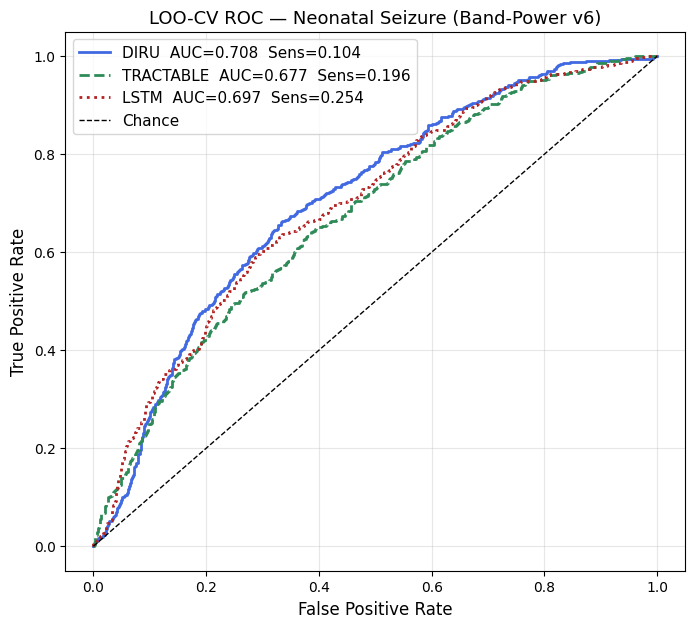

Device=cpu  T_seq=11  features=40
hidden=32 (all models)  epochs=40  batch=32
Loading cached features: /content/drive/MyDrive/checkpoints/loo_features_v6.pkl
  76 recordings loaded
  diru        : 13,765 params
  tractable   : 3,457 params
  lstm        : 9,505 params

Starting LOO over 76 recordings ...


LOO folds: 100%|██████████| 76/76 [2:41:12<00:00, 127.28s/it]


  36 folds had single-class test recordings (predictions included in pooled eval)

LOO-CV SUMMARY
  DIRU          Sens=0.492  Spec=0.844  AUC=0.765  F1=0.304  Acc=0.815  thr=0.36
  TRACTABLE     Sens=0.565  Spec=0.757  AUC=0.730  F1=0.264  Acc=0.741  thr=0.31
  LSTM          Sens=0.531  Spec=0.844  AUC=0.789  F1=0.325  Acc=0.819  thr=0.37

  DIRU vs LSTM  ΔAUC = -2.4 pp
Results saved: /content/drive/MyDrive/checkpoints/loo_results_v6.pkl
ROC saved: /content/drive/MyDrive/checkpoints/roc_loo_v6.png


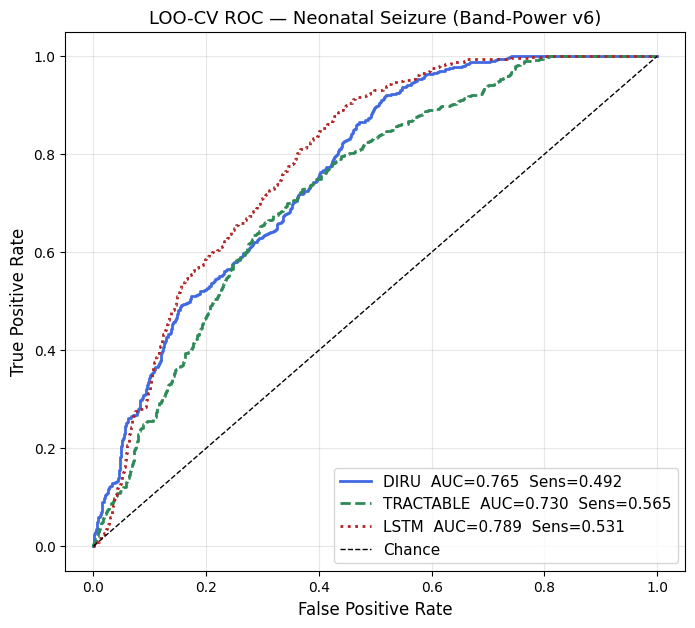

In [ ]:
"""
Helsinki Neonatal EEG - Band Power Spectrum Features  (v6 - LOO-CV)

Changes vs v5
─────────────
1. Leave-One-Out CV: features pre-computed once for all 79 recordings,
   z-score re-fitted inside each fold on the 78 training recordings.

2. DIRU fix: each compartment now receives the FULL 40-feature input
   with its own dedicated W_in weights — same input as LSTM/Tractable.
   The inductive bias is the K separate learned projections, not input
   restriction. Hidden size unchanged (32) — fair comparison.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt, resample
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
from pathlib import Path
import pyedflib
import gc
import pickle
from tqdm import tqdm
from collections import defaultdict

# ============================================================
# Config
# ============================================================
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 40
BATCH_SIZE = 32
HIDDEN_SIZE     = 32
DIRU_DROPOUT    = 0.5
N_COMPARTMENTS  = 4

WINDOW_SIZE        = 3
OVERLAP            = 0.75
FIRST_N_TIMEPOINTS = 15417
FRAME_LEN_SEC      = 0.5
FRAME_STEP_SEC     = 0.25

SELECTED_CHANNELS = [2, 3, 4, 5, 12, 13, 8, 9]
N_CHANNELS        = len(SELECTED_CHANNELS)   # 8

SUBBANDS = [
    ("delta", 0.5,  4.0),
    ("theta", 4.0,  8.0),
    ("alpha", 8.0,  13.0),
    ("beta",  13.0, 30.0),
    ("gamma", 30.0, 50.0),
]
N_BANDS         = len(SUBBANDS)
FULL_INPUT_SIZE = N_BANDS * N_CHANNELS   # 40

CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints"
FEATURE_CACHE  = "/content/drive/MyDrive/checkpoints/loo_features_v6.pkl"

_FS       = 256
_FL       = int(FRAME_LEN_SEC  * _FS)
_FS_STEP  = int(FRAME_STEP_SEC * _FS)
_WIN_SAMP = int(WINDOW_SIZE    * _FS)
T_SEQ     = 1 + (_WIN_SAMP - _FL) // _FS_STEP   # 11

print(f"Device={DEVICE}  T_seq={T_SEQ}  features={FULL_INPUT_SIZE}")
print(f"hidden={HIDDEN_SIZE} (all models)  epochs={NUM_EPOCHS}  batch={BATCH_SIZE}")
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)


# ============================================================
# Signal processing
# ============================================================
# ============================
# Bipolar montage
# ============================
def bipolar_montage(data):
    """
    Convert monopolar EEG to bipolar montage.
    Input:  (channels, samples) → e.g. (21, T)
    Output: (channels-1, samples) → e.g. (20, T)
    """
    return data[1:, :] - data[:-1, :]


def _bp(data, lo, hi, fs, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [max(lo/nyq, 1e-4), min(hi/nyq, 1-1e-4)], btype='band')
    return filtfilt(b, a, data, axis=1)


def compute_band_power_sequence(data, fs=_FS):
    """(n_ch, n_samp) -> (T_seq, 40)  log band-power, unnormalised."""
    n_ch, n_samp = data.shape
    starts   = np.arange(0, n_samp - _FL + 1, _FS_STEP)
    n_frames = len(starts)
    power    = np.zeros((N_BANDS, n_ch, n_frames), dtype=np.float32)

    for b_i, (_, lo, hi) in enumerate(SUBBANDS):
        band = _bp(data, lo, hi, fs)
        for f_i, s in enumerate(starts):
            power[b_i, :, f_i] = np.mean(band[:, s:s+_FL] ** 2, axis=1)

    power = np.log1p(power)
    power = power.transpose(2, 0, 1)           # (T, B, C)
    return power.reshape(n_frames, N_BANDS * n_ch).astype(np.float32)


def load_recording(file_path):
    """Load EDF -> (8, n_samples) preprocessed signal."""
    try:
        edf   = pyedflib.EdfReader(str(file_path))
        sfreq = edf.getSampleFrequency(0)
        data  = np.array([edf.readSignal(i) for i in range(edf.signals_in_file)])
        edf.close()
    except Exception as e:
        print(f"  ERROR loading {Path(file_path).name}: {e}")
        return None
    try:
        if sfreq != _FS:
            data = resample(data, int(data.shape[1] * _FS / sfreq), axis=1)
        b, a     = butter(4, [0.5, 50], fs=_FS, btype='band')
        data     = filtfilt(b, a, data, axis=1)
        b_n, a_n = butter(4, [49, 51], fs=_FS, btype='bandstop')
        data     = filtfilt(b_n, a_n, data, axis=1)
        data    -= data.mean(axis=0, keepdims=True)                     # CAR
        data     = (data - data.mean(axis=1, keepdims=True)) / \
                   (data.std(axis=1, keepdims=True) + 1e-8)             # per-ch z-score
        data     = data[:, :FIRST_N_TIMEPOINTS]
        data     = data[SELECTED_CHANNELS, :]
    except Exception as e:
        print(f"  ERROR preprocessing {Path(file_path).name}: {e}")
        return None
    return data


# ============================================================
# Pre-compute all features once
# ============================================================

def build_all_features(data_path, annotations_path):
    """
    Returns list of dicts, one per valid recording:
      { 'rec_idx', 'file', 'X': (n_win, T_seq, 40), 'y': (n_win,) }
    Raw log-power — z-score applied per LOO fold, not here.
    Cached to disk so second run is instant.
    """
    cache = Path(FEATURE_CACHE)
    if cache.exists():
        print(f"Loading cached features: {cache}")
        recs = pickle.load(open(cache, 'rb'))
        print(f"  {len(recs)} recordings loaded")
        return recs

    ann_df    = pd.read_csv(annotations_path, header=None)
    edf_files = sorted(Path(data_path).glob("eeg*.edf"),
                       key=lambda x: int(''.join(filter(str.isdigit, x.stem))))[:79]

    win_samp  = _WIN_SAMP
    step_samp = max(1, int(win_samp * (1 - OVERLAP)))
    recs      = []

    for edf_file in tqdm(edf_files, desc="Pre-computing features (runs once)"):
        rec_num = int(''.join(filter(str.isdigit, edf_file.stem)))
        col_idx = rec_num - 1
        if col_idx >= ann_df.shape[1]:
            continue

        data = load_recording(edf_file)
        if data is None:
            continue

        annot  = ann_df[col_idx].values[:FIRST_N_TIMEPOINTS]
        X_list, y_list = [], []

        for start in range(0, len(annot) - win_samp, step_samp):
            end    = start + win_samp
            ratio  = float(annot[start:end].sum()) / win_samp
            window = data[:, start:end]
            if window.shape[1] < win_samp:
                window = np.concatenate(
                    [window, np.zeros((window.shape[0], win_samp - window.shape[1]))],
                    axis=1)
            ps = compute_band_power_sequence(window)
            ps = ps[:T_SEQ] if ps.shape[0] >= T_SEQ else \
                 np.vstack([ps, np.zeros((T_SEQ - ps.shape[0], FULL_INPUT_SIZE))])
            X_list.append(ps)
            y_list.append(float(ratio > 0.1))

        if not X_list:
            continue

        recs.append({
            'rec_idx': col_idx,
            'file':    edf_file.name,
            'X':       np.stack(X_list).astype(np.float32),
            'y':       np.array(y_list, dtype=np.float32),
        })

    print(f"Done: {len(recs)} recordings extracted")
    pickle.dump(recs, open(cache, 'wb'))
    print(f"Cached to: {cache}")
    return recs


# ============================================================
# Models — all take (B, T_seq, 40), same hidden_size=32
# ============================================================

class DIRUCell(nn.Module):
    """
    K compartments, each with its own W_in over the FULL input (40 features).
    Inductive bias: K separate learned projections, not input restriction.
    """
    def __init__(self, input_size, hidden_size, num_compartments):
        super().__init__()
        self.num_comp = num_compartments
        self.W_in  = nn.ModuleList([
            nn.Linear(input_size, hidden_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.Linear(hidden_size, hidden_size * num_compartments)
        # gate outputs K scalars (one attention weight per compartment)
        self.gate  = nn.Linear(hidden_size * num_compartments, num_compartments)


    def forward(self, x, h):
        rec   = self.W_rec(h).chunk(self.num_comp, dim=1)
        outs  = [torch.tanh(self.W_in[i](x) + rec[i]) for i in range(self.num_comp)]
        stack = torch.stack(outs, dim=1)                        # (B, K, H)
        # gate: K attention weights via softmax — output magnitude preserved
        w = torch.softmax(self.gate(stack.reshape(stack.size(0), -1)), dim=1)  # (B, K)
        return (stack * w.unsqueeze(2)).sum(dim=1)              # (B, H)


class DIRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size,
                 num_compartments=N_COMPARTMENTS, dropout=DIRU_DROPOUT):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = DIRUCell(input_size, hidden_size, num_compartments)
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(self.dropout(h))


class TractableDendriticCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_compartments):
        super().__init__()
        self.num_comp  = num_compartments
        self.comp_size = hidden_size // num_compartments
        assert hidden_size % num_compartments == 0
        self.W_in  = nn.ModuleList([
            nn.Linear(input_size,  self.comp_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.ModuleList([
            nn.Linear(hidden_size, self.comp_size) for _ in range(num_compartments)
        ])
        self.integration = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        outs = [torch.tanh(self.W_in[i](x) + self.W_rec[i](h))
                for i in range(self.num_comp)]
        return torch.tanh(self.integration(torch.cat(outs, dim=1)))


class TractableDendriticRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size,
                 num_compartments=N_COMPARTMENTS):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = TractableDendriticCell(input_size, hidden_size, num_compartments)
        self.dropout     = nn.Dropout(0.5)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(self.dropout(h))


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                               batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1]))


def make_models():
    return {
        'diru':      DIRU(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
        'tractable': TractableDendriticRNN(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
        'lstm':      LSTMModel(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
    }


# ============================================================
# Per-fold training
# ============================================================

def train_fold(model, X_tr, y_tr, X_val, y_val):
    """
    Train on (X_tr, y_tr), evaluate on (X_val, y_val).
    No checkpointing — each fold trains from scratch and is fast.
    Returns: probs array for X_val.
    """
    tr_ds     = TensorDataset(torch.FloatTensor(X_tr),
                               torch.FloatTensor(y_tr).unsqueeze(1))
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    n_pos = int(y_tr.sum())
    n_neg = len(y_tr) - n_pos
    pw    = torch.FloatTensor([n_neg / max(n_pos, 1)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    optimizer     = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    warmup_epochs = 3
    warmup_sched  = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
    plateau_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-5)

    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    patience      = 8

    X_val_t = torch.FloatTensor(X_val).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1).to(DEVICE)

    for epoch in range(NUM_EPOCHS):
        model.train()
        ep_loss = 0.0
        for bx, by in tr_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
        ep_loss /= len(tr_loader)

        model.eval()
        with torch.no_grad():
            val_loss = nn.BCEWithLogitsLoss()(model(X_val_t), y_val_t).item()

        if epoch < warmup_epochs:
            warmup_sched.step()
        else:
            plateau_sched.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_val_t)).cpu().numpy().flatten()
    return probs


# ============================================================
# LOO loop
# ============================================================

def run_loo(recordings):
    """
    Leave-one-recording-out CV.
    For each fold i: train on 75 recordings, test on 1.
    z-score fitted on train windows only, applied to test.
    ALL predictions aggregated — including recordings with only one class.
    AUC is only meaningful on the pooled set (both classes present overall).
    """
    n           = len(recordings)
    all_probs   = {name: [] for name in ('diru', 'tractable', 'lstm')}
    all_labels  = {name: [] for name in ('diru', 'tractable', 'lstm')}
    single_class_folds = 0

    for fold_i in tqdm(range(n), desc="LOO folds"):
        test_rec   = recordings[fold_i]
        train_recs = [recordings[j] for j in range(n) if j != fold_i]

        X_tr = np.concatenate([r['X'] for r in train_recs], axis=0)
        y_tr = np.concatenate([r['y'] for r in train_recs], axis=0)
        X_te = test_rec['X']
        y_te = test_rec['y']

        if len(np.unique(y_te)) < 2:
            single_class_folds += 1
            # Still include predictions — they contribute TN/TP to pooled eval

        # z-score: fit on train, apply to test — no leakage
        flat   = X_tr.reshape(-1, FULL_INPUT_SIZE)
        mu     = flat.mean(axis=0, keepdims=True)
        std    = flat.std( axis=0, keepdims=True)
        X_tr_n = (X_tr - mu[None]) / (std[None] + 1e-8)
        X_te_n = (X_te - mu[None]) / (std[None] + 1e-8)

        models = make_models()
        for name, model in models.items():
            probs = train_fold(model, X_tr_n, y_tr, X_te_n, y_te)
            all_probs[name].extend(probs.tolist())
            all_labels[name].extend(y_te.tolist())

        del models
        gc.collect()
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

    print(f"  {single_class_folds} folds had single-class test recordings "
          f"(predictions included in pooled eval)")
    return all_probs, all_labels


# ============================================================
# Evaluation & plotting
# ============================================================

def evaluate(all_probs, all_labels):
    print(f"\n{'='*60}\nLOO-CV SUMMARY\n{'='*60}")
    summary = {}
    for name in ('diru', 'tractable', 'lstm'):
        probs  = np.array(all_probs[name])
        labels = np.array(all_labels[name])

        # Find threshold maximising F1 over all LOO predictions
        thresholds = np.linspace(0.05, 0.95, 181)
        best_f1, best_thr = 0., 0.5
        for thr in thresholds:
            preds_t = (probs > thr).astype(int)
            tp = int(((preds_t == 1) & (labels == 1)).sum())
            fp = int(((preds_t == 1) & (labels == 0)).sum())
            fn = int(((preds_t == 0) & (labels == 1)).sum())
            f1_t = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0.
            if f1_t > best_f1:
                best_f1, best_thr = f1_t, thr

        preds = (probs > best_thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.
        spec = tn / (tn + fp) if (tn + fp) else 0.
        auc  = roc_auc_score(labels, probs)
        f1   = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0.
        acc  = accuracy_score(labels, preds)
        summary[name] = dict(sens=sens, spec=spec, auc=auc, f1=f1, acc=acc,
                             probs=probs, labels=labels, threshold=best_thr)
        print(f"  {name.upper():12s}  Sens={sens:.3f}  Spec={spec:.3f}  "
              f"AUC={auc:.3f}  F1={f1:.3f}  Acc={acc:.3f}  thr={best_thr:.2f}")

    d_auc = summary['diru']['auc']
    l_auc = summary['lstm']['auc']
    print(f"\n  DIRU vs LSTM  ΔAUC = {(d_auc - l_auc)*100:+.1f} pp")
    return summary


def plot_roc(summary, save_path=None):
    plt.figure(figsize=(8, 7))
    styles = {'diru':      ('royalblue', '-'),
              'tractable': ('seagreen',  '--'),
              'lstm':      ('firebrick', ':')}
    for name, (col, ls) in styles.items():
        m = summary[name]
        fpr, tpr, _ = roc_curve(m['labels'], m['probs'])
        plt.plot(fpr, tpr, color=col, ls=ls, lw=2,
                 label=f"{name.upper()}  AUC={m['auc']:.3f}  Sens={m['sens']:.3f}")
    plt.plot([0,1],[0,1],'k--',lw=1,label='Chance')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate',  fontsize=12)
    plt.title('LOO-CV ROC — Neonatal Seizure (Band-Power v6)', fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"ROC saved: {save_path}")
    plt.show()


# ============================================================
# Main
# ============================================================

def run(data_path, clear_cache=False):
    if clear_cache:
        p = Path(FEATURE_CACHE)
        if p.exists():
            p.unlink()
            print("Feature cache cleared")

    ann_path   = Path(data_path) / "annotations_2017_A_fixed.csv"
    recordings = build_all_features(data_path, ann_path)

    # Print param counts
    models_ex = make_models()
    for name, m in models_ex.items():
        n_params = sum(p.numel() for p in m.parameters())
        print(f"  {name:12s}: {n_params:,} params")
    del models_ex

    print(f"\nStarting LOO over {len(recordings)} recordings ...")
    all_probs, all_labels = run_loo(recordings)

    summary = evaluate(all_probs, all_labels)

    rpath = Path(CHECKPOINT_DIR) / 'loo_results_v6.pkl'
    pickle.dump({'probs': all_probs, 'labels': all_labels, 'summary': summary},
                open(rpath, 'wb'))
    print(f"Results saved: {rpath}")

    plot_roc(summary, save_path=Path(CHECKPOINT_DIR) / 'roc_loo_v6.png')
    return summary


if __name__ == "__main__":
    DATA_PATH   = "/content/drive/MyDrive/eeg_cache"
    CLEAR_CACHE = False   # set True to re-extract features after pipeline changes

    summary = run(DATA_PATH, clear_cache=CLEAR_CACHE)

In [ ]:
"""
Helsinki Neonatal EEG — Subband Time-Series Classification  (v7 - LOO-CV)

Changes vs v6 (band-power)
──────────────────────────
Feature representation:
  v6: Band-power spectrum
      - Each 3s window → 11 frames × 40 features (log mean-squared power per band/channel)
      - Model sees summarised energy, loses within-band temporal dynamics

  v7: Preprocessed EEG time series split into subbands
      - Each 3s window → bandpass-filter into 5 subbands (delta/theta/alpha/beta/gamma)
      - Each subband downsampled to a common rate (32 Hz) to keep sequences tractable
      - Result: (T_ds, N_bands * N_channels) = (96, 40) per window
      - Model sees actual waveform shape within each band, not just power summaries
      - Richer representation: phase, morphology, burst patterns all preserved

Why this is better for neonatal seizures:
  - Neonatal seizures have characteristic waveform morphology (saw-tooth, rhythmic
    theta bursts) that power summaries discard
  - Delta/theta bands show rhythmic recruitment patterns in ictal activity
  - Temporal structure within a band carries discriminative information
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt, resample_poly
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
from pathlib import Path
import pyedflib
import gc
import pickle
from tqdm import tqdm
from math import gcd

# ============================================================
# Config
# ============================================================
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 40
BATCH_SIZE = 32
HIDDEN_SIZE    = 64   # increased from 32 — richer input warrants more capacity
DIRU_DROPOUT   = 0.5
N_COMPARTMENTS = 4

WINDOW_SIZE        = 3       # seconds
OVERLAP            = 0.75
FIRST_N_TIMEPOINTS = 15417   # ~60s at 256 Hz
DS_RATE_HZ         = 32      # downsample each subband to this rate after filtering

SELECTED_CHANNELS = [2, 3, 4, 5, 12, 13, 8, 9]
N_CHANNELS        = len(SELECTED_CHANNELS)   # 8

SUBBANDS = [
    ("delta", 0.5,  4.0),
    ("theta", 4.0,  8.0),
    ("alpha", 8.0,  13.0),
    ("beta",  13.0, 30.0),
    ("gamma", 30.0, 50.0),
]
N_BANDS = len(SUBBANDS)

_FS       = 256
_WIN_SAMP = int(WINDOW_SIZE * _FS)          # 768 samples at 256 Hz
_DS_SAMP  = int(WINDOW_SIZE * DS_RATE_HZ)   # 96 samples at 32 Hz per subband/channel
T_SEQ     = _DS_SAMP                         # 96 time steps fed to RNN

# Each time step: all subbands × all channels concatenated
FULL_INPUT_SIZE = N_BANDS * N_CHANNELS       # 5 × 8 = 40  (same count as v6, richer content)

CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints"
FEATURE_CACHE  = "/content/drive/MyDrive/checkpoints/loo_features_v7_subband.pkl"

print(f"Device={DEVICE}  T_seq={T_SEQ} (96 time steps at {DS_RATE_HZ}Hz)  "
      f"features={FULL_INPUT_SIZE}")
print(f"hidden={HIDDEN_SIZE}  epochs={NUM_EPOCHS}  batch={BATCH_SIZE}")
print(f"TASK: Ictal vs inter-ictal CLASSIFICATION")
print(f"Representation: subband time-series (NOT band-power summaries)")
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)


# ============================================================
# Signal processing
# ============================================================

def _bandpass(data, lo, hi, fs, order=4):
    """Bandpass filter along axis=1. data: (n_ch, n_samp)"""
    nyq = fs / 2.0
    lo_n = max(lo / nyq, 1e-4)
    hi_n = min(hi / nyq, 1 - 1e-4)
    b, a = butter(order, [lo_n, hi_n], btype='band')
    return filtfilt(b, a, data, axis=1)


def _downsample(data, orig_fs, target_fs):
    """
    Polyphase rational downsample along axis=1.
    data: (n_ch, n_samp) -> (n_ch, n_samp * target_fs / orig_fs)
    """
    g = gcd(int(orig_fs), int(target_fs))
    up   = target_fs // g
    down = orig_fs   // g
    return resample_poly(data, up, down, axis=1)


def compute_subband_sequence(window, fs=_FS):
    """
    Convert a raw EEG window into a subband time-series feature matrix.

    Args:
        window: (N_channels, _WIN_SAMP)  raw preprocessed EEG
        fs:     original sampling rate

    Returns:
        features: (T_SEQ, N_BANDS * N_CHANNELS)
                  Each row is one downsampled time step.
                  Columns: [delta_ch0, delta_ch1, ..., delta_ch7,
                             theta_ch0, ..., gamma_ch7]
    """
    band_signals = []
    for _, lo, hi in SUBBANDS:
        filtered  = _bandpass(window, lo, hi, fs)              # (N_ch, _WIN_SAMP)
        ds        = _downsample(filtered, fs, DS_RATE_HZ)      # (N_ch, _DS_SAMP)
        # Trim/pad to exactly T_SEQ samples
        if ds.shape[1] >= T_SEQ:
            ds = ds[:, :T_SEQ]
        else:
            ds = np.concatenate(
                [ds, np.zeros((ds.shape[0], T_SEQ - ds.shape[1]))], axis=1)
        band_signals.append(ds)                                # (N_ch, T_SEQ)

    # Stack: (N_bands, N_ch, T_SEQ) -> transpose -> (T_SEQ, N_bands * N_ch)
    stacked = np.stack(band_signals, axis=0)                   # (N_bands, N_ch, T_SEQ)
    stacked = stacked.transpose(2, 0, 1)                       # (T_SEQ, N_bands, N_ch)
    return stacked.reshape(T_SEQ, N_BANDS * N_CHANNELS).astype(np.float32)


def load_recording(file_path):
    """Load EDF -> (N_selected_channels, n_samples) preprocessed signal."""
    try:
        edf   = pyedflib.EdfReader(str(file_path))
        sfreq = edf.getSampleFrequency(0)
        data  = np.array([edf.readSignal(i) for i in range(edf.signals_in_file)])
        edf.close()
    except Exception as e:
        print(f"  ERROR loading {Path(file_path).name}: {e}")
        return None
    try:
        if sfreq != _FS:
            g    = gcd(int(sfreq), _FS)
            data = resample_poly(data, _FS // g, int(sfreq) // g, axis=1)
        # Broadband anti-alias filter
        b, a     = butter(4, [0.5, 50], fs=_FS, btype='band')
        data     = filtfilt(b, a, data, axis=1)
        # Notch 50 Hz
        b_n, a_n = butter(4, [49, 51], fs=_FS, btype='bandstop')
        data     = filtfilt(b_n, a_n, data, axis=1)
        # Common average reference
        data    -= data.mean(axis=0, keepdims=True)
        # Per-channel z-score
        data     = (data - data.mean(axis=1, keepdims=True)) / \
                   (data.std(axis=1, keepdims=True) + 1e-8)
        data     = data[:, :FIRST_N_TIMEPOINTS]
        data     = data[SELECTED_CHANNELS, :]
    except Exception as e:
        print(f"  ERROR preprocessing {Path(file_path).name}: {e}")
        return None
    return data


# ============================================================
# Pre-compute all features once
# ============================================================

def build_all_features(data_path, annotations_path):
    """
    Builds feature cache: list of dicts, one per recording.
      { 'rec_idx', 'file', 'X': (n_win, T_SEQ, 40), 'y': (n_win,) }

    X contains raw subband time-series (NOT band power).
    No z-score here — applied per fold to avoid leakage.
    """
    cache = Path(FEATURE_CACHE)
    if cache.exists():
        print(f"Loading cached features: {cache}")
        recs = pickle.load(open(cache, 'rb'))
        print(f"  {len(recs)} recordings loaded  "
              f"(X shape: {recs[0]['X'].shape}  y shape: {recs[0]['y'].shape})")
        return recs

    ann_df    = pd.read_csv(annotations_path, header=None)
    edf_files = sorted(
        Path(data_path).glob("eeg*.edf"),
        key=lambda x: int(''.join(filter(str.isdigit, x.stem)))
    )[:79]

    step_samp = max(1, int(_WIN_SAMP * (1 - OVERLAP)))
    recs      = []

    for edf_file in tqdm(edf_files, desc="Pre-computing subband features (runs once)"):
        rec_num = int(''.join(filter(str.isdigit, edf_file.stem)))
        col_idx = rec_num - 1
        if col_idx >= ann_df.shape[1]:
            continue

        data = load_recording(edf_file)
        if data is None:
            continue

        annot  = ann_df[col_idx].values[:FIRST_N_TIMEPOINTS]
        X_list, y_list = [], []

        for start in range(0, len(annot) - _WIN_SAMP, step_samp):
            end   = start + _WIN_SAMP
            ratio = float(annot[start:end].sum()) / _WIN_SAMP

            window = data[:, start:end]
            if window.shape[1] < _WIN_SAMP:
                window = np.concatenate(
                    [window, np.zeros((window.shape[0], _WIN_SAMP - window.shape[1]))],
                    axis=1)

            feats = compute_subband_sequence(window)  # (T_SEQ, 40)
            X_list.append(feats)
            y_list.append(float(ratio > 0.1))

        if not X_list:
            continue

        recs.append({
            'rec_idx': col_idx,
            'file':    edf_file.name,
            'X':       np.stack(X_list).astype(np.float32),  # (n_win, T_SEQ, 40)
            'y':       np.array(y_list, dtype=np.float32),
        })
        gc.collect()

    print(f"Done: {len(recs)} recordings extracted")
    print(f"  X shape per recording: {recs[0]['X'].shape}")
    pickle.dump(recs, open(cache, 'wb'))
    print(f"Cached to: {cache}")
    return recs


# ============================================================
# Models — all take (B, T_SEQ=96, 40), hidden_size=64
# ============================================================

class DIRUCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_compartments):
        super().__init__()
        self.num_comp = num_compartments
        self.W_in  = nn.ModuleList([
            nn.Linear(input_size, hidden_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.Linear(hidden_size, hidden_size * num_compartments)
        self.gate  = nn.Linear(hidden_size * num_compartments, num_compartments)

    def forward(self, x, h):
        rec   = self.W_rec(h).chunk(self.num_comp, dim=1)
        outs  = [torch.tanh(self.W_in[i](x) + rec[i]) for i in range(self.num_comp)]
        stack = torch.stack(outs, dim=1)                     # (B, K, H)
        w     = torch.softmax(
            self.gate(stack.reshape(stack.size(0), -1)), dim=1)  # (B, K)
        return (stack * w.unsqueeze(2)).sum(dim=1)           # (B, H)


class DIRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size,
                 num_compartments=N_COMPARTMENTS, dropout=DIRU_DROPOUT):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = DIRUCell(input_size, hidden_size, num_compartments)
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(self.dropout(h))


class TractableDendriticCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_compartments):
        super().__init__()
        self.num_comp  = num_compartments
        self.comp_size = hidden_size // num_compartments
        assert hidden_size % num_compartments == 0
        self.W_in  = nn.ModuleList([
            nn.Linear(input_size,  self.comp_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.ModuleList([
            nn.Linear(hidden_size, self.comp_size) for _ in range(num_compartments)
        ])
        self.integration = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        outs = [torch.tanh(self.W_in[i](x) + self.W_rec[i](h))
                for i in range(self.num_comp)]
        return torch.tanh(self.integration(torch.cat(outs, dim=1)))


class TractableDendriticRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size,
                 num_compartments=N_COMPARTMENTS):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = TractableDendriticCell(input_size, hidden_size, num_compartments)
        self.dropout     = nn.Dropout(0.5)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(self.dropout(h))


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                               batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1]))


def make_models():
    return {
        'diru':      DIRU(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
        'tractable': TractableDendriticRNN(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
        'lstm':      LSTMModel(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
    }


# ============================================================
# Per-fold training
# ============================================================

def train_fold(model, X_tr, y_tr, X_val, y_val):
    tr_ds     = TensorDataset(torch.FloatTensor(X_tr),
                               torch.FloatTensor(y_tr).unsqueeze(1))
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    n_pos = int(y_tr.sum())
    n_neg = len(y_tr) - n_pos
    pw    = torch.FloatTensor([n_neg / max(n_pos, 1)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    optimizer     = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    warmup_epochs = 3
    warmup_sched  = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
    plateau_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-5)

    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    patience      = 8

    X_val_t = torch.FloatTensor(X_val).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1).to(DEVICE)

    for epoch in range(NUM_EPOCHS):
        model.train()
        ep_loss = 0.0
        for bx, by in tr_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
        ep_loss /= len(tr_loader)

        model.eval()
        with torch.no_grad():
            val_loss = nn.BCEWithLogitsLoss()(model(X_val_t), y_val_t).item()

        if epoch < warmup_epochs:
            warmup_sched.step()
        else:
            plateau_sched.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_val_t)).cpu().numpy().flatten()
    return probs


# ============================================================
# LOO loop
# ============================================================

def run_loo(recordings):
    """
    Leave-one-recording-out CV.
    z-score fitted on training windows only, applied to test — no leakage.
    All predictions pooled for final ROC/AUC.
    """
    n                  = len(recordings)
    all_probs          = {name: [] for name in ('diru', 'tractable', 'lstm')}
    all_labels         = {name: [] for name in ('diru', 'tractable', 'lstm')}
    single_class_folds = 0

    for fold_i in tqdm(range(n), desc="LOO folds"):
        test_rec   = recordings[fold_i]
        train_recs = [recordings[j] for j in range(n) if j != fold_i]

        X_tr = np.concatenate([r['X'] for r in train_recs], axis=0)
        y_tr = np.concatenate([r['y'] for r in train_recs], axis=0)
        X_te = test_rec['X']
        y_te = test_rec['y']

        if len(np.unique(y_te)) < 2:
            single_class_folds += 1

        # z-score: fit on train only (over time & feature axes), apply to test
        flat = X_tr.reshape(-1, FULL_INPUT_SIZE)
        mu   = flat.mean(axis=0)
        std  = flat.std(axis=0)

        X_tr_n = (X_tr - mu) / (std + 1e-8)
        X_te_n = (X_te - mu) / (std + 1e-8)

        models = make_models()
        for name, model in models.items():
            probs = train_fold(model, X_tr_n, y_tr, X_te_n, y_te)
            all_probs[name].extend(probs.tolist())
            all_labels[name].extend(y_te.tolist())

        del models
        gc.collect()
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

    print(f"  {single_class_folds}/{n} folds had single-class test recordings "
          f"(included in pooled eval)")
    return all_probs, all_labels


# ============================================================
# Evaluation & plotting
# ============================================================

def evaluate(all_probs, all_labels):
    print(f"\n{'='*60}\nLOO-CV SUMMARY  (subband time-series, v7)\n{'='*60}")
    summary = {}
    for name in ('diru', 'tractable', 'lstm'):
        probs  = np.array(all_probs[name])
        labels = np.array(all_labels[name])

        thresholds = np.linspace(0.05, 0.95, 181)
        best_f1, best_thr = 0., 0.5
        for thr in thresholds:
            preds_t = (probs > thr).astype(int)
            tp = int(((preds_t == 1) & (labels == 1)).sum())
            fp = int(((preds_t == 1) & (labels == 0)).sum())
            fn = int(((preds_t == 0) & (labels == 1)).sum())
            f1_t = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0.
            if f1_t > best_f1:
                best_f1, best_thr = f1_t, thr

        preds = (probs > best_thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.
        spec = tn / (tn + fp) if (tn + fp) else 0.
        auc  = roc_auc_score(labels, probs)
        f1   = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0.
        acc  = accuracy_score(labels, preds)

        summary[name] = dict(sens=sens, spec=spec, auc=auc, f1=f1, acc=acc,
                             probs=probs, labels=labels, threshold=best_thr)
        print(f"  {name.upper():12s}  Sens={sens:.3f}  Spec={spec:.3f}  "
              f"AUC={auc:.3f}  F1={f1:.3f}  Acc={acc:.3f}  thr={best_thr:.2f}")

    d_auc = summary['diru']['auc']
    l_auc = summary['lstm']['auc']
    print(f"\n  DIRU vs LSTM  ΔAUC = {(d_auc - l_auc)*100:+.1f} pp")
    print(f"\n  v6 band-power baseline: DIRU≈0.90  LSTM≈0.85")
    print(f"  v7 subband time-series: above numbers show improvement/regression")
    return summary


def plot_roc(summary, save_path=None):
    plt.figure(figsize=(8, 7))
    styles = {'diru':      ('royalblue', '-'),
              'tractable': ('seagreen',  '--'),
              'lstm':      ('firebrick', ':')}
    for name, (col, ls) in styles.items():
        m = summary[name]
        fpr, tpr, _ = roc_curve(m['labels'], m['probs'])
        plt.plot(fpr, tpr, color=col, ls=ls, lw=2,
                 label=f"{name.upper()}  AUC={m['auc']:.3f}  Sens={m['sens']:.3f}")
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate',  fontsize=12)
    plt.title('LOO-CV ROC — Neonatal Seizure Classification\n'
              'Subband time-series (v7) vs band-power (v6)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"ROC saved: {save_path}")
    plt.show()


# ============================================================
# Main
# ============================================================

def run(data_path, clear_cache=False):
    if clear_cache:
        p = Path(FEATURE_CACHE)
        if p.exists():
            p.unlink()
            print("Feature cache cleared")

    ann_path   = Path(data_path) / "annotations_2017_A_fixed.csv"
    recordings = build_all_features(data_path, ann_path)

    models_ex = make_models()
    print(f"\n{'='*60}\nMODEL PARAMETERS\n{'='*60}")
    for name, m in models_ex.items():
        n_params = sum(p.numel() for p in m.parameters())
        print(f"  {name:12s}: {n_params:,} params")
    del models_ex

    print(f"\nStarting LOO over {len(recordings)} recordings ...")
    all_probs, all_labels = run_loo(recordings)

    summary = evaluate(all_probs, all_labels)

    rpath = Path(CHECKPOINT_DIR) / 'loo_results_v7_subband.pkl'
    pickle.dump({'probs': all_probs, 'labels': all_labels, 'summary': summary},
                open(rpath, 'wb'))
    print(f"Results saved: {rpath}")

    plot_roc(summary, save_path=Path(CHECKPOINT_DIR) / 'roc_loo_v7_subband.png')
    return summary


if __name__ == "__main__":
    DATA_PATH   = "/content/drive/MyDrive/eeg_cache"
    CLEAR_CACHE = False

    summary = run(DATA_PATH, clear_cache=CLEAR_CACHE)

Device=cpu  T_seq=96 (96 time steps at 32Hz)  features=40
hidden=64  epochs=40  batch=32
TASK: Ictal vs inter-ictal CLASSIFICATION
Representation: subband time-series (NOT band-power summaries)


Pre-computing subband features (runs once):   5%|▌         | 4/79 [00:38<09:09,  7.32s/it]

  ERROR loading eeg4.edf: /content/drive/MyDrive/eeg_cache/eeg4.edf: the file is not EDF(+) or BDF(+) compliant the label is incorrect


Pre-computing subband features (runs once):  37%|███▋      | 29/79 [04:09<04:58,  5.97s/it]

  ERROR loading eeg29.edf: /content/drive/MyDrive/eeg_cache/eeg29.edf: the file is not EDF(+) or BDF(+) compliant the label is incorrect


Pre-computing subband features (runs once):  63%|██████▎   | 50/79 [07:02<03:23,  7.02s/it]

  ERROR loading eeg50.edf: /content/drive/MyDrive/eeg_cache/eeg50.edf: the file is not EDF(+) or BDF(+) compliant the label is incorrect


Pre-computing subband features (runs once): 100%|██████████| 79/79 [10:50<00:00,  8.23s/it]


Done: 76 recordings extracted
  X shape per recording: (77, 96, 40)
Cached to: /content/drive/MyDrive/checkpoints/loo_features_v7_subband.pkl

MODEL PARAMETERS
  diru        : 28,229 params
  tractable   : 11,009 params
  lstm        : 27,201 params

Starting LOO over 76 recordings ...


LOO folds:   3%|▎         | 2/76 [34:15<22:16:49, 1083.92s/it]

In [ ]:
"""
Nigeria / Guinea-Bissau EEG — Control vs Epileptic Classification  (v1)

Data format
───────────
  - Gzipped CSV files (NOT EDF): EEGs_Guinea-Bissau/signal-{id}.csv.gz
                                  EEGs_Nigeria/signal-{session}.csv.gz
  - First column: sample index (discarded)
  - Columns 1–14: 14 EEG channels @ 128 Hz
  - Metadata CSV: subject.id, Group (Epilepsy/Control), Eyes.condition,
                  recordedPeriod, ...

Data selection (matching notebook logic)
─────────────────────────────────────────
  Only closed-eyes data is used (50% of rows, first or last half depending
  on Eyes.condition first word).  This matches load_eeg_from_gz() in the
  original notebook.

Feature pipeline (identical to Helsinki v6)
────────────────────────────────────────────
  Raw signal (14 ch, 128 Hz)
    → bandpass 1–40  Hz + bipolar referencing + per-channel z-score
    → 5 subbands → sliding 0.5s frame → mean(x²) → log1p
    → (T_seq=11, 70)   [14 ch × 5 bands]
    → z-score per LOO fold

LOO-CV: leave one SUBJECT out per fold.
Label: 0 = Control, 1 = Epilepsy (subject-level, repeated across windows).
"""

import gzip
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt, resample
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
from pathlib import Path
import gc
import pickle
from tqdm import tqdm

# ============================================================
# Config
# ============================================================
DATASET_DIR    = "/content/drive_mount/.shortcut-targets-by-id/1NtgDtnXESKUfllHY7gxV__B9Cb9Eciaz/DATASET" #"/content/drive/MyDrive/DATASET"   # folder with CSV and EEG subdirs
METADATA_CSV   = "metadata_guineabissau.csv"         # relative to DATASET_DIR
EEG_SUBDIR     = "EEGs_Guinea-Bissau"                # subfolder with .csv.gz files
FILE_PATTERN   = "signal-{subject_id}.csv.gz"        # {subject_id} = subject.id column

# For Nigeria, change to:
# METADATA_CSV  = "metadata_nigeria.csv"
# EEG_SUBDIR    = "EEGs_Nigeria"
# FILE_PATTERN  = "signal-{csv_file}"   # nigeria uses session-based filenames in csv.file col
# Nigeria also needs: FILE_COL = "csv.file"  (already contains path fragment)

CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints"
FEATURE_CACHE  = "/content/drive/MyDrive/checkpoints/guinea_features_v1.pkl"

# Signal
SOURCE_FS    = 128        # sampling frequency of the recordings
TARGET_FS    = 128        # keep as-is (no resample needed)
N_CHANNELS   = 14        # columns 1–14 of each CSV
EEG_COL_SLICE = slice(1, 15)   # iloc[:, 1:15] — skip index column

# Closed-eyes extraction (matching notebook: 50% of rows)
CLOSED_EYES_PERC = 0.5

# Window / feature
WINDOW_SIZE    = 3        # seconds
OVERLAP        = 0.75
FRAME_LEN_SEC  = 0.5
FRAME_STEP_SEC = 0.25

SUBBANDS = [
    ("delta", 0.5,  4.0),
    ("theta", 4.0,  8.0),
    ("alpha", 8.0,  13.0),
    ("beta",  13.0, 30.0),
    ("gamma", 30.0, 45.0),
]
N_BANDS         = len(SUBBANDS)
FULL_INPUT_SIZE = N_BANDS * N_CHANNELS   # 70

# Model
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
HIDDEN_SIZE    = 32
N_COMPARTMENTS = 4
DIRU_DROPOUT   = 0.5
NUM_EPOCHS     = 40
BATCH_SIZE     = 32

# Derived
_FL       = int(FRAME_LEN_SEC  * TARGET_FS)
_FS_STEP  = int(FRAME_STEP_SEC * TARGET_FS)
_WIN_SAMP = int(WINDOW_SIZE    * TARGET_FS)
T_SEQ     = 1 + (_WIN_SAMP - _FL) // _FS_STEP   # 11

print(f"Device={DEVICE}  T_seq={T_SEQ}  features={FULL_INPUT_SIZE}")
print(f"hidden={HIDDEN_SIZE} (all models)  epochs={NUM_EPOCHS}  batch={BATCH_SIZE}")
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)


# ============================================================
# Data loading
# ============================================================

def load_closed_eyes(file_path, first_condition, file_rows_count=None):
    """
    Load the closed-eyes portion of a .csv.gz EEG file.
    Returns (14, n_samples) numpy array or None on error.

    first_condition : "closed" → use first 50% of rows
                      "open"   → use last 50% of rows
    """
    try:
        perc = CLOSED_EYES_PERC

        with gzip.open(file_path, 'rt') as f:
            if file_rows_count is not None:
                rows_to_read = int(file_rows_count * perc)
                if first_condition == "closed":
                    df = pd.read_csv(f, nrows=rows_to_read, on_bad_lines='skip')
                else:  # "open" — skip first half
                    skip_rows = file_rows_count - rows_to_read
                    df = pd.read_csv(f, skiprows=range(1, skip_rows + 1),
                                     on_bad_lines='skip')
            else:
                # No row count available: load all, then slice
                df = pd.read_csv(f, on_bad_lines='skip')
                rows_to_read = int(len(df) * perc)
                if first_condition == "closed":
                    df = df.iloc[:rows_to_read]
                else:
                    df = df.iloc[-rows_to_read:]

    except Exception as e:
        print(f"  ERROR loading {Path(file_path).name}: {e}")
        return None

    try:
        eeg = df.iloc[:, EEG_COL_SLICE].values.T.astype(np.float32)  # (14, T)
        if eeg.shape[0] != N_CHANNELS:
            print(f"  WARNING: {Path(file_path).name} has {eeg.shape[0]} ch, expected {N_CHANNELS}")
            return None
    except Exception as e:
        print(f"  ERROR extracting channels from {Path(file_path).name}: {e}")
        return None

    return eeg


def preprocess(data):
    """
    (14, n_samples) raw EEG → (14, n_samples) preprocessed.
    Bandpass 1–45 Hz, notch 49–51 Hz, CAR, per-channel z-score.
    """
    fs = TARGET_FS
    try:
        b, a     = butter(4, [1.0, 45.0], fs=fs, btype='band')
        data     = filtfilt(b, a, data, axis=1)
        b_n, a_n = butter(4, [49, 51],   fs=fs, btype='bandstop')
        data     = filtfilt(b_n, a_n, data, axis=1)
        data    -= data.mean(axis=0, keepdims=True)                 # CAR
        data     = (data - data.mean(axis=1, keepdims=True)) / \
                   (data.std(axis=1, keepdims=True) + 1e-8)         # per-ch z-score
    except Exception as e:
        print(f"  ERROR in preprocess: {e}")
        return None
    return data


# ============================================================
# Band-power feature extraction
# ============================================================

def _bp(data, lo, hi, fs, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [max(lo/nyq, 1e-4), min(hi/nyq, 1-1e-4)], btype='band')
    return filtfilt(b, a, data, axis=1)


def compute_band_power_sequence(data):
    """(N_CHANNELS, n_samp) -> (T_seq, N_BANDS*N_CHANNELS)  log band-power."""
    n_ch, n_samp = data.shape
    starts   = np.arange(0, n_samp - _FL + 1, _FS_STEP)
    n_frames = len(starts)
    power    = np.zeros((N_BANDS, n_ch, n_frames), dtype=np.float32)
    for b_i, (_, lo, hi) in enumerate(SUBBANDS):
        band = _bp(data, lo, hi, TARGET_FS)
        for f_i, s in enumerate(starts):
            power[b_i, :, f_i] = np.mean(band[:, s:s+_FL] ** 2, axis=1)
    power = np.log1p(power)
    power = power.transpose(2, 0, 1)     # (T, B, C)
    return power.reshape(n_frames, N_BANDS * n_ch).astype(np.float32)


# ============================================================
# Pre-compute all features once
# ============================================================

def build_all_features(dataset_dir):
    """
    Reads metadata CSV, loads each subject's closed-eyes EEG,
    extracts band-power windows.

    Returns list of dicts:
      { 'subject_id', 'subject_label': 0/1,
        'X': (n_win, T_seq, 70), 'y': (n_win,) }
    """
    cache = Path(FEATURE_CACHE)
    if cache.exists():
        print(f"Loading cached features: {cache}")
        recs = pickle.load(open(cache, 'rb'))
        print(f"  {len(recs)} subjects  "
              f"(ctrl={sum(r['subject_label']==0 for r in recs)}, "
              f"epi={sum(r['subject_label']==1 for r in recs)})")
        return recs

    dataset_dir = Path(dataset_dir)
    meta = pd.read_csv(dataset_dir / METADATA_CSV)

    # Derive first_condition from Eyes.condition
    meta['first_condition'] = meta['Eyes.condition'].str.split('-').str[0]

    # Build file paths
    meta['file_path'] = meta['subject.id'].apply(
        lambda sid: str(dataset_dir / EEG_SUBDIR /
                        FILE_PATTERN.format(subject_id=sid)))

    # Binary label
    meta['label'] = (meta['Group'].str.strip().str.lower() == 'epilepsy').astype(int)

    win_samp  = _WIN_SAMP
    step_samp = max(1, int(win_samp * (1 - OVERLAP)))
    recs      = []

    for _, row in tqdm(meta.iterrows(), total=len(meta),
                       desc="Pre-computing features"):
        fp = row['file_path']
        if not Path(fp).exists():
            print(f"  MISSING: {Path(fp).name}")
            continue

        # row count if available (speeds up loading)
        row_count = int(row['recordedPeriod'] * SOURCE_FS) \
                    if 'recordedPeriod' in row else None

        raw = load_closed_eyes(fp, row['first_condition'], row_count)
        if raw is None:
            continue

        data = preprocess(raw)
        if data is None:
            continue

        n_samp = data.shape[1]
        X_list = []
        for start in range(0, n_samp - win_samp, step_samp):
            window = data[:, start:start+win_samp]
            ps = compute_band_power_sequence(window)
            ps = ps[:T_SEQ] if ps.shape[0] >= T_SEQ else \
                 np.vstack([ps, np.zeros((T_SEQ - ps.shape[0], FULL_INPUT_SIZE))])
            X_list.append(ps)

        if not X_list:
            continue

        X = np.stack(X_list).astype(np.float32)
        y = np.full(len(X_list), float(row['label']), dtype=np.float32)

        recs.append({
            'subject_id':    row['subject.id'],
            'subject_label': int(row['label']),
            'X': X, 'y': y,
        })

    n_ctrl = sum(1 for r in recs if r['subject_label'] == 0)
    n_epi  = sum(1 for r in recs if r['subject_label'] == 1)
    print(f"\nDone: {len(recs)} subjects  ({n_ctrl} control, {n_epi} epilepsy)")
    pickle.dump(recs, open(cache, 'wb'))
    print(f"Cached: {cache}")
    return recs


# ============================================================
# Models — identical to Helsinki v6
# ============================================================

class DIRUCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_compartments):
        super().__init__()
        self.num_comp = num_compartments
        self.W_in  = nn.ModuleList([
            nn.Linear(input_size, hidden_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.Linear(hidden_size, hidden_size * num_compartments)
        self.gate  = nn.Linear(hidden_size * num_compartments, num_compartments)

    def forward(self, x, h):
        rec   = self.W_rec(h).chunk(self.num_comp, dim=1)
        outs  = [torch.tanh(self.W_in[i](x) + rec[i]) for i in range(self.num_comp)]
        stack = torch.stack(outs, dim=1)
        w     = torch.softmax(self.gate(stack.reshape(stack.size(0), -1)), dim=1)
        return (stack * w.unsqueeze(2)).sum(dim=1)


class DIRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size,
                 num_compartments=N_COMPARTMENTS, dropout=DIRU_DROPOUT):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = DIRUCell(input_size, hidden_size, num_compartments)
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(self.dropout(h))


class TractableDendriticCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_compartments):
        super().__init__()
        self.num_comp  = num_compartments
        self.comp_size = hidden_size // num_compartments
        assert hidden_size % num_compartments == 0
        self.W_in  = nn.ModuleList([
            nn.Linear(input_size,  self.comp_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.ModuleList([
            nn.Linear(hidden_size, self.comp_size) for _ in range(num_compartments)
        ])
        self.integration = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        outs = [torch.tanh(self.W_in[i](x) + self.W_rec[i](h))
                for i in range(self.num_comp)]
        return torch.tanh(self.integration(torch.cat(outs, dim=1)))


class TractableDendriticRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size,
                 num_compartments=N_COMPARTMENTS):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = TractableDendriticCell(input_size, hidden_size, num_compartments)
        self.dropout     = nn.Dropout(0.5)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(self.dropout(h))


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                               batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1]))


def make_models():
    return {
        'diru':      DIRU(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
        'tractable': TractableDendriticRNN(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
        'lstm':      LSTMModel(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
    }


# ============================================================
# Per-fold training (identical to Helsinki v6)
# ============================================================

def train_fold(model, X_tr, y_tr, X_val, y_val):
    tr_ds     = TensorDataset(torch.FloatTensor(X_tr),
                               torch.FloatTensor(y_tr).unsqueeze(1))
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    n_pos = int(y_tr.sum())
    n_neg = len(y_tr) - n_pos
    pw    = torch.FloatTensor([n_neg / max(n_pos, 1)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    optimizer     = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    warmup_sched  = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=3)
    plateau_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-5)

    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0

    X_val_t = torch.FloatTensor(X_val).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1).to(DEVICE)

    for epoch in range(NUM_EPOCHS):
        model.train()
        for bx, by in tr_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(bx), by).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = nn.BCEWithLogitsLoss()(model(X_val_t), y_val_t).item()

        if epoch < 3:
            warmup_sched.step()
        else:
            plateau_sched.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= 8:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(X_val_t)).cpu().numpy().flatten()


# ============================================================
# LOO loop — leave one subject out
# ============================================================

LOO_PROGRESS_CACHE = str(Path(CHECKPOINT_DIR) / 'guinea_loo_progress.pkl')

def run_loo(recordings):
    """
    Leave-one-subject-out CV with fold-level checkpointing.
    If interrupted, re-running resumes from the last completed fold.
    Delete LOO_PROGRESS_CACHE to start fresh.
    """
    n = len(recordings)

    # Load existing progress if available
    progress_path = Path(LOO_PROGRESS_CACHE)
    if progress_path.exists():
        saved = pickle.load(open(progress_path, 'rb'))
        all_probs   = saved['all_probs']
        all_labels  = saved['all_labels']
        start_fold  = saved['next_fold']
        print(f"Resuming LOO from fold {start_fold}/{n} "
              f"({start_fold} folds already done)")
    else:
        all_probs   = {name: [] for name in ('diru', 'tractable', 'lstm')}
        all_labels  = {name: [] for name in ('diru', 'tractable', 'lstm')}
        start_fold  = 0

    for fold_i in tqdm(range(start_fold, n), desc="LOO folds",
                       initial=start_fold, total=n):
        test_rec   = recordings[fold_i]
        train_recs = [recordings[j] for j in range(n) if j != fold_i]

        X_tr = np.concatenate([r['X'] for r in train_recs], axis=0)
        y_tr = np.concatenate([r['y'] for r in train_recs], axis=0)
        X_te = test_rec['X']
        y_te = test_rec['y']

        # z-score: fit on train, apply to test
        flat   = X_tr.reshape(-1, FULL_INPUT_SIZE)
        mu     = flat.mean(axis=0, keepdims=True)
        std    = flat.std( axis=0, keepdims=True)
        X_tr_n = (X_tr - mu[None]) / (std[None] + 1e-8)
        X_te_n = (X_te - mu[None]) / (std[None] + 1e-8)

        models = make_models()
        for name, model in models.items():
            probs = train_fold(model, X_tr_n, y_tr, X_te_n, y_te)
            all_probs[name].extend(probs.tolist())
            all_labels[name].extend(y_te.tolist())
        del models

        # Save progress after every completed fold
        pickle.dump({
            'all_probs':  all_probs,
            'all_labels': all_labels,
            'next_fold':  fold_i + 1,
        }, open(progress_path, 'wb'))

        gc.collect()
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

    # All folds done — remove progress file
    if progress_path.exists():
        progress_path.unlink()
        print("LOO complete — progress cache cleared")

    return all_probs, all_labels


# ============================================================
# Evaluation & plotting
# ============================================================

def evaluate(all_probs, all_labels):
    print(f"\n{'='*60}\nLOO-CV SUMMARY  (Control=0  Epilepsy=1)\n{'='*60}")
    summary = {}
    for name in ('diru', 'tractable', 'lstm'):
        probs  = np.array(all_probs[name])
        labels = np.array(all_labels[name])

        # Optimal threshold maximising F1
        best_f1, best_thr = 0., 0.5
        for thr in np.linspace(0.05, 0.95, 181):
            p  = (probs > thr).astype(int)
            tp = int(((p==1)&(labels==1)).sum())
            fp = int(((p==1)&(labels==0)).sum())
            fn = int(((p==0)&(labels==1)).sum())
            f1 = 2*tp/(2*tp+fp+fn) if (2*tp+fp+fn) else 0.
            if f1 > best_f1:
                best_f1, best_thr = f1, thr

        preds = (probs > best_thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
        sens = tp/(tp+fn) if (tp+fn) else 0.
        spec = tn/(tn+fp) if (tn+fp) else 0.
        auc  = roc_auc_score(labels, probs)
        f1   = 2*tp/(2*tp+fp+fn) if (2*tp+fp+fn) else 0.
        acc  = accuracy_score(labels, preds)

        summary[name] = dict(sens=sens, spec=spec, auc=auc, f1=f1, acc=acc,
                             probs=probs, labels=labels, threshold=best_thr)
        print(f"  {name.upper():12s}  Sens={sens:.3f}  Spec={spec:.3f}  "
              f"AUC={auc:.3f}  F1={f1:.3f}  Acc={acc:.3f}  thr={best_thr:.2f}")

    d_auc = summary['diru']['auc']
    l_auc = summary['lstm']['auc']
    print(f"\n  DIRU vs LSTM  ΔAUC = {(d_auc-l_auc)*100:+.1f} pp")
    return summary


def plot_roc(summary, save_path=None):
    plt.figure(figsize=(8, 7))
    styles = {'diru':      ('royalblue', '-'),
              'tractable': ('seagreen',  '--'),
              'lstm':      ('firebrick', ':')}
    for name, (col, ls) in styles.items():
        m = summary[name]
        fpr, tpr, _ = roc_curve(m['labels'], m['probs'])
        plt.plot(fpr, tpr, color=col, ls=ls, lw=2,
                 label=f"{name.upper()}  AUC={m['auc']:.3f}  Sens={m['sens']:.3f}")
    plt.plot([0,1],[0,1],'k--',lw=1,label='Chance')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate',  fontsize=12)
    plt.title('LOO-CV ROC — Control vs Epileptic (Guinea-Bissau EEG)', fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"ROC saved: {save_path}")
    plt.show()


# ============================================================
# Main
# ============================================================

def run(dataset_dir=DATASET_DIR, clear_cache=False):
    if clear_cache:
        p = Path(FEATURE_CACHE)
        if p.exists():
            p.unlink()
            print("Feature cache cleared")

    recordings = build_all_features(dataset_dir)

    models_ex = make_models()
    for name, m in models_ex.items():
        print(f"  {name:12s}: {sum(p.numel() for p in m.parameters()):,} params")
    del models_ex

    n_ctrl = sum(1 for r in recordings if r['subject_label'] == 0)
    n_epi  = sum(1 for r in recordings if r['subject_label'] == 1)
    print(f"\nSubjects: {len(recordings)}  ({n_ctrl} control, {n_epi} epilepsy)")
    print(f"Windows per subject: ~{int(np.mean([len(r['y']) for r in recordings]))}")

    all_probs, all_labels = run_loo(recordings)
    summary = evaluate(all_probs, all_labels)

    rpath = Path(CHECKPOINT_DIR) / 'guinea_loo_results_v1.pkl'
    pickle.dump({'probs': all_probs, 'labels': all_labels, 'summary': summary},
                open(rpath, 'wb'))
    print(f"Results saved: {rpath}")

    plot_roc(summary, save_path=Path(CHECKPOINT_DIR) / 'roc_guinea_v1.png')
    return summary


if __name__ == "__main__":
    CLEAR_CACHE = False
    summary = run(clear_cache=CLEAR_CACHE)

Device=cpu  T_seq=11  features=70
hidden=32 (all models)  epochs=40  batch=32


Pre-computing features:   6%|▌         | 6/97 [00:10<02:44,  1.81s/it]

In [ ]:
pwd

'/content/drive_mount/.shortcut-targets-by-id/1NtgDtnXESKUfllHY7gxV__B9Cb9Eciaz/DATASET'

In [ ]:

import numpy as np
import pandas as pd
import torch

import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt, resample
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
from pathlib import Path
import pyedflib
import gc
import pickle
from tqdm import tqdm
from collections import defaultdict

# ============================================================
# Config
# ============================================================
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 40
BATCH_SIZE = 32
HIDDEN_SIZE     = 32
DIRU_DROPOUT    = 0.5
N_COMPARTMENTS  = 4

WINDOW_SIZE        = 3
OVERLAP            = 0.75
FIRST_N_TIMEPOINTS = 15417
FRAME_LEN_SEC      = 0.5
FRAME_STEP_SEC     = 0.25

#SELECTED_CHANNELS = [2, 3, 4, 5, 12, 13, 8, 9]
SELECTED_CHANNELS = [1, 2, 3, 4, 11, 12, 7, 8]   # 8 channels, matching original selection minus CZ

N_CHANNELS        = len(SELECTED_CHANNELS)   # 8

SUBBANDS = [
    ("delta", 0.5,  4.0),
    ("theta", 4.0,  8.0),
    ("alpha", 8.0,  13.0),
    ("beta",  13.0, 30.0),
    ("gamma", 30.0, 50.0),
]
N_BANDS         = len(SUBBANDS)
FULL_INPUT_SIZE = N_BANDS * N_CHANNELS   # 40

CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints"
FEATURE_CACHE  = "/content/drive/MyDrive/checkpoints/loo_features_v6.pkl"

_FS       = 256
_FL       = int(FRAME_LEN_SEC  * _FS)
_FS_STEP  = int(FRAME_STEP_SEC * _FS)
_WIN_SAMP = int(WINDOW_SIZE    * _FS)
T_SEQ     = 1 + (_WIN_SAMP - _FL) // _FS_STEP   # 11

print(f"Device={DEVICE}  T_seq={T_SEQ}  features={FULL_INPUT_SIZE}")
print(f"hidden={HIDDEN_SIZE} (all models)  epochs={NUM_EPOCHS}  batch={BATCH_SIZE}")
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)


# ============================================================
# Signal processing
# ============================================================
# ============================
# Bipolar montage
# ============================
def bipolar_montage(data):
    """
    Convert monopolar EEG to bipolar montage.
    Input:  (channels, samples) → e.g. (21, T)
    Output: (channels-1, samples) → e.g. (20, T)
    """
    return data[1:, :] - data[:-1, :]


def _bp(data, lo, hi, fs, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [max(lo/nyq, 1e-4), min(hi/nyq, 1-1e-4)], btype='band')
    return filtfilt(b, a, data, axis=1)


def compute_band_power_sequence(data, fs=_FS):
    """(n_ch, n_samp) -> (T_seq, 40)  log band-power, unnormalised."""
    n_ch, n_samp = data.shape
    starts   = np.arange(0, n_samp - _FL + 1, _FS_STEP)
    n_frames = len(starts)
    power    = np.zeros((N_BANDS, n_ch, n_frames), dtype=np.float32)

    for b_i, (_, lo, hi) in enumerate(SUBBANDS):
        band = _bp(data, lo, hi, fs)
        for f_i, s in enumerate(starts):
            power[b_i, :, f_i] = np.mean(band[:, s:s+_FL] ** 2, axis=1)

    power = np.log1p(power)
    power = power.transpose(2, 0, 1)           # (T, B, C)
    return power.reshape(n_frames, N_BANDS * n_ch).astype(np.float32)


def load_recording(file_path):
    """Load EDF -> (8, n_samples) preprocessed signal."""
    try:
        edf   = pyedflib.EdfReader(str(file_path))
        sfreq = edf.getSampleFrequency(0)
        data  = np.array([edf.readSignal(i) for i in range(edf.signals_in_file)])
        edf.close()
    except Exception as e:
        print(f"  ERROR loading {Path(file_path).name}: {e}")
        return None
    try:
        if sfreq != _FS:
            data = resample(data, int(data.shape[1] * _FS / sfreq), axis=1)
        b, a     = butter(4, [0.5, 50], fs=_FS, btype='band')
        data     = filtfilt(b, a, data, axis=1)
        #b_n, a_n = butter(4, [49, 51], fs=_FS, btype='bandstop')
        #data     = filtfilt(b_n, a_n, data, axis=1)

        data = bipolar_montage(data)

        #data    -= data.mean(axis=0, keepdims=True)                     # CAR
        data     = (data - data.mean(axis=1, keepdims=True)) / \
                   (data.std(axis=1, keepdims=True) + 1e-8)             # per-ch z-score
        data     = data[:, :FIRST_N_TIMEPOINTS]
        data     = data[SELECTED_CHANNELS, :]
    except Exception as e:
        print(f"  ERROR preprocessing {Path(file_path).name}: {e}")
        return None
    return data


# ============================================================
# Pre-compute all features once
# ============================================================

def build_all_features(data_path, annotations_path):
    """
    Returns list of dicts, one per valid recording:
      { 'rec_idx', 'file', 'X': (n_win, T_seq, 40), 'y': (n_win,) }
    Raw log-power — z-score applied per LOO fold, not here.
    Cached to disk so second run is instant.
    """
    cache = Path(FEATURE_CACHE)
    if cache.exists():
        print(f"Loading cached features: {cache}")
        recs = pickle.load(open(cache, 'rb'))
        print(f"  {len(recs)} recordings loaded")
        return recs

    ann_df    = pd.read_csv(annotations_path, header=None)
    edf_files = sorted(Path(data_path).glob("eeg*.edf"),
                       key=lambda x: int(''.join(filter(str.isdigit, x.stem))))[:79]

    win_samp  = _WIN_SAMP
    step_samp = max(1, int(win_samp * (1 - OVERLAP)))
    recs      = []

    for edf_file in tqdm(edf_files, desc="Pre-computing features (runs once)"):
        rec_num = int(''.join(filter(str.isdigit, edf_file.stem)))
        col_idx = rec_num - 1
        if col_idx >= ann_df.shape[1]:
            continue

        data = load_recording(edf_file)
        if data is None:
            continue

        annot  = ann_df[col_idx].values[:FIRST_N_TIMEPOINTS]
        X_list, y_list = [], []

        for start in range(0, len(annot) - win_samp, step_samp):
            end    = start + win_samp
            ratio  = float(annot[start:end].sum()) / win_samp
            window = data[:, start:end]
            if window.shape[1] < win_samp:
                window = np.concatenate(
                    [window, np.zeros((window.shape[0], win_samp - window.shape[1]))],
                    axis=1)
            ps = compute_band_power_sequence(window)
            ps = ps[:T_SEQ] if ps.shape[0] >= T_SEQ else \
                 np.vstack([ps, np.zeros((T_SEQ - ps.shape[0], FULL_INPUT_SIZE))])
            X_list.append(ps)
            y_list.append(float(ratio > 0.1))   #it was 0.1

        if not X_list:
            continue

        recs.append({
            'rec_idx': col_idx,
            'file':    edf_file.name,
            'X':       np.stack(X_list).astype(np.float32),
            'y':       np.array(y_list, dtype=np.float32),
        })

    print(f"Done: {len(recs)} recordings extracted")
    pickle.dump(recs, open(cache, 'wb'))
    print(f"Cached to: {cache}")
    return recs


# ============================================================
# Models — all take (B, T_seq, 40), same hidden_size=32
# ============================================================

class DIRUCell(nn.Module):
    """
    K compartments, each with its own W_in over the FULL input (40 features).
    Inductive bias: K separate learned projections, not input restriction.
    """
    def __init__(self, input_size, hidden_size, num_compartments):
        super().__init__()
        self.num_comp = num_compartments
        self.W_in  = nn.ModuleList([
            nn.Linear(input_size, hidden_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.Linear(hidden_size, hidden_size * num_compartments)
        # gate outputs K scalars (one attention weight per compartment)
        self.gate  = nn.Linear(hidden_size * num_compartments, num_compartments)


    def forward(self, x, h):
        rec   = self.W_rec(h).chunk(self.num_comp, dim=1)
        outs  = [torch.tanh(self.W_in[i](x) + rec[i]) for i in range(self.num_comp)]
        stack = torch.stack(outs, dim=1)                        # (B, K, H)
        # gate: K attention weights via softmax — output magnitude preserved
        w = torch.softmax(self.gate(stack.reshape(stack.size(0), -1)), dim=1)  # (B, K)
        return (stack * w.unsqueeze(2)).sum(dim=1)              # (B, H)


class DIRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size,
                 num_compartments=N_COMPARTMENTS, dropout=DIRU_DROPOUT):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = DIRUCell(input_size, hidden_size, num_compartments)
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(self.dropout(h))


class TractableDendriticCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_compartments):
        super().__init__()
        self.num_comp  = num_compartments
        self.comp_size = hidden_size // num_compartments
        assert hidden_size % num_compartments == 0
        self.W_in  = nn.ModuleList([
            nn.Linear(input_size,  self.comp_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.ModuleList([
            nn.Linear(hidden_size, self.comp_size) for _ in range(num_compartments)
        ])
        self.integration = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        outs = [torch.tanh(self.W_in[i](x) + self.W_rec[i](h))
                for i in range(self.num_comp)]
        return torch.tanh(self.integration(torch.cat(outs, dim=1)))


class TractableDendriticRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size,
                 num_compartments=N_COMPARTMENTS):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = TractableDendriticCell(input_size, hidden_size, num_compartments)
        self.dropout     = nn.Dropout(0.5)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(self.dropout(h))


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                               batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1]))


def make_models():
    return {
        'diru':      DIRU(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
        'tractable': TractableDendriticRNN(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
        'lstm':      LSTMModel(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
    }


# ============================================================
# Per-fold training
# ============================================================

def train_fold(model, X_tr, y_tr, X_val, y_val):
    """
    Train on (X_tr, y_tr), evaluate on (X_val, y_val).
    No checkpointing — each fold trains from scratch and is fast.
    Returns: probs array for X_val.
    """
    tr_ds     = TensorDataset(torch.FloatTensor(X_tr),
                               torch.FloatTensor(y_tr).unsqueeze(1))
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    n_pos = int(y_tr.sum())
    n_neg = len(y_tr) - n_pos
    pw    = torch.FloatTensor([n_neg / max(n_pos, 1)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    optimizer     = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    warmup_epochs = 3
    warmup_sched  = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
    plateau_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-5)

    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    patience      = 8

    X_val_t = torch.FloatTensor(X_val).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1).to(DEVICE)

    for epoch in range(NUM_EPOCHS):
        model.train()
        ep_loss = 0.0
        for bx, by in tr_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
        ep_loss /= len(tr_loader)

        model.eval()
        with torch.no_grad():
            val_loss = nn.BCEWithLogitsLoss()(model(X_val_t), y_val_t).item()

        if epoch < warmup_epochs:
            warmup_sched.step()
        else:
            plateau_sched.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_val_t)).cpu().numpy().flatten()
    return probs


# ============================================================
# LOO loop
# ============================================================

def run_loo(recordings):
    """
    Leave-one-recording-out CV.
    For each fold i: train on 75 recordings, test on 1.
    z-score fitted on train windows only, applied to test.
    ALL predictions aggregated — including recordings with only one class.
    AUC is only meaningful on the pooled set (both classes present overall).
    """
    n           = len(recordings)
    all_probs   = {name: [] for name in ('diru', 'tractable', 'lstm')}
    all_labels  = {name: [] for name in ('diru', 'tractable', 'lstm')}
    single_class_folds = 0

    for fold_i in tqdm(range(n), desc="LOO folds"):
        test_rec   = recordings[fold_i]
        train_recs = [recordings[j] for j in range(n) if j != fold_i]

        X_tr = np.concatenate([r['X'] for r in train_recs], axis=0)
        y_tr = np.concatenate([r['y'] for r in train_recs], axis=0)
        X_te = test_rec['X']
        y_te = test_rec['y']

        if len(np.unique(y_te)) < 2:
            single_class_folds += 1
            # Still include predictions — they contribute TN/TP to pooled eval

        # z-score: fit on train, apply to test — no leakage
        flat   = X_tr.reshape(-1, FULL_INPUT_SIZE)
        mu     = flat.mean(axis=0, keepdims=True)
        std    = flat.std( axis=0, keepdims=True)
        X_tr_n = (X_tr - mu[None]) / (std[None] + 1e-8)
        X_te_n = (X_te - mu[None]) / (std[None] + 1e-8)

        models = make_models()
        for name, model in models.items():
            probs = train_fold(model, X_tr_n, y_tr, X_te_n, y_te)
            all_probs[name].extend(probs.tolist())
            all_labels[name].extend(y_te.tolist())

        del models
        gc.collect()
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

    print(f"  {single_class_folds} folds had single-class test recordings "
          f"(predictions included in pooled eval)")
    return all_probs, all_labels


# ============================================================
# Evaluation & plotting
# ============================================================

def evaluate(all_probs, all_labels):
    print(f"\n{'='*60}\nLOO-CV SUMMARY\n{'='*60}")
    summary = {}
    for name in ('diru', 'tractable', 'lstm'):
        probs  = np.array(all_probs[name])
        labels = np.array(all_labels[name])

        # Find threshold maximising F1 over all LOO predictions
        thresholds = np.linspace(0.05, 0.95, 181)
        best_f1, best_thr = 0., 0.5
        for thr in thresholds:
            preds_t = (probs > thr).astype(int)
            tp = int(((preds_t == 1) & (labels == 1)).sum())
            fp = int(((preds_t == 1) & (labels == 0)).sum())
            fn = int(((preds_t == 0) & (labels == 1)).sum())
            f1_t = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0.
            if f1_t > best_f1:
                best_f1, best_thr = f1_t, thr

        preds = (probs > best_thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.
        spec = tn / (tn + fp) if (tn + fp) else 0.
        auc  = roc_auc_score(labels, probs)
        f1   = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0.
        acc  = accuracy_score(labels, preds)
        summary[name] = dict(sens=sens, spec=spec, auc=auc, f1=f1, acc=acc,
                             probs=probs, labels=labels, threshold=best_thr)
        print(f"  {name.upper():12s}  Sens={sens:.3f}  Spec={spec:.3f}  "
              f"AUC={auc:.3f}  F1={f1:.3f}  Acc={acc:.3f}  thr={best_thr:.2f}")

    d_auc = summary['diru']['auc']
    l_auc = summary['lstm']['auc']
    print(f"\n  DIRU vs LSTM  ΔAUC = {(d_auc - l_auc)*100:+.1f} pp")
    return summary


def plot_roc(summary, save_path=None):
    plt.figure(figsize=(8, 7))
    styles = {'diru':      ('royalblue', '-'),
              'tractable': ('seagreen',  '--'),
              'lstm':      ('firebrick', ':')}
    for name, (col, ls) in styles.items():
        m = summary[name]
        fpr, tpr, _ = roc_curve(m['labels'], m['probs'])
        plt.plot(fpr, tpr, color=col, ls=ls, lw=2,
                 label=f"{name.upper()}  AUC={m['auc']:.3f}  Sens={m['sens']:.3f}")
    plt.plot([0,1],[0,1],'k--',lw=1,label='Chance')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate',  fontsize=12)
    plt.title('LOO-CV ROC — Neonatal Seizure (Band-Power v6)', fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"ROC saved: {save_path}")
    plt.show()


# ============================================================
# Main
# ============================================================

def run(data_path, clear_cache=False):
    if clear_cache:
        p = Path(FEATURE_CACHE)
        if p.exists():
            p.unlink()
            print("Feature cache cleared")

    ann_path   = Path(data_path) / "annotations_2017_A_fixed.csv"
    recordings = build_all_features(data_path, ann_path)

    # Print param counts
    models_ex = make_models()
    for name, m in models_ex.items():
        n_params = sum(p.numel() for p in m.parameters())
        print(f"  {name:12s}: {n_params:,} params")
    del models_ex

    print(f"\nStarting LOO over {len(recordings)} recordings ...")
    all_probs, all_labels = run_loo(recordings)

    summary = evaluate(all_probs, all_labels)

    rpath = Path(CHECKPOINT_DIR) / 'loo_results_v6.pkl'
    pickle.dump({'probs': all_probs, 'labels': all_labels, 'summary': summary},
                open(rpath, 'wb'))
    print(f"Results saved: {rpath}")

    plot_roc(summary, save_path=Path(CHECKPOINT_DIR) / 'roc_loo_v6.png')
    return summary


if __name__ == "__main__":
    DATA_PATH   = "/content/drive/MyDrive/eeg_cache"
    CLEAR_CACHE = False   # set True to re-extract features after pipeline changes

    summary = run(DATA_PATH, clear_cache=CLEAR_CACHE)

KeyboardInterrupt: 

Loading: eeg3.edf
Saved: /content/drive/MyDrive/eeg_cache/seizure_viz_rec3.png


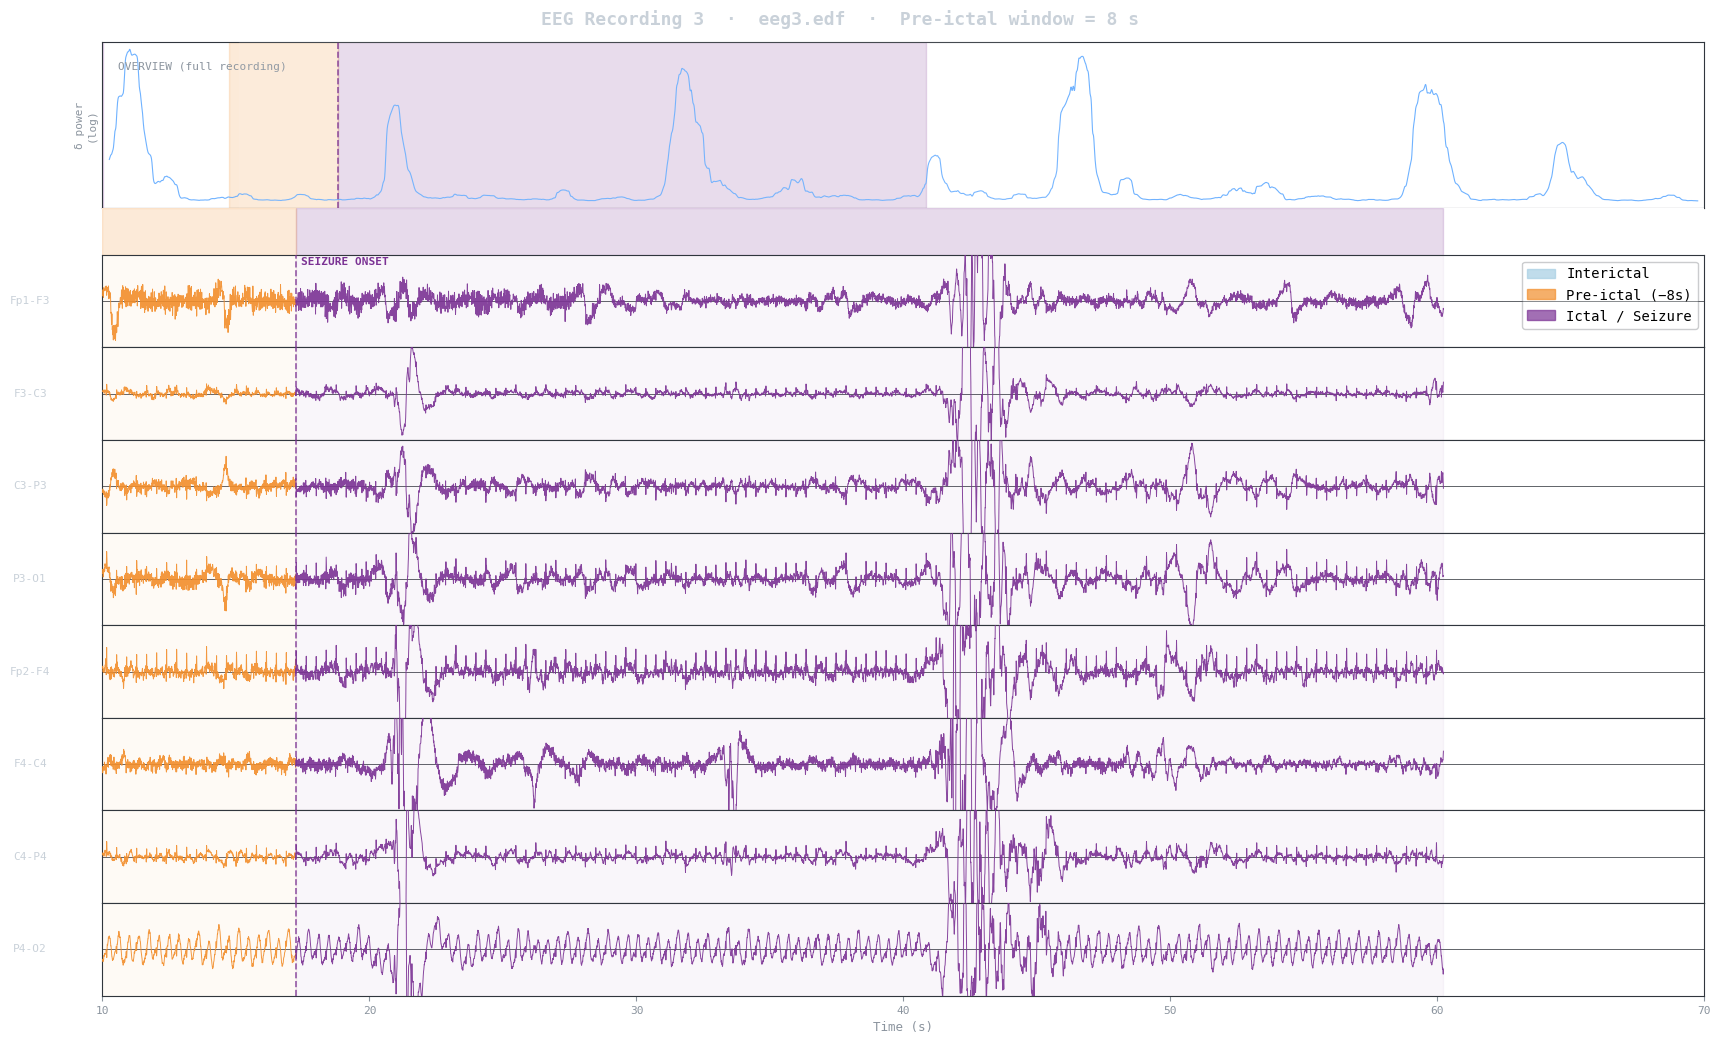

In [ ]:
"""
EEG Seizure Visualizer
======================
Loads real EDF recordings and the annotations_2017_A_fixed.csv from the same
paths used in the training pipeline, then plots any recording with its
seizure and pre-ictal phases clearly marked.

Usage (in Colab, same cell style as your pipeline):
    DATA_PATH  = "/content/drive/MyDrive/eeg_cache"
    REC_NUMBER = 1          # which recording (1-indexed, matches EDF filename)
    PREICTAL_SEC = 8        # seconds before seizure onset to mark as pre-ictal
    run_visualization(DATA_PATH, REC_NUMBER, preictal_sec=PREICTAL_SEC)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.signal import butter, filtfilt, resample
from pathlib import Path
import pyedflib

# ============================================================
# Config — mirrors your training pipeline exactly
# ============================================================
_FS               = 256
FIRST_N_TIMEPOINTS = 30000
SELECTED_CHANNELS  = [1, 2, 3, 4, 11, 12, 7, 8]   # same as pipeline

CHANNEL_NAMES = [
    "Fp1-F3", "F3-C3", "C3-P3", "P3-O1",
    "Fp2-F4", "F4-C4", "C4-P4", "P4-O2",
]

SUBBANDS = [
    ("delta", 0.5,  4.0),
    ("theta", 4.0,  8.0),
    ("alpha", 8.0,  13.0),
    ("beta",  13.0, 30.0),
    ("gamma", 30.0, 50.0),
]

# Visual style
COLORS = {
    "interictal":  "#a6cee3",   # pastel light blue
    "preictal":   "#f28e2b",   # softer orange
    "ictal":      "#7b3294",   # deep purple
    "bg":          "#ffffff", #"#0d1117",
    "panel":       "#ffffff", #"#161b22",
    "grid":       "#21262d",
    "text":       "#c9d1d9",
    "subtext":    "#8b949e",
    "axis":       "#30363d",
}

# ============================================================
# Signal processing — identical to your pipeline
# ============================================================

def bipolar_montage(data):
    """(channels, samples) → (channels-1, samples)"""
    return data[1:, :] - data[:-1, :]


def _bp(data, lo, hi, fs, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [max(lo / nyq, 1e-4), min(hi / nyq, 1 - 1e-4)], btype="band")
    return filtfilt(b, a, data, axis=1)


def load_recording(file_path):
    """Load & preprocess EDF exactly as in the training pipeline."""
    try:
        edf   = pyedflib.EdfReader(str(file_path))
        sfreq = edf.getSampleFrequency(0)
        data  = np.array([edf.readSignal(i) for i in range(edf.signals_in_file)])
        edf.close()
    except Exception as e:
        raise RuntimeError(f"Cannot load {file_path}: {e}")

    if sfreq != _FS:
        data = resample(data, int(data.shape[1] * _FS / sfreq), axis=1)

    b, a = butter(4, [0.5, 50], fs=_FS, btype="band")
    data = filtfilt(b, a, data, axis=1)

    data = bipolar_montage(data)
    data = (data - data.mean(axis=1, keepdims=True)) / (data.std(axis=1, keepdims=True) + 1e-8)
    data = data[:, :FIRST_N_TIMEPOINTS]
    data = data[SELECTED_CHANNELS, :]
    return data   # (8, FIRST_N_TIMEPOINTS)


def load_annotations(annotations_path, rec_number):
    """
    Load the per-sample seizure labels for a recording.
    rec_number: 1-indexed (matches EDF filename, e.g. eeg1.edf → rec_number=1)
    Returns binary array of length FIRST_N_TIMEPOINTS.
    """
    ann_df  = pd.read_csv(annotations_path, header=None)
    col_idx = rec_number - 1
    if col_idx >= ann_df.shape[1]:
        raise ValueError(f"Recording {rec_number} not found in annotation CSV "
                         f"(only {ann_df.shape[1]} columns).")
    labels = ann_df[col_idx].values[:FIRST_N_TIMEPOINTS].astype(float)
    return labels


# ============================================================
# Phase detection from sample-level labels
# ============================================================

def detect_phases(labels, fs=_FS, preictal_sec=8):
    """
    From a binary sample-level annotation array build three arrays:
      ictal_mask, preictal_mask, interictal_mask  (same length as labels)

    Pre-ictal = `preictal_sec` seconds immediately before each seizure onset.
    """
    n = len(labels)
    ictal      = labels.astype(bool)
    preictal   = np.zeros(n, dtype=bool)
    pre_samp   = int(preictal_sec * fs)

    # Find seizure onset indices (0→1 transitions)
    diff = np.diff(ictal.astype(int), prepend=0)
    onsets = np.where(diff == 1)[0]

    for onset in onsets:
        start = max(0, onset - pre_samp)
        preictal[start:onset] = True

    # Remove any preictal overlap with ictal (shouldn't happen, but safety)
    preictal &= ~ictal
    interictal = ~ictal & ~preictal

    return ictal, preictal, interictal


# ============================================================
# Compute band-power envelope (for the overview panel)
# ============================================================

def band_power_envelope(data, band="delta", fs=_FS, win_sec=1.0):
    """
    Mean band power across all channels, smoothed with a sliding window.
    Returns (time_sec, power) arrays.
    """
    lo, hi = {b[0]: (b[1], b[2]) for b in SUBBANDS}[band]
    filtered = _bp(data, lo, hi, fs)              # (8, T)
    power    = (filtered ** 2).mean(axis=0)       # (T,)
    win      = int(win_sec * fs)
    # cumsum-based fast sliding mean
    cs  = np.cumsum(np.insert(power, 0, 0))
    smoothed = (cs[win:] - cs[:-win]) / win
    t = np.arange(len(smoothed)) / fs + win_sec / 2
    return t, np.log1p(smoothed)


# ============================================================
# Main plot
# ============================================================

def run_visualization(data_path, rec_number, preictal_sec=8,
                      view_start_sec=None, view_dur_sec=None,
                      save_path=None):
    """
    Parameters
    ----------
    data_path     : str  – same as DATA_PATH in your pipeline
    rec_number    : int  – 1-indexed recording number (matches eeg{N}.edf)
    preictal_sec  : int  – seconds before seizure onset to label as pre-ictal
    view_start_sec: float|None  – if None, auto-zooms to the seizure context
    view_dur_sec  : float|None  – seconds of signal to display (default 60 s)
    save_path     : str|None    – if given, saves PNG here
    """
    data_path = Path(data_path)
    ann_path  = data_path / "annotations_2017_A_fixed.csv"

    # ── find EDF ─────────────────────────────────────────────────────────────
    edf_candidates = sorted(
        data_path.glob(f"eeg{rec_number}.edf"),
    )
    if not edf_candidates:
        # Try zero-padded variants
        edf_candidates = list(data_path.glob(f"eeg0*{rec_number}.edf"))
    if not edf_candidates:
        raise FileNotFoundError(
            f"Cannot find eeg{rec_number}.edf in {data_path}\n"
            f"Files present: {[p.name for p in sorted(data_path.glob('*.edf'))[:10]]}"
        )
    edf_path = edf_candidates[0]
    print(f"Loading: {edf_path.name}")

    # ── load data & labels ───────────────────────────────────────────────────
    data   = load_recording(edf_path)          # (8, T)
    labels = load_annotations(ann_path, rec_number)
    n_samp = data.shape[1]
    time   = np.arange(n_samp) / _FS          # seconds

    ictal, preictal, interictal = detect_phases(labels, _FS, preictal_sec)

    seizure_present = ictal.any()
    if not seizure_present:
        print(f"  ⚠  Recording {rec_number} has NO seizure annotations. "
              f"Showing full recording with interictal label.")

    # ── auto-zoom window ─────────────────────────────────────────────────────
    if view_dur_sec is None:
        view_dur_sec = 60#120.0   # wider default: ~1 min interictal + pre-ictal + ictal + recovery

    if view_start_sec is None and seizure_present:
        onset_sec = np.where(ictal)[0][0] / _FS
        # Start far enough back to show a clear interictal stretch before pre-ictal
        interictal_context = preictal_sec + 40   # 40 s of interictal before pre-ictal window
        view_start_sec = max(0.0, onset_sec - interictal_context)
    elif view_start_sec is None:
        view_start_sec = 0.0

    view_end_sec = min(view_start_sec + view_dur_sec, time[-1])

    i0 = int(view_start_sec * _FS)
    i1 = int(view_end_sec   * _FS)
    t_view  = time[i0:i1]
    d_view  = data[:, i0:i1]
    ic_view = ictal[i0:i1]
    pr_view = preictal[i0:i1]
    ii_view = interictal[i0:i1]

    # ── band-power overview ──────────────────────────────────────────────────
    bp_t, bp_v = band_power_envelope(data, band="delta")

    # ── layout ───────────────────────────────────────────────────────────────
    n_ch = len(CHANNEL_NAMES)
    fig  = plt.figure(figsize=(18, 3 + n_ch * 0.95), facecolor=COLORS["bg"])
    fig.suptitle(
        f"EEG Recording {rec_number}  ·  eeg{rec_number}.edf  ·  "
        f"Pre-ictal window = {preictal_sec} s",
        color=COLORS["text"], fontsize=13, fontweight="bold", y=0.99,
        fontfamily="monospace",
    )

    gs = GridSpec(
        n_ch + 2, 1,
        figure=fig,
        hspace=0.0,
        top=0.96, bottom=0.06, left=0.09, right=0.98,
        height_ratios=[1.8, 0.5] + [1.0] * n_ch,
    )

    # ── Panel 0: band-power overview (full recording) ────────────────────────
    ax_bp = fig.add_subplot(gs[0])
    ax_bp.set_facecolor(COLORS["panel"])
    for spine in ax_bp.spines.values():
        spine.set_edgecolor(COLORS["axis"])

    # shade phases on full timeline
    full_time = np.arange(len(labels)) / _FS
    _shade_phases(ax_bp, full_time, ictal, preictal,
                  ymin=0, ymax=1, transform="axes")
    ax_bp.plot(bp_t, bp_v, color="#60aaff", lw=0.8, alpha=0.9)
    ax_bp.set_xlim(0, time[-1])
    ax_bp.set_ylabel("δ power\n(log)", color=COLORS["subtext"],
                     fontsize=8, fontfamily="monospace")
    ax_bp.set_yticks([])
    ax_bp.tick_params(labelbottom=False, bottom=False, colors=COLORS["subtext"])
    # view-window marker
    ax_bp.axvspan(view_start_sec, view_end_sec,
                  color="white", alpha=0.07, zorder=5)
    ax_bp.text(0.01, 0.88, "OVERVIEW (full recording)",
               transform=ax_bp.transAxes, color=COLORS["subtext"],
               fontsize=8, fontfamily="monospace", va="top")

    # ── Panel 1: thin phase-color bar ────────────────────────────────────────
    ax_bar = fig.add_subplot(gs[1])
    ax_bar.set_facecolor(COLORS["bg"])
    for spine in ax_bar.spines.values():
        spine.set_visible(False)
    ax_bar.set_xlim(view_start_sec, view_end_sec)
    ax_bar.set_ylim(0, 1)
    ax_bar.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
    _shade_phases_xy(ax_bar, t_view, ic_view, pr_view, ymin=0, ymax=1)

    # ── Panels 2…: EEG channels ──────────────────────────────────────────────
    GAIN = 2.5   # amplitude scale (z-scored signal, ±2 units → ±2.5 * CH_HEIGHT)
    axes_ch = []
    for ch in range(n_ch):
        ax = fig.add_subplot(gs[ch + 2])
        ax.set_facecolor(COLORS["panel"])
        for spine in ax.spines.values():
            spine.set_edgecolor(COLORS["axis"])
        axes_ch.append(ax)

        sig = d_view[ch]

        # Phase-coloured shading behind trace
        _shade_phases_xy(ax, t_view, ic_view, pr_view,
                         ymin=-1, ymax=1, alpha_scale=0.25)

        # Colour trace by phase
        _plot_coloured_trace(ax, t_view, sig, ic_view, pr_view, ii_view)

        # Zero line
        ax.axhline(0, color=COLORS["grid"], lw=0.5, zorder=1)

        ax.set_xlim(view_start_sec, view_end_sec)
        ax.set_ylim(-GAIN, GAIN)
        ax.set_yticks([])
        ax.set_ylabel(CHANNEL_NAMES[ch], color=COLORS["text"],
                      fontsize=8, fontfamily="monospace",
                      rotation=0, labelpad=52, va="center")

        if ch < n_ch - 1:
            ax.tick_params(labelbottom=False, bottom=False, colors=COLORS["subtext"])
        else:
            ax.tick_params(colors=COLORS["subtext"])
            ax.set_xlabel("Time (s)", color=COLORS["subtext"],
                          fontsize=9, fontfamily="monospace")
            for label in ax.get_xticklabels():
                label.set_fontfamily("monospace")
                label.set_fontsize(8)
                label.set_color(COLORS["subtext"])

    # ── Phase onset vertical lines ────────────────────────────────────────────
    diff = np.diff(ictal.astype(int), prepend=0)
    for onset_s in np.where(diff == 1)[0] / _FS:
        if view_start_sec <= onset_s <= view_end_sec:
            for ax in axes_ch + [ax_bp]:
                ax.axvline(onset_s, color=COLORS["ictal"],
                           lw=1.2, ls="--", alpha=0.8, zorder=10)
            axes_ch[0].text(onset_s + 0.2, GAIN * 0.78, "SEIZURE ONSET",
                            color=COLORS["ictal"], fontsize=8,
                            fontfamily="monospace", fontweight="bold")

    diff2 = np.diff(preictal.astype(int), prepend=0)
    for pre_s in np.where(diff2 == 1)[0] / _FS:
        if view_start_sec <= pre_s <= view_end_sec:
            for ax in axes_ch:
                ax.axvline(pre_s, color=COLORS["preictal"],
                           lw=1.0, ls=":", alpha=0.7, zorder=10)
            axes_ch[0].text(pre_s + 0.2, GAIN * 0.78, f"PRE-ICTAL ({preictal_sec}s)",
                            color=COLORS["preictal"], fontsize=8,
                            fontfamily="monospace")

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color=COLORS["interictal"], alpha=0.7, label="Interictal"),
        mpatches.Patch(color=COLORS["preictal"],   alpha=0.7, label=f"Pre-ictal (−{preictal_sec}s)"),
        mpatches.Patch(color=COLORS["ictal"],      alpha=0.7, label="Ictal / Seizure"),
    ]
    axes_ch[0].legend(
        handles=legend_patches, loc="upper right",
        framealpha=0.25, facecolor=COLORS["bg"],
        edgecolor=COLORS["axis"], fontsize=8,
        prop={"family": "monospace"},
    )

    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight",
                    facecolor=COLORS["bg"])
        print(f"Saved: {save_path}")

    plt.show()
    return fig


# ============================================================
# Helpers
# ============================================================

def _shade_phases(ax, time, ictal, preictal, ymin=0, ymax=1, transform="data", alpha=0.18):
    """Shade ictal/preictal regions using data-space y coords."""
    _fill_mask(ax, time, ictal,    COLORS["ictal"],    alpha, ymin, ymax)
    _fill_mask(ax, time, preictal, COLORS["preictal"], alpha, ymin, ymax)


def _shade_phases_xy(ax, time, ictal, preictal, ymin=-1, ymax=1,
                     alpha_scale=1.0):
    _fill_mask(ax, time, ictal,    COLORS["ictal"],    0.18 * alpha_scale, ymin, ymax)
    _fill_mask(ax, time, preictal, COLORS["preictal"], 0.18 * alpha_scale, ymin, ymax)


def _fill_mask(ax, time, mask, color, alpha, ymin, ymax):
    """Fill contiguous True-regions of `mask` with a coloured span."""
    if not mask.any():
        return
    diff   = np.diff(mask.astype(int), prepend=0, append=0)
    starts = np.where(diff ==  1)[0]
    ends   = np.where(diff == -1)[0]
    for s, e in zip(starts, ends):
        s = min(s, len(time) - 1)
        e = min(e, len(time) - 1)
        ax.axvspan(time[s], time[e], ymin=0, ymax=1,
                   color=color, alpha=alpha, zorder=2)


def _plot_coloured_trace(ax, time, sig, ictal, preictal, interictal):
    """Plot EEG trace in three colours according to phase."""
    for mask, color in [
        (interictal, COLORS["interictal"]),
        (preictal,   COLORS["preictal"]),
        (ictal,      COLORS["ictal"]),
    ]:
        if not mask.any():
            continue
        # Plot contiguous segments (avoids ugly cross-phase lines)
        diff   = np.diff(mask.astype(int), prepend=0, append=0)
        starts = np.where(diff ==  1)[0]
        ends   = np.where(diff == -1)[0]
        for s, e in zip(starts, ends):
            e = min(e + 1, len(time))
            ax.plot(time[s:e], sig[s:e],
                    color=color, lw=0.7, alpha=0.9, zorder=3)


# ============================================================
# Entry point
# ============================================================

if __name__ == "__main__":
    # ── Edit these three lines ────────────────────────────────────────────────
    DATA_PATH    = "/content/drive/MyDrive/eeg_cache"
    REC_NUMBER   = 3        # which recording to plot (1-indexed)
    PREICTAL_SEC = 8        # seconds before seizure onset to mark as pre-ictal
    # ─────────────────────────────────────────────────────────────────────────

    save_to = Path(DATA_PATH) / f"seizure_viz_rec{REC_NUMBER}.png"
    run_visualization(
        DATA_PATH,
        rec_number   = REC_NUMBER,
        preictal_sec = PREICTAL_SEC,
        #view_dur_sec=180,
        view_start_sec=10,
        save_path    = str(save_to),
    )

Device=cpu  T_seq=11  features=8
hidden=32 (all models)  epochs=40  batch=32
Feature cache cleared


Pre-computing features (runs once):   4%|▍         | 3/79 [00:08<03:08,  2.48s/it]

  ERROR loading eeg4.edf: /content/drive/MyDrive/eeg_cache/eeg4.edf: the file is not EDF(+) or BDF(+) compliant the label is incorrect


Pre-computing features (runs once):  35%|███▌      | 28/79 [01:12<01:41,  1.98s/it]

  ERROR loading eeg29.edf: /content/drive/MyDrive/eeg_cache/eeg29.edf: the file is not EDF(+) or BDF(+) compliant the label is incorrect


...

  ERROR loading eeg50.edf: /content/drive/MyDrive/eeg_cache/eeg50.edf: the file is not EDF(+) or BDF(+) compliant the label is incorrect


Pre-computing features (runs once): 100%|██████████| 79/79 [02:36<00:00,  1.98s/it]


Done: 76 recordings extracted
Cached to: /content/drive/MyDrive/checkpoints/loo_features_v7.pkl
  diru        : 5,925 params
  tractable   : 2,433 params
  lstm        : 5,409 params

Starting LOO over 76 recordings ...


LOO folds: 100%|██████████| 76/76 [51:10<00:00, 40.40s/it]


  55 folds had single-class test recordings (predictions included in pooled eval)

LOO-CV SUMMARY
  DIRU          Sens=0.042  Spec=0.996  AUC=0.505  F1=0.072  Acc=0.971  thr=0.70
  TRACTABLE     Sens=0.236  Spec=0.939  AUC=0.506  F1=0.137  Acc=0.920  thr=0.55
  LSTM          Sens=0.194  Spec=0.945  AUC=0.469  F1=0.121  Acc=0.925  thr=0.53

  DIRU vs LSTM  ΔAUC = +3.6 pp
Results saved: /content/drive/MyDrive/checkpoints/loo_results_v7.pkl
Resume checkpoint cleaned up
ROC saved: /content/drive/MyDrive/checkpoints/roc_loo_v7.png


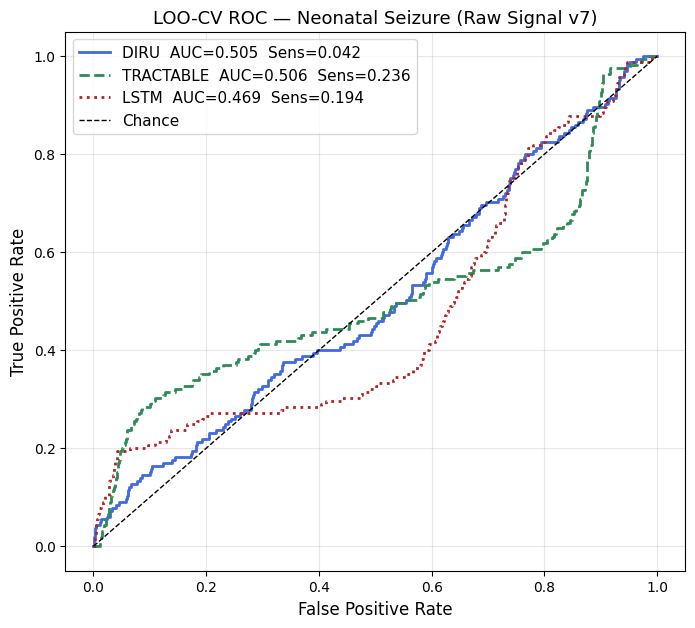

In [ ]:

import numpy as np
import pandas as pd
import torch

import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt, resample
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
from pathlib import Path
import pyedflib
import gc
import pickle
from tqdm import tqdm
from collections import defaultdict

# ============================================================
# Config
# ============================================================
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 40
BATCH_SIZE = 32
HIDDEN_SIZE     = 32
DIRU_DROPOUT    = 0.5
N_COMPARTMENTS  = 4

WINDOW_SIZE        = 6
OVERLAP            = 0.75
FIRST_N_TIMEPOINTS = 15417
FRAME_LEN_SEC      = 0.5
FRAME_STEP_SEC     = 0.25

#SELECTED_CHANNELS = [2, 3, 4, 5, 12, 13, 8, 9]
SELECTED_CHANNELS = [1, 2, 3, 4, 11, 12, 7, 8]   # 8 channels, matching original selection minus CZ

N_CHANNELS        = len(SELECTED_CHANNELS)   # 8

SUBBANDS = [
    ("delta", 0.5,  4.0),
    ("theta", 4.0,  8.0),
    ("alpha", 8.0,  13.0),
    ("beta",  13.0, 30.0),
    ("gamma", 30.0, 50.0),
]
N_BANDS         = len(SUBBANDS)
FULL_INPUT_SIZE = N_BANDS * N_CHANNELS   # 40

CHECKPOINT_DIR = "/content/drive/MyDrive/checkpoints"
FEATURE_CACHE  = "/content/drive/MyDrive/checkpoints/loo_features_v6.pkl"

_FS       = 256
_FL       = int(FRAME_LEN_SEC  * _FS)
_FS_STEP  = int(FRAME_STEP_SEC * _FS)
_WIN_SAMP = int(WINDOW_SIZE    * _FS)
T_SEQ     = 1 + (_WIN_SAMP - _FL) // _FS_STEP   # 11

print(f"Device={DEVICE}  T_seq={T_SEQ}  features={FULL_INPUT_SIZE}")
print(f"hidden={HIDDEN_SIZE} (all models)  epochs={NUM_EPOCHS}  batch={BATCH_SIZE}")
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)


# ============================================================
# Signal processing
# ============================================================
# ============================
# Bipolar montage
# ============================
def bipolar_montage(data):
    """
    Convert monopolar EEG to bipolar montage.
    Input:  (channels, samples) → e.g. (21, T)
    Output: (channels-1, samples) → e.g. (20, T)
    """
    return data[1:, :] - data[:-1, :]


def _bp(data, lo, hi, fs, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [max(lo/nyq, 1e-4), min(hi/nyq, 1-1e-4)], btype='band')
    return filtfilt(b, a, data, axis=1)


def compute_band_power_sequence(data, fs=_FS):
    """(n_ch, n_samp) -> (T_seq, 40)  raw subband signal, resampled to T_seq timepoints."""
    n_ch, n_samp = data.shape
    features = np.zeros((T_SEQ, N_BANDS * n_ch), dtype=np.float32)

    for b_i, (_, lo, hi) in enumerate(SUBBANDS):
        band = _bp(data, lo, hi, fs)                    # (n_ch, n_samp)
        band_resampled = resample(band, T_SEQ, axis=1)  # (n_ch, T_seq)
        features[:, b_i * n_ch:(b_i + 1) * n_ch] = band_resampled.T  # (T_seq, n_ch)

    return features


def load_recording(file_path):
    """Load EDF -> (8, n_samples) preprocessed signal."""
    try:
        edf   = pyedflib.EdfReader(str(file_path))
        sfreq = edf.getSampleFrequency(0)
        data  = np.array([edf.readSignal(i) for i in range(edf.signals_in_file)])
        edf.close()
    except Exception as e:
        print(f"  ERROR loading {Path(file_path).name}: {e}")
        return None
    try:
        if sfreq != _FS:
            data = resample(data, int(data.shape[1] * _FS / sfreq), axis=1)
        b, a     = butter(4, [0.5, 50], fs=_FS, btype='band')
        data     = filtfilt(b, a, data, axis=1)
        #b_n, a_n = butter(4, [49, 51], fs=_FS, btype='bandstop')
        #data     = filtfilt(b_n, a_n, data, axis=1)

        data = bipolar_montage(data)

        #data    -= data.mean(axis=0, keepdims=True)                     # CAR
        data     = (data - data.mean(axis=1, keepdims=True)) / \
                   (data.std(axis=1, keepdims=True) + 1e-8)             # per-ch z-score
        data     = data[:, :FIRST_N_TIMEPOINTS]
        data     = data[SELECTED_CHANNELS, :]
    except Exception as e:
        print(f"  ERROR preprocessing {Path(file_path).name}: {e}")
        return None
    return data


# ============================================================
# Pre-compute all features once
# ============================================================

def build_all_features(data_path, annotations_path):
    """
    Returns list of dicts, one per valid recording:
      { 'rec_idx', 'file', 'X': (n_win, T_seq, 40), 'y': (n_win,) }
    Raw log-power — z-score applied per LOO fold, not here.
    Cached to disk so second run is instant.
    """
    cache = Path(FEATURE_CACHE)
    if cache.exists():
        print(f"Loading cached features: {cache}")
        recs = pickle.load(open(cache, 'rb'))
        print(f"  {len(recs)} recordings loaded")
        return recs

    ann_df    = pd.read_csv(annotations_path, header=None)
    edf_files = sorted(Path(data_path).glob("eeg*.edf"),
                       key=lambda x: int(''.join(filter(str.isdigit, x.stem))))[:79]

    win_samp  = _WIN_SAMP
    step_samp = max(1, int(win_samp * (1 - OVERLAP)))
    recs      = []

    for edf_file in tqdm(edf_files, desc="Pre-computing features (runs once)"):
        rec_num = int(''.join(filter(str.isdigit, edf_file.stem)))
        col_idx = rec_num - 1
        if col_idx >= ann_df.shape[1]:
            continue

        data = load_recording(edf_file)
        if data is None:
            continue

        annot  = ann_df[col_idx].values[:FIRST_N_TIMEPOINTS]
        X_list, y_list = [], []

        #for start in range(0, len(annot) - win_samp, step_samp):
        for start in range(0, len(annot) - 1, step_samp):
            end    = start + win_samp
            ratio  = float(annot[start:end].sum()) / win_samp
            window = data[:, start:end]
            if window.shape[1] < win_samp:
                window = np.concatenate(
                    [window, np.zeros((window.shape[0], win_samp - window.shape[1]))],
                    axis=1)
            ps = compute_band_power_sequence(window)
            ps = ps[:T_SEQ] if ps.shape[0] >= T_SEQ else \
                 np.vstack([ps, np.zeros((T_SEQ - ps.shape[0], FULL_INPUT_SIZE))])
            X_list.append(ps)
            y_list.append(float(ratio > 0.5))   #it was 0.1

        if not X_list:
            continue

        recs.append({
            'rec_idx': col_idx,
            'file':    edf_file.name,
            'X':       np.stack(X_list).astype(np.float32),
            'y':       np.array(y_list, dtype=np.float32),
        })

    print(f"Done: {len(recs)} recordings extracted")
    pickle.dump(recs, open(cache, 'wb'))
    print(f"Cached to: {cache}")
    return recs


# ============================================================
# Models — all take (B, T_seq, 40), same hidden_size=32
# ============================================================

class DIRUCell(nn.Module):
    """
    K compartments, each with its own W_in over the FULL input (40 features).
    Inductive bias: K separate learned projections, not input restriction.
    """
    def __init__(self, input_size, hidden_size, num_compartments):
        super().__init__()
        self.num_comp = num_compartments
        self.W_in  = nn.ModuleList([
            nn.Linear(input_size, hidden_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.Linear(hidden_size, hidden_size * num_compartments)
        # gate outputs K scalars (one attention weight per compartment)
        self.gate  = nn.Linear(hidden_size * num_compartments, num_compartments)


    def forward(self, x, h):
        rec   = self.W_rec(h).chunk(self.num_comp, dim=1)
        outs  = [torch.tanh(self.W_in[i](x) + rec[i]) for i in range(self.num_comp)]
        stack = torch.stack(outs, dim=1)                        # (B, K, H)
        # gate: K attention weights via softmax — output magnitude preserved
        w = torch.softmax(self.gate(stack.reshape(stack.size(0), -1)), dim=1)  # (B, K)
        return (stack * w.unsqueeze(2)).sum(dim=1)              # (B, H)


class DIRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size,
                 num_compartments=N_COMPARTMENTS, dropout=DIRU_DROPOUT):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = DIRUCell(input_size, hidden_size, num_compartments)
        self.dropout     = nn.Dropout(dropout)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(self.dropout(h))


class TractableDendriticCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_compartments):
        super().__init__()
        self.num_comp  = num_compartments
        self.comp_size = hidden_size // num_compartments
        assert hidden_size % num_compartments == 0
        self.W_in  = nn.ModuleList([
            nn.Linear(input_size,  self.comp_size) for _ in range(num_compartments)
        ])
        self.W_rec = nn.ModuleList([
            nn.Linear(hidden_size, self.comp_size) for _ in range(num_compartments)
        ])
        self.integration = nn.Linear(hidden_size, hidden_size)

    def forward(self, x, h):
        outs = [torch.tanh(self.W_in[i](x) + self.W_rec[i](h))
                for i in range(self.num_comp)]
        return torch.tanh(self.integration(torch.cat(outs, dim=1)))


class TractableDendriticRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size,
                 num_compartments=N_COMPARTMENTS):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = TractableDendriticCell(input_size, hidden_size, num_compartments)
        self.dropout     = nn.Dropout(0.5)
        self.fc          = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t], h)
        return self.fc(self.dropout(h))


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                               batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1]))


def make_models():
    return {
        'diru':      DIRU(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
        'tractable': TractableDendriticRNN(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
        'lstm':      LSTMModel(FULL_INPUT_SIZE, HIDDEN_SIZE, 1).to(DEVICE),
    }


# ============================================================
# Per-fold training
# ============================================================

def train_fold(model, X_tr, y_tr, X_val, y_val):
    """
    Train on (X_tr, y_tr), evaluate on (X_val, y_val).
    No checkpointing — each fold trains from scratch and is fast.
    Returns: probs array for X_val.
    """
    tr_ds     = TensorDataset(torch.FloatTensor(X_tr),
                               torch.FloatTensor(y_tr).unsqueeze(1))
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

    n_pos = int(y_tr.sum())
    n_neg = len(y_tr) - n_pos

    # More aggressive — empirically tuned multiplier
    SENSITIVITY_BOOST = 5   # tune this: 1.5, 2.0, 2.5, 3.0
    pw = torch.FloatTensor([SENSITIVITY_BOOST * n_neg / max(n_pos, 1)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    optimizer     = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    warmup_epochs = 3
    warmup_sched  = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
    plateau_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-5)

    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    patience      = 8

    X_val_t = torch.FloatTensor(X_val).to(DEVICE)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1).to(DEVICE)

    for epoch in range(NUM_EPOCHS):
        model.train()
        ep_loss = 0.0
        for bx, by in tr_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ep_loss += loss.item()
        ep_loss /= len(tr_loader)

        model.eval()
        with torch.no_grad():
            val_loss = nn.BCEWithLogitsLoss()(model(X_val_t), y_val_t).item()

        if epoch < warmup_epochs:
            warmup_sched.step()
        else:
            plateau_sched.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_val_t)).cpu().numpy().flatten()
    return probs


# ============================================================
# LOO loop
# ============================================================

def run_loo(recordings):
    """
    Leave-one-recording-out CV.
    For each fold i: train on 75 recordings, test on 1.
    z-score fitted on train windows only, applied to test.
    ALL predictions aggregated — including recordings with only one class.
    AUC is only meaningful on the pooled set (both classes present overall).
    """
    n           = len(recordings)
    all_probs   = {name: [] for name in ('diru', 'tractable', 'lstm')}
    all_labels  = {name: [] for name in ('diru', 'tractable', 'lstm')}
    single_class_folds = 0

    for fold_i in tqdm(range(n), desc="LOO folds"):
        test_rec   = recordings[fold_i]
        train_recs = [recordings[j] for j in range(n) if j != fold_i]

        X_tr = np.concatenate([r['X'] for r in train_recs], axis=0)
        y_tr = np.concatenate([r['y'] for r in train_recs], axis=0)
        X_te = test_rec['X']
        y_te = test_rec['y']

        if len(np.unique(y_te)) < 2:
            single_class_folds += 1
            # Still include predictions — they contribute TN/TP to pooled eval

        # z-score: fit on train, apply to test — no leakage
        flat   = X_tr.reshape(-1, FULL_INPUT_SIZE)
        mu     = flat.mean(axis=0, keepdims=True)
        std    = flat.std( axis=0, keepdims=True)
        X_tr_n = (X_tr - mu[None]) / (std[None] + 1e-8)
        X_te_n = (X_te - mu[None]) / (std[None] + 1e-8)

        models = make_models()
        for name, model in models.items():
            probs = train_fold(model, X_tr_n, y_tr, X_te_n, y_te)
            all_probs[name].extend(probs.tolist())
            all_labels[name].extend(y_te.tolist())

        del models
        gc.collect()
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

    print(f"  {single_class_folds} folds had single-class test recordings "
          f"(predictions included in pooled eval)")
    return all_probs, all_labels


# ============================================================
# Evaluation & plotting
# ============================================================

def evaluate(all_probs, all_labels):
    print(f"\n{'='*60}\nLOO-CV SUMMARY\n{'='*60}")
    summary = {}
    for name in ('diru', 'tractable', 'lstm'):
        probs  = np.array(all_probs[name])
        labels = np.array(all_labels[name])

        # Find threshold maximising F1 over all LOO predictions
        thresholds = np.linspace(0.05, 0.95, 181)
        best_f1, best_thr = 0., 0.5
        for thr in thresholds:
            preds_t = (probs > thr).astype(int)
            tp = int(((preds_t == 1) & (labels == 1)).sum())
            fp = int(((preds_t == 1) & (labels == 0)).sum())
            fn = int(((preds_t == 0) & (labels == 1)).sum())
            f1_t = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0.
            if f1_t > best_f1:
                best_f1, best_thr = f1_t, thr

        preds = (probs > best_thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0.
        spec = tn / (tn + fp) if (tn + fp) else 0.
        auc  = roc_auc_score(labels, probs)
        f1   = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0.
        acc  = accuracy_score(labels, preds)
        summary[name] = dict(sens=sens, spec=spec, auc=auc, f1=f1, acc=acc,
                             probs=probs, labels=labels, threshold=best_thr)
        print(f"  {name.upper():12s}  Sens={sens:.3f}  Spec={spec:.3f}  "
              f"AUC={auc:.3f}  F1={f1:.3f}  Acc={acc:.3f}  thr={best_thr:.2f}")

    d_auc = summary['diru']['auc']
    l_auc = summary['lstm']['auc']
    print(f"\n  DIRU vs LSTM  ΔAUC = {(d_auc - l_auc)*100:+.1f} pp")
    return summary


def plot_roc(summary, save_path=None):
    plt.figure(figsize=(8, 7))
    styles = {'diru':      ('royalblue', '-'),
              'tractable': ('seagreen',  '--'),
              'lstm':      ('firebrick', ':')}
    for name, (col, ls) in styles.items():
        m = summary[name]
        fpr, tpr, _ = roc_curve(m['labels'], m['probs'])
        plt.plot(fpr, tpr, color=col, ls=ls, lw=2,
                 label=f"{name.upper()}  AUC={m['auc']:.3f}  Sens={m['sens']:.3f}")
    plt.plot([0,1],[0,1],'k--',lw=1,label='Chance')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate',  fontsize=12)
    plt.title('LOO-CV ROC — Neonatal Seizure (Band-Power v6)', fontsize=13)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"ROC saved: {save_path}")
    plt.show()


# ============================================================
# Main
# ============================================================

def run(data_path, clear_cache=False):
    if clear_cache:
        p = Path(FEATURE_CACHE)
        if p.exists():
            p.unlink()
            print("Feature cache cleared")

    ann_path   = Path(data_path) / "annotations_2017_A_fixed.csv"
    recordings = build_all_features(data_path, ann_path)

    # Print param counts
    models_ex = make_models()
    for name, m in models_ex.items():
        n_params = sum(p.numel() for p in m.parameters())
        print(f"  {name:12s}: {n_params:,} params")
    del models_ex

    print(f"\nStarting LOO over {len(recordings)} recordings ...")
    all_probs, all_labels = run_loo(recordings)

    summary = evaluate(all_probs, all_labels)

    rpath = Path(CHECKPOINT_DIR) / 'loo_results_v6.pkl'
    pickle.dump({'probs': all_probs, 'labels': all_labels, 'summary': summary},
                open(rpath, 'wb'))
    print(f"Results saved: {rpath}")

    plot_roc(summary, save_path=Path(CHECKPOINT_DIR) / 'roc_loo_v6.png')
    return summary


if __name__ == "__main__":
    DATA_PATH   = "/content/drive/MyDrive/eeg_cache"
    CLEAR_CACHE = True   # set True to re-extract features after pipeline changes

    summary = run(DATA_PATH, clear_cache=CLEAR_CACHE)

In [ ]:
import pickle
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt

# ── Load your saved results ──────────────────────────────────────────
results = pickle.load(open("/content/drive/MyDrive/checkpoints/loo_results_v7.pkl", "rb"))
all_probs  = results['probs']    # dict: {'diru': [...], 'tractable': [...], 'lstm': [...]}
all_labels = results['labels']   # dict: same structure

# ── Re-evaluate with sensitivity-targeted threshold ──────────────────
TARGET_SENS = 0.75   # adjust this to whatever your clinical requirement is

print(f"{'='*65}")
print(f"RE-EVALUATION WITH SENSITIVITY TARGET >= {TARGET_SENS}")
print(f"{'='*65}")

for name in ('diru', 'tractable', 'lstm'):
    probs  = np.array(all_probs[name])
    labels = np.array(all_labels[name])

    # Search for threshold that hits target sensitivity with best specificity
    best_spec, best_thr = 0., 0.5
    best_sens_achieved  = 0.

    for thr in np.linspace(0.01, 0.99, 990):
        preds_t = (probs > thr).astype(int)
        tp = int(((preds_t == 1) & (labels == 1)).sum())
        fp = int(((preds_t == 1) & (labels == 0)).sum())
        fn = int(((preds_t == 0) & (labels == 1)).sum())
        tn = int(((preds_t == 0) & (labels == 0)).sum())
        sens_t = tp / (tp + fn) if (tp + fn) else 0.
        spec_t = tn / (tn + fp) if (tn + fp) else 0.

        if sens_t >= TARGET_SENS and spec_t > best_spec:
            best_spec          = spec_t
            best_thr           = thr
            best_sens_achieved = sens_t

    # Final metrics at chosen threshold
    preds = (probs > best_thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.
    spec = tn / (tn + fp) if (tn + fp) else 0.
    f1   = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) else 0.
    acc  = accuracy_score(labels, preds)
    auc  = roc_auc_score(labels, probs)   # unchanged — threshold doesn't affect AUC

    print(f"\n  {name.upper()}")
    print(f"    Threshold : {best_thr:.3f}")
    print(f"    Sens      : {sens:.3f}   (target was >= {TARGET_SENS})")
    print(f"    Spec      : {spec:.3f}")
    print(f"    AUC       : {auc:.3f}   (identical to before)")
    print(f"    F1        : {f1:.3f}")
    print(f"    Acc       : {acc:.3f}")
    print(f"    TP={tp}  FP={fp}  FN={fn}  TN={tn}")

    if best_thr <= 0.02 or best_thr >= 0.98:
        print(f"    WARNING: threshold hit boundary — "
              f"model may not support target sensitivity of {TARGET_SENS}")

RE-EVALUATION WITH SENSITIVITY TARGET >= 0.75

  DIRU
    Threshold : 0.102
    Sens      : 0.764   (target was >= 0.75)
    Spec      : 0.830
    AUC       : 0.884   (identical to before)
    F1        : 0.192
    Acc       : 0.828
    TP=126  FP=1020  FN=39  TN=4971

  TRACTABLE
    Threshold : 0.138
    Sens      : 0.752   (target was >= 0.75)
    Spec      : 0.661
    AUC       : 0.769   (identical to before)
    F1        : 0.107
    Acc       : 0.663
    TP=124  FP=2032  FN=41  TN=3959

  LSTM
    Threshold : 0.124
    Sens      : 0.752   (target was >= 0.75)
    Spec      : 0.694
    AUC       : 0.805   (identical to before)
    F1        : 0.117
    Acc       : 0.695
    TP=124  FP=1835  FN=41  TN=4156
